<a href="https://colab.research.google.com/github/Aykay07/CAESAR-Confidence-Aware-Ensemble-for-Secure-Adaptive-Routing/blob/main/UAV_NIDD_Confidence_Aware_Ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os

PROJECT_DIR = "/content/drive/MyDrive/UAV_NIDD_Project"

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/dataset", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/notebooks", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/models", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/results", exist_ok=True)
os.makedirs(f"{PROJECT_DIR}/figures", exist_ok=True)

print("Project directory:")
print(PROJECT_DIR)

print("\nContents:")
print(os.listdir(PROJECT_DIR))

Project directory:
/content/drive/MyDrive/UAV_NIDD_Project

Contents:
['dataset', 'notebooks', 'models', 'results', 'figures']


In [9]:
import os

DATASET_DIR = "/content/drive/MyDrive/UAV_NIDD_Project/dataset"

print("Dataset folder contents:")

for root, dirs, files in os.walk(DATASET_DIR):
    level = root.replace(DATASET_DIR, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:20]:
        print(f"{indent}    {file}")

Dataset folder contents:
dataset/
    Access Point Case2 Label.xlsx
    GSC Case3 Label .csv
    UAV-Case1-Label.csv


In [11]:
import pandas as pd
import os

DATASET_DIR = "/content/drive/MyDrive/UAV_NIDD_Project/dataset"

CASE1_PATH = os.path.join(DATASET_DIR, "UAV-Case1-Label.csv")

print("Loading UAV Case 1...")
print(CASE1_PATH)

df = pd.read_csv(
    CASE1_PATH,
    encoding="latin1"
)

print("\nLoaded successfully!")
print("Shape:", df.shape)

print("\nColumns:")
for i, col in enumerate(df.columns):
    print(i, ":", col)

Loading UAV Case 1...
/content/drive/MyDrive/UAV_NIDD_Project/dataset/UAV-Case1-Label.csv


/tmp/ipykernel_926/3573375501.py:11: DtypeWarning: Columns (0,1,2,3,4,15,17,24,25,33,34,35,36,37,38,39,44) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(



Loaded successfully!
Shape: (885384, 45)

Columns:
0 : frame.encap_type
1 : frame.len
2 : frame.number
3 : frame.time_delta_displayed
4 : frame.time_epoch
5 : frame.time_relative
6 : radiotap.channel.flags.cck
7 : radiotap.channel.flags.ofdm
8 : radiotap.channel.freq
9 : radiotap.datarate
10 : radiotap.dbm_antsignal
11 : radiotap.length
12 : radiotap.mactime
13 : radiotap.present.tsft
14 : radiotap.rxflags
15 : radiotap.timestamp.ts
16 : radiotap.vendor_oui
17 : wlan.duration
18 : wlan.bssid
19 : wlan.fc.retry
20 : wlan.fc.subtype
21 : wlan.fcs.bad_checksum
22 : wlan.fixed.beacon
23 : wlan.fixed.capabilities.ess
24 : wlan.seq
25 : wlan.tag
26 : wlan_radio.frequency
27 : wlan_radio.signal_dbm
28 : wlan_radio.start_tsf
29 : wlan_radio.phy
30 : wlan_radio.timestamp
31 : wlan.rsn.capabilities.mfpc
32 : wlan_rsna_eapol.keydes.msgnr
33 : arp
34 : arp.hw.type
35 : arp.proto.type
36 : ip.dst
37 : ip.proto
38 : ip.src
39 : ip.ttl
40 : tcp.ack
41 : udp.dstport
42 : udp.srcport
43 : udp.length
4

In [12]:
display(df.head())

,frame.encap_type,frame.len,frame.number,frame.time_delta_displayed,frame.time_epoch,frame.time_relative,radiotap.channel.flags.cck,radiotap.channel.flags.ofdm,radiotap.channel.freq,radiotap.datarate,...,arp.proto.type,ip.dst,ip.proto,ip.src,ip.ttl,tcp.ack,udp.dstport,udp.srcport,udp.length,Label
0,1,90,1,0.0,0.0,1.505186e+09,0.000000,0.0,0.0,0.0,...,0,0,0,0,0,0.0,0.0,0.0,0.0,Normal
1,1,342,2,0.012728,0.012728,1.505186e+09,0.012728,0.0,0.0,0.0,...,0,0,255.255.255.255,17,0.0.0.0,0.0,0.0,67.0,68.0,Normal
2,1,590,3,0.046358,0.046358,1.505186e+09,0.059086,0.0,0.0,0.0,...,0,0,192.168.1.3,17,192.168.1.1,0.0,0.0,68.0,67.0,Normal
3,1,42,4,0.002437,0.002437,1.505186e+09,0.061522,0.0,0.0,0.0,...,1,192.168.1.3,0,0,0,0.0,0.0,0.0,0.0,Normal
4,1,54,5,0.010467,0.010467,1.505186e+09,0.071989,0.0,0.0,0.0,...,0,0,224.0.0.22,2,192.168.1.3,0.0,0.0,0.0,0.0,Normal


In [13]:
print("Data types:")
display(df.dtypes)

Data types:


,0
frame.encap_type,object
frame.len,object
frame.number,object
frame.time_delta_displayed,object
frame.time_epoch,object
frame.time_relative,float64
radiotap.channel.flags.cck,float64
radiotap.channel.flags.ofdm,float64
radiotap.channel.freq,float64
radiotap.datarate,float64


In [14]:
print("Missing values:")
display(
    df.isnull().sum()
      .sort_values(ascending=False)
      .head(20)
)

Missing values:


,0
radiotap.datarate,24732
radiotap.channel.freq,24732
radiotap.channel.flags.ofdm,24732
radiotap.channel.flags.cck,24732
frame.time_relative,24732
radiotap.length,24732
radiotap.dbm_antsignal,24732
radiotap.mactime,24732
wlan.duration,24732
radiotap.vendor_oui,24732


In [15]:
print("Unique values and counts for possible label columns:\n")

for col in df.columns:
    if df[col].dtype == "object":
        print(f"\n--- {col} ---")
        print("Unique values:", df[col].nunique())
        print(df[col].value_counts().head(20))

Unique values and counts for possible label columns:


--- frame.encap_type ---
Unique values: 385
frame.encap_type
1                                                                                                                                                                               595606
23                                                                                                                                                                              247326
20                                                                                                                                                                                9036
1                                                                                                                                                                                 8685
Á%/+vµýàqÍ~Rb\t5ÖF                                                                                                                                  

In [16]:
# Check how many values in each column can actually be interpreted as numbers

diagnostics = []

for col in df.columns:
    numeric_version = pd.to_numeric(df[col], errors="coerce")

    diagnostics.append({
        "Column": col,
        "Original dtype": str(df[col].dtype),
        "Total values": len(df[col]),
        "Numeric values": numeric_version.notna().sum(),
        "Non-numeric values": numeric_version.isna().sum(),
        "Missing %": round(df[col].isna().mean() * 100, 2),
        "Unique values": df[col].nunique(dropna=True)
    })

diagnostics_df = pd.DataFrame(diagnostics)

display(
    diagnostics_df.sort_values(
        "Non-numeric values",
        ascending=False
    )
)

,Column,Original dtype,Total values,Numeric values,Non-numeric values,Missing %,Unique values
44,Label,object,885384,0,885384,2.79,13
39,ip.ttl,object,885384,469188,416196,2.79,331
37,ip.proto,object,885384,471792,413592,2.79,36
17,wlan.duration,object,885384,646237,239147,2.79,3
36,ip.dst,object,885384,688257,197127,2.79,572
34,arp.hw.type,object,885384,688257,197127,2.79,188
25,wlan.tag,object,885384,820879,64505,2.79,4259
24,wlan.seq,object,885384,820879,64505,2.79,596
15,radiotap.timestamp.ts,object,885384,845091,40293,2.79,5
35,arp.proto.type,object,885384,857713,27671,2.79,39


In [17]:
problem_columns = [
    "frame.encap_type",
    "frame.number",
    "ip.proto",
    "ip.src",
    "ip.ttl"
]

for col in problem_columns:
    print("\n" + "="*70)
    print(col)
    print("="*70)

    print(df[col].value_counts(dropna=False).head(15))


frame.encap_type
frame.encap_type
1                                                                                                                                                   595606
23                                                                                                                                                  247326
20                                                                                                                                                    9036
1                                                                                                                                                     8685
u)                                                                                                                                                 2297
®5âò"ßø£~"óx+b±máB\tEØËisÖÔEÑ'1|gG                                                                                                               2297
Lññußþ¨Ñhi6/EÄÈà¥8Úfe-µ

In [18]:
print("Total rows:", len(df))
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate percentage:",
      round(df.duplicated().mean() * 100, 3), "%")

Total rows: 885384
Exact duplicate rows: 34368
Duplicate percentage: 3.882 %


Label
DDoS                 193180
BruteForce           175925
UDP Flooding         152775
MITM                 151586
ICMP Flooding         47544
Jamming               41600
replay                25977
FakeLanding           24050
Normal                17949
De-authentication     14606
Scanning               9030
DoS                    6424
Reconnassiance            6
Name: count, dtype: int64


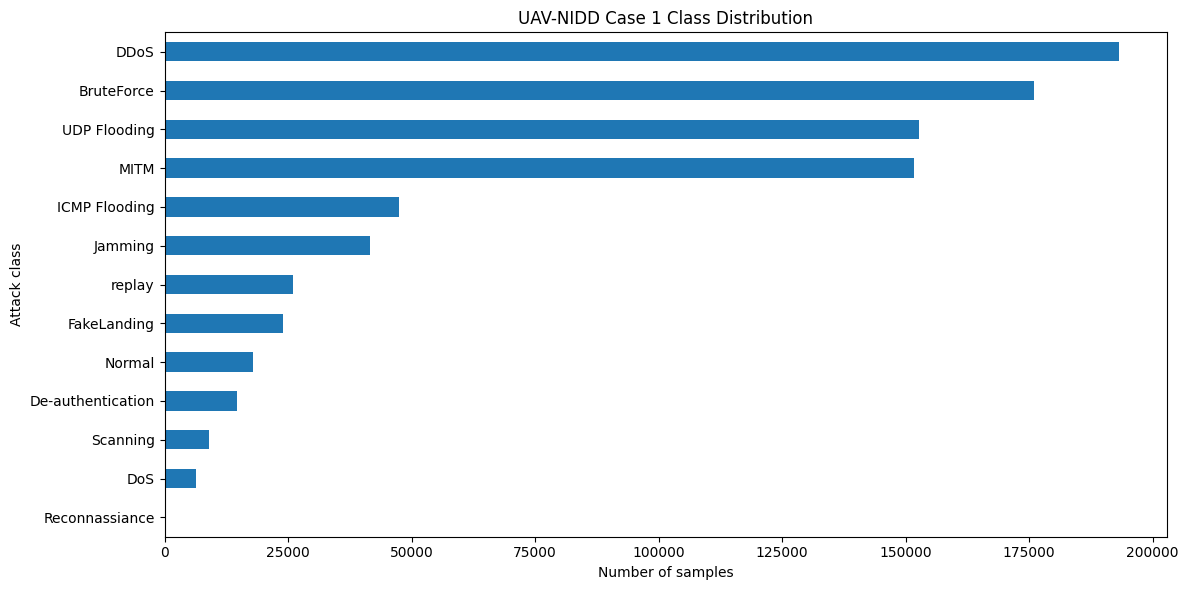

In [19]:
import matplotlib.pyplot as plt

label_counts = df["Label"].value_counts()

print(label_counts)

plt.figure(figsize=(12, 6))
label_counts.sort_values(ascending=True).plot(kind="barh")
plt.xlabel("Number of samples")
plt.ylabel("Attack class")
plt.title("UAV-NIDD Case 1 Class Distribution")
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# STEP 9: FEATURE QUALITY DIAGNOSTICS
# ============================================================

diagnostics = []

for col in df.columns:
    numeric_version = pd.to_numeric(df[col], errors="coerce")

    diagnostics.append({
        "Column": col,
        "Original_Dtype": str(df[col].dtype),
        "Numeric_Values": numeric_version.notna().sum(),
        "Non_Numeric_Values": numeric_version.isna().sum(),
        "Missing_Values": df[col].isna().sum(),
        "Numeric_%": round(
            numeric_version.notna().mean() * 100, 2
        ),
        "Unique_Values": df[col].nunique(dropna=True)
    })

diagnostics_df = pd.DataFrame(diagnostics)

display(
    diagnostics_df.sort_values(
        by="Numeric_%",
        ascending=False
    ).reset_index(drop=True)
)

,Column,Original_Dtype,Numeric_Values,Non_Numeric_Values,Missing_Values,Numeric_%,Unique_Values
0,frame.encap_type,object,860653,24731,334,97.21,385
1,frame.len,object,860653,24731,13237,97.21,1498
2,frame.number,object,860653,24731,21130,97.21,240770
3,frame.time_delta_displayed,object,860652,24732,21948,97.21,189439
4,frame.time_epoch,object,860652,24732,24384,97.21,189431
5,frame.time_relative,float64,860652,24732,24732,97.21,526231
6,radiotap.channel.flags.cck,float64,860652,24732,24732,97.21,830067
7,radiotap.channel.flags.ofdm,float64,860652,24732,24732,97.21,2
8,radiotap.channel.freq,float64,860652,24732,24732,97.21,2
9,radiotap.datarate,float64,860652,24732,24732,97.21,11


In [21]:
# Columns with at least 95% values that can be interpreted as numbers

numeric_candidates = diagnostics_df[
    diagnostics_df["Numeric_%"] >= 95
]["Column"].tolist()

print("Numeric candidate columns:")
print()

for col in numeric_candidates:
    print(col)

print("\nNumber of candidates:", len(numeric_candidates))

Numeric candidate columns:

frame.encap_type
frame.len
frame.number
frame.time_delta_displayed
frame.time_epoch
frame.time_relative
radiotap.channel.flags.cck
radiotap.channel.flags.ofdm
radiotap.channel.freq
radiotap.datarate
radiotap.dbm_antsignal
radiotap.length
radiotap.mactime
radiotap.present.tsft
radiotap.rxflags
radiotap.timestamp.ts
radiotap.vendor_oui
wlan.bssid
wlan.fc.retry
wlan.fc.subtype
wlan.fcs.bad_checksum
wlan.fixed.beacon
wlan.fixed.capabilities.ess
wlan_radio.frequency
wlan_radio.signal_dbm
wlan_radio.start_tsf
wlan_radio.phy
wlan_radio.timestamp
wlan.rsn.capabilities.mfpc
wlan_rsna_eapol.keydes.msgnr
arp
arp.proto.type
ip.src
tcp.ack
udp.dstport
udp.srcport
udp.length

Number of candidates: 37


In [22]:
# ============================================================
# STEP 11: DUPLICATE ANALYSIS
# ============================================================

duplicate_mask = df.duplicated(keep=False)

duplicate_df = df.loc[duplicate_mask]

print("Rows involved in exact duplicates:", len(duplicate_df))
print("Unique duplicated rows:",
      duplicate_df.drop_duplicates().shape[0])

print("\nLabels among duplicated rows:")
display(
    duplicate_df["Label"]
    .value_counts()
)

Rows involved in exact duplicates: 40828
Unique duplicated rows: 6460

Labels among duplicated rows:


,count
Label,
Normal,16384


In [23]:
# Check whether identical feature rows ever have different labels

feature_columns = [c for c in df.columns if c != "Label"]

duplicate_conflicts = (
    df.groupby(feature_columns, dropna=False)["Label"]
      .nunique()
)

print(
    "Exact feature duplicates with conflicting labels:",
    (duplicate_conflicts > 1).sum()
)

Exact feature duplicates with conflicting labels: 0


In [24]:
suspicious_columns = [
    "frame.encap_type",
    "frame.number",
    "ip.proto",
    "ip.src",
    "ip.ttl"
]

for col in suspicious_columns:
    print("\n" + "=" * 80)
    print(f"COLUMN: {col}")
    print("=" * 80)

    print("dtype:", df[col].dtype)
    print("missing:", df[col].isna().sum())
    print("unique:", df[col].nunique(dropna=True))

    print("\nSample values:")
    display(df[col].dropna().head(15))


COLUMN: frame.encap_type
dtype: object
missing: 334
unique: 385

Sample values:


,frame.encap_type
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,1
9,1



COLUMN: frame.number
dtype: object
missing: 21130
unique: 240770

Sample values:


,frame.number
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10



COLUMN: ip.proto
dtype: object
missing: 24732
unique: 36

Sample values:


,ip.proto
0,0
1,255.255.255.255
2,192.168.1.3
3,0
4,224.0.0.22
5,0
6,192.168.1.3
7,192.168.1.3
8,192.168.1.3
9,0



COLUMN: ip.src
dtype: object
missing: 24732
unique: 45

Sample values:


,ip.src
0,0
1,17
2,17
3,0
4,2
5,0
6,17
7,17
8,17
9,0



COLUMN: ip.ttl
dtype: object
missing: 24732
unique: 331

Sample values:


,ip.ttl
0,0
1,0.0.0.0
2,192.168.1.1
3,0
4,192.168.1.3
5,0
6,192.168.1.1
7,192.168.1.1
8,192.168.1.1
9,0


In [6]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount("/content/drive")

# Your project folder
PROJECT_DIR = "/content/drive/MyDrive/UAV_NIDD_Project"

print("Project folder exists:", os.path.exists(PROJECT_DIR))

# Show what is inside the project
if os.path.exists(PROJECT_DIR):
    print("\nProject contents:")
    print(os.listdir(PROJECT_DIR))

    DATASET_DIR = os.path.join(PROJECT_DIR, "dataset")

    print("\nDataset folder exists:", os.path.exists(DATASET_DIR))

    if os.path.exists(DATASET_DIR):
        print("\nDataset contents:")
        for file in os.listdir(DATASET_DIR):
            print(repr(file))

Mounted at /content/drive
Project folder exists: True

Project contents:
['dataset', 'notebooks', 'models', 'results', 'figures']

Dataset folder exists: True

Dataset contents:
'Access Point Case2 Label.xlsx'
'GSC Case3 Label .csv'
'UAV-Case1-Label.csv'


In [8]:
import os

print("Is Drive mounted?")
print(os.path.exists("/content/drive"))

print("\n/content/drive contents:")
if os.path.exists("/content/drive"):
    print(os.listdir("/content/drive"))

print("\n/content/drive/MyDrive exists?")
print(os.path.exists("/content/drive/MyDrive"))

if os.path.exists("/content/drive/MyDrive"):
    print("\nMyDrive contents:")
    print(os.listdir("/content/drive/MyDrive")[:30])

Is Drive mounted?
True

/content/drive contents:
['.shortcut-targets-by-id', 'MyDrive', '.Trash-0', '.Encrypted']

/content/drive/MyDrive exists?
True

MyDrive contents:
['BOARD_CLASS10_TERM2', 'FAREWELL_ME', 'BhimaShankar', 'BhimaShankarStory', 'HIMACHAL TRIP', '11th_ID_Data.xlsx', 'Anika_Photo.jpg', 'ME', '2023', 'Untitled form.gform', 'Formal_pic (1).jpg', 'Formal_pic.jpg', 'Portfolio (2).gsite', 'Portfolio (1).gsite', 'Portfolio.gsite', 'Classroom', 'BiologyProject_Audios', 'RA2411043010043 (1).pdf', 'RA2411043010043.pdf', 'Anika_NPTEL.pdf', 'Google Earth', 'WhatsApp Image 2026-01-09 at 2.39.21 PM.jpeg', 'WhatsAppImage2026-01-09at2.39.21PM1.jpeg', 'SRM_IDCard.jpeg', 'IMG-20260119-WA0034.jpg', 'payment_confirmation_20260128-024501.png', 'Resume_AnikaKothari_N_.pdf', '3rdSemester_BTech_Marksheet (1).pdf', '3rdSemester_BTech_Marksheet.pdf', 'SummerInternshipStatus_2026.gsheet']


In [9]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
print(os.listdir("/content/drive/MyDrive/UAV_NIDD_Project"))

['dataset', 'notebooks', 'models', 'results', 'figures']


In [11]:
print(os.listdir("/content/drive/MyDrive/UAV_NIDD_Project/dataset"))

['Access Point Case2 Label.xlsx', 'GSC Case3 Label .csv', 'UAV-Case1-Label.csv']


In [12]:
import pandas as pd
import os

CASE1_PATH = "/content/drive/MyDrive/UAV_NIDD_Project/dataset/UAV-Case1-Label.csv"

df = pd.read_csv(
    CASE1_PATH,
    encoding="latin1",
    low_memory=False
)

print("Loaded successfully!")
print("Shape:", df.shape)

Loaded successfully!
Shape: (885384, 45)


In [13]:
import re

def looks_like_ip(value):
    if pd.isna(value):
        return False
    value = str(value).strip()
    return bool(re.fullmatch(r"\d{1,3}(?:\.\d{1,3}){3}", value))

for col in ["ip.proto", "ip.ttl", "ip.src", "frame.number"]:
    count = df[col].apply(looks_like_ip).sum()
    print(f"{col:25s}: {count:,}")

ip.proto                 : 388,860
ip.ttl                   : 391,464
ip.src                   : 328
frame.number             : 0


In [14]:
ip_proto_ip_mask = df["ip.proto"].apply(looks_like_ip)

print("Rows where ip.proto contains an IP address:",
      ip_proto_ip_mask.sum())

display(
    df.loc[
        ip_proto_ip_mask,
        [
            "frame.number",
            "frame.len",
            "frame.time_relative",
            "ip.src",
            "ip.dst",
            "ip.proto",
            "ip.ttl",
            "tcp.ack",
            "udp.dstport",
            "udp.srcport",
            "Label"
        ]
    ].head(20)
)

Rows where ip.proto contains an IP address: 388860


,frame.number,frame.len,frame.time_relative,ip.src,ip.dst,ip.proto,ip.ttl,tcp.ack,udp.dstport,udp.srcport,Label
1,2,342,1.505186e+09,17,0,255.255.255.255,0.0.0.0,0.0,0.0,67.0,Normal
2,3,590,1.505186e+09,17,0,192.168.1.3,192.168.1.1,0.0,0.0,68.0,Normal
4,5,54,1.505186e+09,2,0,224.0.0.22,192.168.1.3,0.0,0.0,0.0,Normal
6,7,78,1.505186e+09,17,0,192.168.1.3,192.168.1.1,0.0,0.0,14550.0,Normal
7,8,80,1.505186e+09,17,0,192.168.1.3,192.168.1.1,0.0,0.0,14550.0,Normal
8,9,78,1.505186e+09,17,0,192.168.1.3,192.168.1.1,0.0,0.0,14550.0,Normal
10,11,43,1.505186e+09,17,0,192.168.1.1,192.168.1.3,0.0,0.0,5554.0,Normal
11,12,106,1.505186e+09,192.168.1.3,0,192.168.1.1,1,4.0,0.0,0.0,Normal
12,13,79,1.505186e+09,17,0,192.168.1.1,192.168.1.3,0.0,0.0,5556.0,Normal
13,14,108,1.505186e+09,192.168.1.3,0,192.168.1.1,1,4.0,0.0,0.0,Normal


In [15]:
for col in ["ip.proto", "ip.ttl", "ip.src", "ip.dst"]:
    print("\n" + "="*60)
    print(col)
    print("="*60)
    print(df[col].value_counts(dropna=False).head(30))


ip.proto
ip.proto
0                  467902
192.168.241.208     96580
192.168.241.124     96580
192.168.10.149      90038
192.168.10.152      84978
NaN                 24732
192.168.1.1         11590
192.168.1.3          5591
1                    3569
192.168.21.1         1280
224.0.0.251           657
239.255.255.250       363
2417                  319
192.168.21.254        260
192.168.21.131        257
192.168.21.132        256
192.168.21.255        253
224.0.0.22             63
192.168.10.2           25
255.255.255.255        14
185.125.190.48         14
185.125.190.56         12
192.168.10.254         10
91.189.91.96            9
91.189.91.97            5
192.168.10.1            4
185.125.190.18          4
91.189.91.49            4
162.213.33.48           4
185.125.190.96          4
Name: count, dtype: int64

ip.ttl
ip.ttl
0                  464970
192.168.241.208     96584
192.168.241.124     96580
192.168.10.152      89953
192.168.10.149      85067
NaN                 24732
192.

In [17]:
cols = [
    "wlan_radio.timestamp",
    "wlan.rsn.capabilities.mfpc",
    "wlan_rsna_eapol.keydes.msgnr",
    "arp",
    "arp.hw.type",
    "arp.proto.type",
    "ip.dst",
    "ip.proto",
    "ip.src",
    "ip.ttl",
    "tcp.ack",
    "udp.dstport",
    "udp.srcport",
    "udp.length",
    "Label"
]

display(df[cols].head(30))

,wlan_radio.timestamp,wlan.rsn.capabilities.mfpc,wlan_rsna_eapol.keydes.msgnr,arp,arp.hw.type,arp.proto.type,ip.dst,ip.proto,ip.src,ip.ttl,tcp.ack,udp.dstport,udp.srcport,udp.length,Label
0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,Normal
1,0.0,0.0,0.0,0,0,0,0,255.255.255.255,17,0.0.0.0,0.0,0.0,67.0,68.0,Normal
2,0.0,0.0,0.0,0,0,0,0,192.168.1.3,17,192.168.1.1,0.0,0.0,68.0,67.0,Normal
3,0.0,0.0,0.0,0,Address Resolution Protocol (request),1,192.168.1.3,0,0,0,0.0,0.0,0.0,0.0,Normal
4,0.0,0.0,0.0,0,0,0,0,224.0.0.22,2,192.168.1.3,0.0,0.0,0.0,0.0,Normal
5,0.0,0.0,0.0,0,Address Resolution Protocol (request),1,192.168.1.1,0,0,0,0.0,0.0,0.0,0.0,Normal
6,0.0,0.0,0.0,0,0,0,0,192.168.1.3,17,192.168.1.1,0.0,0.0,14550.0,14551.0,Normal
7,0.0,0.0,0.0,0,0,0,0,192.168.1.3,17,192.168.1.1,0.0,0.0,14550.0,14551.0,Normal
8,0.0,0.0,0.0,0,0,0,0,192.168.1.3,17,192.168.1.1,0.0,0.0,14550.0,14551.0,Normal
9,0.0,0.0,0.0,0,Address Resolution Protocol (reply),1,192.168.1.3,0,0,0,0.0,0.0,0.0,0.0,Normal


In [18]:
numeric_report = []

for col in df.columns:
    if col == "Label":
        continue

    numeric_version = pd.to_numeric(df[col], errors="coerce")

    numeric_pct = numeric_version.notna().mean() * 100
    missing_pct = df[col].isna().mean() * 100
    unique_count = df[col].nunique(dropna=True)

    numeric_report.append({
        "Column": col,
        "Original dtype": str(df[col].dtype),
        "Numeric %": round(numeric_pct, 2),
        "Missing %": round(missing_pct, 2),
        "Unique values": unique_count
    })

numeric_report = pd.DataFrame(numeric_report)

display(
    numeric_report.sort_values(
        "Numeric %",
        ascending=False
    ).reset_index(drop=True)
)

,Column,Original dtype,Numeric %,Missing %,Unique values
0,frame.encap_type,object,97.21,0.04,384
1,frame.len,object,97.21,1.50,1494
2,frame.number,object,97.21,2.39,240770
3,frame.time_delta_displayed,object,97.21,2.48,189088
4,frame.time_epoch,object,97.21,2.75,189080
5,frame.time_relative,float64,97.21,2.79,526231
6,radiotap.channel.flags.cck,float64,97.21,2.79,830067
7,radiotap.channel.flags.ofdm,float64,97.21,2.79,2
8,radiotap.channel.freq,float64,97.21,2.79,2
9,radiotap.datarate,float64,97.21,2.79,11


In [19]:
class_counts = df["Label"].value_counts()

print("Number of classes:", class_counts.shape[0])
print("\nClass distribution:")
display(class_counts.to_frame("Samples"))

print("\nClasses with fewer than 20 samples:")
display(class_counts[class_counts < 20])

Number of classes: 13

Class distribution:


,Samples
Label,
DDoS,193180
BruteForce,175925
UDP Flooding,152775
MITM,151586
ICMP Flooding,47544
Jamming,41600
replay,25977
FakeLanding,24050
Normal,17949



Classes with fewer than 20 samples:


,count
Label,
Reconnassiance,6


In [20]:
# Keep the original dataset untouched
df_model = df[df["Label"] != "Reconnassiance"].copy()

print("Original dataset:", df.shape)
print("Modeling dataset:", df_model.shape)

print("\nClasses in modeling dataset:")
display(df_model["Label"].value_counts())

Original dataset: (885384, 45)
Modeling dataset: (885378, 45)

Classes in modeling dataset:


,count
Label,
DDoS,193180
BruteForce,175925
UDP Flooding,152775
MITM,151586
ICMP Flooding,47544
Jamming,41600
replay,25977
FakeLanding,24050
Normal,17949


In [21]:
suspicious_mask = (
    df["ip.proto"].apply(looks_like_ip) |
    df["ip.ttl"].apply(looks_like_ip)
)

suspicious_indices = df.index[suspicious_mask]

print("Number of suspicious rows:", len(suspicious_indices))

if len(suspicious_indices) > 0:
    print("First suspicious index:", suspicious_indices.min())
    print("Last suspicious index:", suspicious_indices.max())
    print("First 20 suspicious indices:", suspicious_indices[:20].tolist())

Number of suspicious rows: 391792
First suspicious index: 1
Last suspicious index: 860651
First 20 suspicious indices: [1, 2, 4, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 18, 20, 21, 22, 23, 24, 25]


In [22]:
missing_count_per_row = df.drop(columns=["Label"]).isna().sum(axis=1)

print("Missing feature count per row:")
print(missing_count_per_row.value_counts().sort_index().head(30))

print(
    "\nRows with ALL feature columns missing:",
    (missing_count_per_row == (df.shape[1] - 1)).sum()
)

print(
    "Rows with zero missing features:",
    (missing_count_per_row == 0).sum()
)

Missing feature count per row:
0     860652
39       346
40      2429
41       827
42      7891
43     12918
44       321
Name: count, dtype: int64

Rows with ALL feature columns missing: 321
Rows with zero missing features: 860652


In [24]:
heavy_missing_mask = missing_count_per_row >= 39

print("Rows with 39+ missing features:",
      heavy_missing_mask.sum())

print("\nLabels of these rows:")
display(df.loc[heavy_missing_mask, "Label"].value_counts())

print("\nExamples:")
display(
    df.loc[
        heavy_missing_mask,
        ["frame.number", "frame.len", "frame.time_relative", "Label"]
    ].head(20)
)

Rows with 39+ missing features: 24732

Labels of these rows:


,count
Label,



Examples:


,frame.number,frame.len,frame.time_relative,Label
860652,193181,66,NaN,NaN
860653,NaN,NaN,NaN,NaN
860654,ù«wàfÛ5ä£9£G¯¸ÿ¨¨H¨.ó,Ù©Û÷Aô2GIÐG Þ©ØµSyd½×¯÷¤b¿ýºá¯½ãc5é2V...,NaN,NaN
860655,NaN,NaN,NaN,NaN
860656,NaN,NaN,NaN,NaN
860657,NaN,NaN,NaN,NaN
860658,NaN,NaN,NaN,NaN
860659,NaN,ÔÎ2¡ÝÅÂý_pÊélj2 È h|fs*ÛÚÚ¦'âÀÜb· T,NaN,NaN
860660,NaN,NaN,NaN,NaN
860661,NaN,NaN,NaN,NaN


In [25]:
print("Completely empty feature rows by label:")

all_missing_mask = missing_count_per_row == (df.shape[1] - 1)

display(
    df.loc[all_missing_mask, "Label"].value_counts()
)

Completely empty feature rows by label:


,count
Label,


In [26]:
print("Total rows:", len(df))

print("\nMissing labels:")
print(df["Label"].isna().sum())

print("\nFirst rows with missing Label:")
missing_label_indices = df.index[df["Label"].isna()]

print(missing_label_indices[:20].tolist())

print("\nLast rows with missing Label:")
print(missing_label_indices[-20:].tolist())

print("\nRows around the boundary:")
display(
    df.loc[
        860645:860660,
        ["frame.number", "frame.len", "frame.time_relative", "Label"]
    ]
)

Total rows: 885384

Missing labels:
24732

First rows with missing Label:
[860652, 860653, 860654, 860655, 860656, 860657, 860658, 860659, 860660, 860661, 860662, 860663, 860664, 860665, 860666, 860667, 860668, 860669, 860670, 860671]

Last rows with missing Label:
[885364, 885365, 885366, 885367, 885368, 885369, 885370, 885371, 885372, 885373, 885374, 885375, 885376, 885377, 885378, 885379, 885380, 885381, 885382, 885383]

Rows around the boundary:


,frame.number,frame.len,frame.time_relative,Label
860645,193174,54,1.709375e+09,DDoS
860646,193175,66,1.709375e+09,DDoS
860647,193176,54,1.709375e+09,DDoS
860648,193177,66,1.709375e+09,DDoS
860649,193178,54,1.709375e+09,DDoS
860650,193179,66,1.709375e+09,DDoS
860651,193180,54,1.709375e+09,DDoS
860652,193181,66,NaN,NaN
860653,NaN,NaN,NaN,NaN
860654,ù«wàfÛ5ä£9£G¯¸ÿ¨¨H¨.ó,Ù©Û÷Aô2GIÐG Þ©ØµSyd½×¯÷¤b¿ýºá¯½ãc5é2V...,NaN,NaN


In [29]:
df_valid = df[df["Label"].notna()].copy()

print("Original shape:", df.shape)
print("Valid labeled shape:", df_valid.shape)

print("\nMissing labels:", df_valid["Label"].isna().sum())

print("\nMissing feature values:")
print(df_valid.drop(columns=["Label"]).isna().sum().sum())

Original shape: (885384, 45)
Valid labeled shape: (860652, 45)

Missing labels: 0

Missing feature values:
0


In [30]:
# Check exact duplicate rows in the clean labeled dataset

duplicate_rows = df_valid.duplicated().sum()

print("Exact duplicate rows:", duplicate_rows)
print(
    "Duplicate percentage:",
    round(100 * duplicate_rows / len(df_valid), 2),
    "%"
)

Exact duplicate rows: 11591
Duplicate percentage: 1.35 %


In [31]:
# Check whether identical feature vectors ever have different labels

feature_cols_all = [col for col in df_valid.columns if col != "Label"]

conflicting_duplicates = (
    df_valid.groupby(feature_cols_all, dropna=False)["Label"]
    .nunique()
)

conflicting_count = (conflicting_duplicates > 1).sum()

print("Feature patterns with conflicting labels:", conflicting_count)

Feature patterns with conflicting labels: 0


In [33]:
class_counts = df_valid["Label"].value_counts()

print("Number of classes:", len(class_counts))
print("\nClass distribution:")
display(class_counts.to_frame("Count"))

print("\nClass percentages:")
class_percentages = (
    df_valid["Label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(3)
)

display(class_percentages.to_frame("Percentage"))

Number of classes: 13

Class distribution:


,Count
Label,
DDoS,193180
BruteForce,175925
UDP Flooding,152775
MITM,151586
ICMP Flooding,47544
Jamming,41600
replay,25977
FakeLanding,24050
Normal,17949



Class percentages:


,Percentage
Label,
DDoS,22.446
BruteForce,20.441
UDP Flooding,17.751
MITM,17.613
ICMP Flooding,5.524
Jamming,4.834
replay,3.018
FakeLanding,2.794
Normal,2.086


In [34]:
print("Smallest classes:")
display(class_counts.sort_values().head())

Smallest classes:


,count
Label,
Reconnassiance,6
DoS,6424
Scanning,9030
De-authentication,14606
Normal,17949


In [35]:
df_model = df_valid[df_valid["Label"] != "Reconnassiance"].copy()

print("Original labeled dataset:", df_valid.shape)
print("Primary modeling dataset:", df_model.shape)

print("\nClasses in primary experiment:", df_model["Label"].nunique())
print("\nRemaining class distribution:")
display(df_model["Label"].value_counts())

Original labeled dataset: (860652, 45)
Primary modeling dataset: (860646, 45)

Classes in primary experiment: 12

Remaining class distribution:


,count
Label,
DDoS,193180
BruteForce,175925
UDP Flooding,152775
MITM,151586
ICMP Flooding,47544
Jamming,41600
replay,25977
FakeLanding,24050
Normal,17949


In [36]:
# Identify exact duplicate feature rows in the primary modeling dataset

feature_cols_all = [col for col in df_model.columns if col != "Label"]

duplicate_mask = df_model.duplicated(
    subset=feature_cols_all,
    keep=False
)

print("Rows involved in duplicate feature patterns:", duplicate_mask.sum())

print("\nUnique duplicated feature patterns:",
      df_model.loc[duplicate_mask, feature_cols_all]
      .drop_duplicates()
      .shape[0])

print("\nLabels among duplicated rows:")
display(df_model.loc[duplicate_mask, "Label"].value_counts())

Rows involved in duplicate feature patterns: 17949

Unique duplicated feature patterns: 6358

Labels among duplicated rows:


,count
Label,
Normal,17949


In [68]:
# How many times do the most repeated feature patterns occur?

duplicate_pattern_counts = (
    df_model.loc[duplicate_mask, feature_cols_all]
    .value_counts()
)

display(duplicate_pattern_counts.head(20).to_frame("Occurrences"))

Occurrences
frame.encap_type frame.len frame.number frame.time_delta_displayed frame.time_epoch frame.time_relative radiotap.channel.flags.cck radiotap.channel.flags.ofdm radiotap.channel.freq radiotap.datarate radiotap.dbm_antsignal radiotap.length radiotap.mactime radiotap.present.tsft radiotap.rxflags radiotap.timestamp.ts radiotap.vendor_oui wlan.duration wlan.bssid wlan.fc.retry wlan.fc.subtype wlan.fcs.bad_checksum wlan.fixed.beacon wlan.fixed.capabilities.ess wlan.seq wlan.tag wlan_radio.frequency wlan_radio.signal_dbm wlan_radio.start_tsf wlan_radio.phy wlan_radio.timestamp wlan.rsn.capabilities.mfpc wlan_rsna_eapol.keydes.msgnr arp arp.hw.type arp.proto.type ip.dst ip.proto    ip.src ip.ttl      tcp.ack udp.dstport udp.srcport udp.length             
1                542       877          0.017345865                0.017345865      1.505186e+09        16.763014                  0.0                         0.0                   0.0               0.0                    0.0             0.0              0.0                   0.0              0                     0.0                 0             0.0        0.0           0.0             0.0                   0.0               0.0                         0        0        0.0                  0.0                   0.0                  0.0            0.0                  0.0                        0.0                          0   0           0              0      192.168.1.3 17     192.168.1.1 0.0     0.0         43282.0     5554.0                4
                           852          0.00286966                 0.00286966       1.505186e+09        16.293857                  0.0                         0.0                   0.0               0.0                    0.0             0.0              0.0                   0.0              0                     0.0                 0             0.0        0.0           0.0             0.0                   0.0               0.0                         0        0        0.0                  0.0                   0.0                  0.0            0.0                  0.0                        0.0                          0   0           0              0      192.168.1.3 17     192.168.1.1 0.0     0.0         43282.0     5554.0                4
                 83        471          0.018173512                0.018173512      1.505186e+09        8.589578                   0.0                         0.0                   0.0               0.0                    0.0             0.0              0.0                   0.0              0                     0.0                 0             0.0        0.0           0.0             0.0                   0.0               0.0                         0        0        0.0                  0.0                   0.0                  0.0            0.0                  0.0                        0.0                          0   0           0              0      192.168.1.1 17     192.168.1.3 0.0     0.0         5556.0      44908.0               4
                           469          0.02029747                 0.02029747       1.505186e+09        8.559480                   0.0                         0.0                   0.0               0.0                    0.0             0.0              0.0                   0.0              0                     0.0                 0             0.0        0.0           0.0             0.0                   0.0               0.0                         0        0        0.0                  0.0                   0.0                  0.0            0.0                  0.0                        0.0                          0   0           0              0      192.168.1.1 17     192.168.1.3 0.0     0.0         5556.0      44908.0               4
                           467          0.020296328                0.020296328      1.505186e+09        8.528870                   0.0                         0.0                   0.0              

In [69]:
# Create a group ID for identical feature patterns
# Identical feature vectors will receive the same group ID.

df_model = df_model.copy()

df_model["duplicate_group"] = (
    df_model[feature_cols_all]
    .astype(str)
    .agg("|".join, axis=1)
    .factorize()[0]
)

print("Total rows:", len(df_model))
print("Unique feature groups:", df_model["duplicate_group"].nunique())
print(
    "Rows belonging to repeated groups:",
    df_model["duplicate_group"].duplicated(keep=False).sum()
)

Total rows: 860646
Unique feature groups: 849055
Rows belonging to repeated groups: 17949


In [70]:
group_label_counts = (
    df_model
    .groupby("duplicate_group")["Label"]
    .nunique()
)

conflicting_groups = (group_label_counts > 1).sum()

print("Groups containing multiple labels:", conflicting_groups)
print("Total groups:", len(group_label_counts))

Groups containing multiple labels: 0
Total groups: 849055


In [71]:
from sklearn.model_selection import train_test_split

# One row per unique feature group
group_info = (
    df_model
    .groupby("duplicate_group")
    .agg(Label=("Label", "first"))
    .reset_index()
)

print("Unique groups:", len(group_info))
print("\nGroup-level class distribution:")
display(group_info["Label"].value_counts())

Unique groups: 849055

Group-level class distribution:


,count
Label,
DDoS,193180
BruteForce,175925
UDP Flooding,152775
MITM,151586
ICMP Flooding,47544
Jamming,41600
replay,25977
FakeLanding,24050
De-authentication,14606


In [72]:
# Stratified split at the duplicate-group level

train_groups, test_groups = train_test_split(
    group_info["duplicate_group"],
    test_size=0.20,
    random_state=42,
    stratify=group_info["Label"]
)

print("Training groups:", len(train_groups))
print("Testing groups:", len(test_groups))

Training groups: 679244
Testing groups: 169811


In [73]:
train_mask = df_model["duplicate_group"].isin(train_groups)
test_mask = df_model["duplicate_group"].isin(test_groups)

train_df = df_model.loc[train_mask].copy()
test_df = df_model.loc[test_mask].copy()

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))
print("Total rows:", len(train_df) + len(test_df))

Training rows: 688498
Testing rows: 172148
Total rows: 860646


In [74]:
print("\nTraining class distribution:")
display(train_df["Label"].value_counts())

print("\nTesting class distribution:")
display(test_df["Label"].value_counts())


Training class distribution:


,count
Label,
DDoS,154544
BruteForce,140740
UDP Flooding,122220
MITM,121269
ICMP Flooding,38035
Jamming,33280
replay,20782
FakeLanding,19240
Normal,14340



Testing class distribution:


,count
Label,
DDoS,38636
BruteForce,35185
UDP Flooding,30555
MITM,30317
ICMP Flooding,9509
Jamming,8320
replay,5195
FakeLanding,4810
Normal,3609


In [75]:
train_group_set = set(train_df["duplicate_group"])
test_group_set = set(test_df["duplicate_group"])

overlap = train_group_set.intersection(test_group_set)

print("Duplicate groups shared between train and test:", len(overlap))

Duplicate groups shared between train and test: 0


In [76]:
# Separate features and target

X_train_raw = train_df.drop(columns=["Label", "duplicate_group"])
y_train = train_df["Label"].copy()

X_test_raw = test_df.drop(columns=["Label", "duplicate_group"])
y_test = test_df["Label"].copy()

print("X_train:", X_train_raw.shape)
print("X_test :", X_test_raw.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (688498, 44)
X_test : (172148, 44)
y_train: (688498,)
y_test : (172148,)


In [77]:
feature_audit = pd.DataFrame({
    "dtype": X_train_raw.dtypes.astype(str),
    "missing": X_train_raw.isna().sum(),
    "unique": X_train_raw.nunique(),
    "numeric_values": [
        pd.to_numeric(X_train_raw[col], errors="coerce").notna().sum()
        for col in X_train_raw.columns
    ]
})

feature_audit["numeric_%"] = (
    feature_audit["numeric_values"] / len(X_train_raw) * 100
).round(2)

display(feature_audit)

,dtype,missing,unique,numeric_values,numeric_%
frame.encap_type,object,0,3,688498,100.00
frame.len,object,0,1300,688498,100.00
frame.number,object,0,226723,688498,100.00
frame.time_delta_displayed,object,0,159352,688498,100.00
frame.time_epoch,object,0,159352,688498,100.00
frame.time_relative,float64,0,435835,688498,100.00
radiotap.channel.flags.cck,float64,0,667032,688498,100.00
radiotap.channel.flags.ofdm,float64,0,2,688498,100.00
radiotap.channel.freq,float64,0,2,688498,100.00
radiotap.datarate,float64,0,11,688498,100.00


In [78]:
feature_audit = pd.DataFrame({
    "dtype": X_train_raw.dtypes.astype(str),
    "missing": X_train_raw.isna().sum(),
    "unique": X_train_raw.nunique(),
    "numeric_values": [
        pd.to_numeric(X_train_raw[col], errors="coerce").notna().sum()
        for col in X_train_raw.columns
    ]
})

feature_audit["numeric_%"] = (
    feature_audit["numeric_values"] / len(X_train_raw) * 100
).round(2)

display(feature_audit)

,dtype,missing,unique,numeric_values,numeric_%
frame.encap_type,object,0,3,688498,100.00
frame.len,object,0,1300,688498,100.00
frame.number,object,0,226723,688498,100.00
frame.time_delta_displayed,object,0,159352,688498,100.00
frame.time_epoch,object,0,159352,688498,100.00
frame.time_relative,float64,0,435835,688498,100.00
radiotap.channel.flags.cck,float64,0,667032,688498,100.00
radiotap.channel.flags.ofdm,float64,0,2,688498,100.00
radiotap.channel.freq,float64,0,2,688498,100.00
radiotap.datarate,float64,0,11,688498,100.00


In [79]:
print("Object/string columns:")
display(
    feature_audit[
        feature_audit["dtype"] == "object"
    ].sort_index()
)

Object/string columns:


,dtype,missing,unique,numeric_values,numeric_%
arp,object,0,47,688496,100.00
arp.hw.type,object,0,145,550571,79.97
arp.proto.type,object,0,27,686149,99.66
frame.encap_type,object,0,3,688498,100.00
frame.len,object,0,1300,688498,100.00
frame.number,object,0,226723,688498,100.00
frame.time_delta_displayed,object,0,159352,688498,100.00
frame.time_epoch,object,0,159352,688498,100.00
ip.dst,object,0,513,550571,79.97
ip.proto,object,0,31,377440,54.82


In [80]:
# Check variation in the proposed feature set

feature_summary = pd.DataFrame({
    "dtype": X_train_raw[feature_cols].dtypes.astype(str),
    "unique": X_train_raw[feature_cols].nunique(),
    "min": [
        pd.to_numeric(X_train_raw[col], errors="coerce").min()
        for col in feature_cols
    ],
    "max": [
        pd.to_numeric(X_train_raw[col], errors="coerce").max()
        for col in feature_cols
    ]
})

display(feature_summary)

,dtype,unique,min,max
frame.len,object,1300,0.000000,1.610800e+04
frame.time_delta_displayed,object,159352,-2288.642006,2.288644e+03
radiotap.channel.flags.cck,float64,667032,0.000000,3.121702e+03
radiotap.channel.flags.ofdm,float64,2,0.000000,1.000000e+00
radiotap.channel.freq,float64,2,0.000000,1.000000e+00
radiotap.datarate,float64,11,0.000000,2.484000e+03
radiotap.dbm_antsignal,float64,41,0.000000,1.500000e+02
radiotap.length,float64,195,-127.000000,1.260000e+02
radiotap.mactime,float64,77,-90.000000,4.000000e+01
radiotap.present.tsft,float64,8506,0.000000,7.847639e+11


In [81]:
constant_features = [
    col for col in feature_cols
    if X_train_raw[col].nunique() <= 1
]

print("Constant features:", constant_features)
print("Number of constant features:", len(constant_features))

Constant features: []
Number of constant features: 0


In [82]:
suspicious_numeric = [
    "frame.time_relative",
    "radiotap.rxflags",
    "radiotap.present.tsft",
    "wlan_radio.frequency",
    "wlan_radio.start_tsf",
    "wlan_radio.phy",
    "wlan.rsn.capabilities.mfpc",
    "wlan_rsna_eapol.keydes.msgnr",
    "tcp.ack",
]

display(
    feature_summary.loc[
        feature_summary.index.intersection(suspicious_numeric)
    ]
)

,dtype,unique,min,max
radiotap.present.tsft,float64,8506,0.0,7.847639e+11
radiotap.rxflags,float64,169455,0.0,7.847639e+11
wlan_radio.frequency,float64,8508,0.0,7.847639e+11
wlan_radio.start_tsf,float64,166410,0.0,7.847639e+11
wlan_radio.phy,float64,10246,0.0,7.847639e+11
wlan.rsn.capabilities.mfpc,float64,174838,0.0,7.847639e+11
wlan_rsna_eapol.keydes.msgnr,float64,22,0.0,7.847141e+11
tcp.ack,float64,3616,0.0,7.847639e+11


In [83]:
for col in suspicious_numeric:
    print(f"\n--- {col} ---")
    display(
        X_train_raw[col]
        .value_counts(dropna=False)
        .head(10)
        .to_frame("count")
    )


--- frame.time_relative ---


,count
frame.time_relative,
1.511916e+09,4435
1.511916e+09,4262
1.511916e+09,4203
1.511916e+09,4061
1.511916e+09,4040
1.511916e+09,4024
1.511916e+09,4015
1.511916e+09,3967
1.511916e+09,3948



--- radiotap.rxflags ---


,count
radiotap.rxflags,
0.000000e+00,504536
1.000000e+00,12470
7.419317e+09,2
7.419291e+09,2
7.419291e+09,2
7.419291e+09,2
7.419214e+09,2
1.271878e+09,2
7.419419e+09,2



--- radiotap.present.tsft ---


...

,count
wlan.rsn.capabilities.mfpc,
0.000000e+00,504606
1.000000e+00,3242
2.600000e+01,57
3.824085e+08,13
7.847133e+11,10
7.847450e+11,9
3.824085e+08,9
7.846984e+11,9
7.847534e+11,9



--- wlan_rsna_eapol.keydes.msgnr ---


,count
wlan_rsna_eapol.keydes.msgnr,
0.000000e+00,516968
6.000000e+00,139770
7.000000e+00,20655
4.000000e+00,7843
1.000000e+00,3180
2.600000e+01,50
2.000000e+00,15
8.000000e+00,3
1.286559e+09,1



--- tcp.ack ---


,count
tcp.ack,
0.0,663102
76.0,3790
56.0,3755
1504.0,2742
99.0,1364
68.0,486
92.0,436
88.0,356
4.0,260


In [84]:
feature_cols = [
    "frame.len",
    "frame.time_delta_displayed",

    "radiotap.channel.flags.cck",
    "radiotap.channel.flags.ofdm",
    "radiotap.channel.freq",
    "radiotap.datarate",
    "radiotap.dbm_antsignal",
    "radiotap.length",
    "radiotap.mactime",
    "radiotap.present.tsft",
    "radiotap.rxflags",

    "wlan.bssid",
    "wlan.fc.retry",
    "wlan.fc.subtype",
    "wlan.fcs.bad_checksum",
    "wlan.fixed.beacon",
    "wlan.fixed.capabilities.ess",

    "wlan_radio.frequency",
    "wlan_radio.signal_dbm",
    "wlan_radio.start_tsf",
    "wlan_radio.phy",
    "wlan_radio.timestamp",

    "wlan.rsn.capabilities.mfpc",
    "wlan_rsna_eapol.keydes.msgnr",

    "tcp.ack",
    "udp.dstport",
    "udp.srcport",
    "udp.length"
]

print("Candidate features:", len(feature_cols))

Candidate features: 28


In [95]:
X_train = X_train_raw[feature_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

X_test = X_test_raw[feature_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("\nNaNs created during conversion:")
print("Train:", X_train.isna().sum().sum())
print("Test :", X_test.isna().sum().sum())

X_train shape: (688498, 28)
X_test shape : (172148, 28)

NaNs created during conversion:
Train: 0
Test : 0


In [96]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

print("\nNumber of classes:", len(label_encoder.classes_))

Classes:
0 -> BruteForce
1 -> DDoS
2 -> De-authentication
3 -> DoS
4 -> FakeLanding
5 -> ICMP Flooding
6 -> Jamming
7 -> MITM
8 -> Normal
9 -> Scanning
10 -> UDP Flooding
11 -> replay

Number of classes: 12


In [97]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

mi_scores = mutual_info_classif(
    X_train,
    y_train_encoded,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": feature_cols,
    "MI_Score": mi_scores
}).sort_values("MI_Score", ascending=False)

print("Mutual Information scores:")
display(mi_df)

Mutual Information scores:


,Feature,MI_Score
2,radiotap.channel.flags.cck,1.631092
0,frame.len,1.507686
1,frame.time_delta_displayed,1.009538
25,udp.dstport,0.838498
22,wlan.rsn.capabilities.mfpc,0.783415
10,radiotap.rxflags,0.719043
21,wlan_radio.timestamp,0.711475
8,radiotap.mactime,0.708045
19,wlan_radio.start_tsf,0.693924
14,wlan.fcs.bad_checksum,0.673978


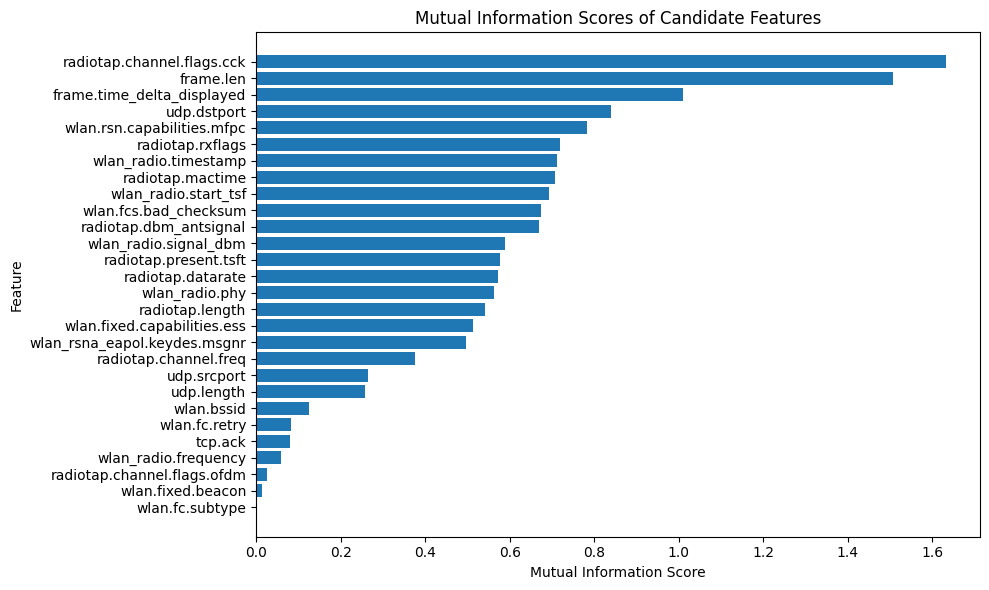

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    mi_df["Feature"],
    mi_df["MI_Score"]
)

plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title("Mutual Information Scores of Candidate Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [99]:
print("MI summary:")
print(mi_df["MI_Score"].describe())

print("\nFeatures with MI < 0.1:")
print(
    mi_df[mi_df["MI_Score"] < 0.1][["Feature", "MI_Score"]]
)

MI summary:
count    28.000000
mean      0.538500
std       0.407981
min       0.000506
25%       0.223802
50%       0.567535
75%       0.708902
max       1.631092
Name: MI_Score, dtype: float64

Features with MI < 0.1:
                        Feature  MI_Score
12                wlan.fc.retry  0.082552
24                      tcp.ack  0.079823
17         wlan_radio.frequency  0.057632
3   radiotap.channel.flags.ofdm  0.025681
15            wlan.fixed.beacon  0.013219
13              wlan.fc.subtype  0.000506


In [100]:
MI_THRESHOLD = 0.1

selected_features = (
    mi_df[mi_df["MI_Score"] >= MI_THRESHOLD]["Feature"]
    .tolist()
)

print("Selected features:", len(selected_features))
print()

for i, feature in enumerate(selected_features, 1):
    score = mi_df.loc[mi_df["Feature"] == feature, "MI_Score"].iloc[0]
    print(f"{i:2d}. {feature:<45} {score:.6f}")

Selected features: 22

 1. radiotap.channel.flags.cck                    1.631092
 2. frame.len                                     1.507686
 3. frame.time_delta_displayed                    1.009538
 4. udp.dstport                                   0.838498
 5. wlan.rsn.capabilities.mfpc                    0.783415
 6. radiotap.rxflags                              0.719043
 7. wlan_radio.timestamp                          0.711475
 8. radiotap.mactime                              0.708045
 9. wlan_radio.start_tsf                          0.693924
10. wlan.fcs.bad_checksum                         0.673978
11. radiotap.dbm_antsignal                        0.669886
12. wlan_radio.signal_dbm                         0.587648
13. radiotap.present.tsft                         0.576903
14. radiotap.datarate                             0.571425
15. wlan_radio.phy                                0.563645
16. radiotap.length                               0.540598
17. wlan.fixed.capabilities.ess  

In [101]:
X_train_mi = X_train[selected_features].copy()
X_test_mi = X_test[selected_features].copy()

print("\nX_train_mi:", X_train_mi.shape)
print("X_test_mi :", X_test_mi.shape)


X_train_mi: (688498, 22)
X_test_mi : (172148, 22)


In [102]:
!pip install -q xgboost

In [104]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [105]:
import time
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

start_time = time.time()

xgb_model.fit(
    X_train_mi,
    y_train_encoded,
    eval_set=[(X_test_mi, y_test_encoded)],
    verbose=50
)

xgb_train_time = time.time() - start_time

print(f"\nTraining time: {xgb_train_time:.2f} seconds")

[0]	validation_0-mlogloss:1.52482
[50]	validation_0-mlogloss:0.04988
[100]	validation_0-mlogloss:0.03747
[150]	validation_0-mlogloss:0.03584
[200]	validation_0-mlogloss:0.03545
[250]	validation_0-mlogloss:0.03540
[300]	validation_0-mlogloss:0.03549
[350]	validation_0-mlogloss:0.03556
[400]	validation_0-mlogloss:0.03568
[450]	validation_0-mlogloss:0.03578
[499]	validation_0-mlogloss:0.03592

Training time: 559.14 seconds


In [106]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Class predictions
xgb_pred = xgb_model.predict(X_test_mi)

# Class probabilities — needed later for ensemble fusion
xgb_proba = xgb_model.predict_proba(X_test_mi)

print("Prediction shape:", xgb_pred.shape)
print("Probability shape:", xgb_proba.shape)

print("\nOverall metrics")
print("----------------")
print(f"Accuracy : {accuracy_score(y_test_encoded, xgb_pred):.4f}")
print(f"Precision: {precision_score(y_test_encoded, xgb_pred, average='macro'):.4f}")
print(f"Recall   : {recall_score(y_test_encoded, xgb_pred, average='macro'):.4f}")
print(f"Macro-F1 : {f1_score(y_test_encoded, xgb_pred, average='macro'):.4f}")
print(f"Weighted-F1: {f1_score(y_test_encoded, xgb_pred, average='weighted'):.4f}")

print("\nPer-class results")
print("-----------------")

report = classification_report(
    y_test_encoded,
    xgb_pred,
    target_names=label_encoder.classes_,
    digits=4
)

print(report)

Prediction shape: (172148,)
Probability shape: (172148, 12)

Overall metrics
----------------
Accuracy : 0.9789
Precision: 0.9599
Recall   : 0.9535
Macro-F1 : 0.9564
Weighted-F1: 0.9784

Per-class results
-----------------
                   precision    recall  f1-score   support

       BruteForce     0.9998    0.9986    0.9992     35185
             DDoS     1.0000    0.9999    1.0000     38636
De-authentication     0.9328    0.9035    0.9179      2921
              DoS     1.0000    1.0000    1.0000      1285
      FakeLanding     0.7011    0.6198    0.6579      4810
    ICMP Flooding     1.0000    1.0000    1.0000      9509
          Jamming     1.0000    1.0000    1.0000      8320
             MITM     0.9392    0.9580    0.9485     30317
           Normal     0.9992    0.9986    0.9989      3609
         Scanning     1.0000    1.0000    1.0000      1806
     UDP Flooding     1.0000    1.0000    1.0000     30555
           replay     0.9467    0.9634    0.9550      5195

        

In [108]:
import os
import joblib
import pandas as pd

RESULTS_DIR = "/content/drive/MyDrive/UAV_NIDD_Project/results"
MODELS_DIR = "/content/drive/MyDrive/UAV_NIDD_Project/models"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Save model
joblib.dump(
    xgb_model,
    os.path.join(MODELS_DIR, "xgboost_mi_model.pkl")
)

# Save MI feature ranking
mi_df.to_csv(
    os.path.join(RESULTS_DIR, "mutual_information_scores.csv"),
    index=False
)

# Save selected features
pd.DataFrame({
    "Feature": selected_features
}).to_csv(
    os.path.join(RESULTS_DIR, "selected_mi_features.csv"),
    index=False
)

print("XGBoost model and MI results saved to Drive.")

XGBoost model and MI results saved to Drive.


In [109]:
print("Train index range:")
print(train_df.index.min(), "to", train_df.index.max())

print("\nTest index range:")
print(test_df.index.min(), "to", test_df.index.max())

print("\nFirst 10 train indices:")
print(train_df.index[:10].tolist())

print("\nFirst 10 test indices:")
print(test_df.index[:10].tolist())

Train index range:
0 to 860651

Test index range:
3 to 860649

First 10 train indices:
[0, 1, 2, 4, 6, 8, 9, 12, 13, 14]

First 10 test indices:
[3, 5, 7, 10, 11, 29, 30, 35, 38, 43]


In [110]:
import numpy as np

SEQUENCE_LENGTH = 20
STRIDE = 20

def create_sequences(X, y, sequence_length=20, stride=20):
    X_values = X.to_numpy(dtype=np.float32)
    y_values = np.asarray(y)

    sequences = []
    labels = []

    for start in range(0, len(X_values) - sequence_length + 1, stride):
        end = start + sequence_length

        sequences.append(X_values[start:end])
        labels.append(y_values[end - 1])

    return np.array(sequences, dtype=np.float32), np.array(labels)


X_train_tcn, y_train_tcn = create_sequences(
    X_train_mi,
    y_train_encoded,
    SEQUENCE_LENGTH,
    STRIDE
)

X_test_tcn, y_test_tcn = create_sequences(
    X_test_mi,
    y_test_encoded,
    SEQUENCE_LENGTH,
    STRIDE
)

print("X_train_tcn:", X_train_tcn.shape)
print("y_train_tcn:", y_train_tcn.shape)

print("\nX_test_tcn :", X_test_tcn.shape)
print("y_test_tcn :", y_test_tcn.shape)

X_train_tcn: (34424, 20, 22)
y_train_tcn: (34424,)

X_test_tcn : (8607, 20, 22)
y_test_tcn : (8607,)


In [111]:
from collections import Counter

print("Training sequence distribution:")
train_seq_counts = Counter(y_train_tcn)

for class_id, count in sorted(train_seq_counts.items()):
    print(
        f"{class_id:2d} -> "
        f"{label_encoder.classes_[class_id]:20s} : {count}"
    )

print("\nTest sequence distribution:")
test_seq_counts = Counter(y_test_tcn)

for class_id, count in sorted(test_seq_counts.items()):
    print(
        f"{class_id:2d} -> "
        f"{label_encoder.classes_[class_id]:20s} : {count}"
    )

Training sequence distribution:
 0 -> BruteForce           : 7037
 1 -> DDoS                 : 7727
 2 -> De-authentication    : 584
 3 -> DoS                  : 257
 4 -> FakeLanding          : 962
 5 -> ICMP Flooding        : 1901
 6 -> Jamming              : 1664
 7 -> MITM                 : 6064
 8 -> Normal               : 717
 9 -> Scanning             : 361
10 -> UDP Flooding         : 6111
11 -> replay               : 1039

Test sequence distribution:
 0 -> BruteForce           : 1759
 1 -> DDoS                 : 1932
 2 -> De-authentication    : 146
 3 -> DoS                  : 63
 4 -> FakeLanding          : 240
 5 -> ICMP Flooding        : 475
 6 -> Jamming              : 416
 7 -> MITM                 : 1516
 8 -> Normal               : 180
 9 -> Scanning             : 91
10 -> UDP Flooding         : 1529
11 -> replay               : 260


In [112]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version: 2.20.0
GPU available: False


In [113]:
import tensorflow as tf
from tensorflow.keras import layers, models

NUM_CLASSES = len(label_encoder.classes_)
NUM_FEATURES = X_train_tcn.shape[2]

tcn_model = models.Sequential([
    layers.Input(shape=(SEQUENCE_LENGTH, NUM_FEATURES)),

    layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="causal",
        dilation_rate=1,
        activation="relu"
    ),

    layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="causal",
        dilation_rate=2,
        activation="relu"
    ),

    layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="causal",
        dilation_rate=4,
        activation="relu"
    ),

    layers.GlobalAveragePooling1D(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

tcn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

tcn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 20, 64)         │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 20, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 20, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,932 (132.55 KB)

 Trainable params: 33,932 (132.55 KB)

 Non-trainable params: 0 (0.00 B)

In [114]:
import time
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

tcn_start_time = time.time()

tcn_history = tcn_model.fit(
    X_train_tcn,
    y_train_tcn,
    validation_split=0.15,
    epochs=20,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1,
    shuffle=False
)

tcn_train_time = time.time() - tcn_start_time

print(f"\nTCN training time: {tcn_train_time:.2f} seconds")

Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.2416 - loss: 1385907328.0000 - val_accuracy: 0.0000e+00 - val_loss: 1116.2097
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.0633 - loss: 539182720.0000 - val_accuracy: 0.0000e+00 - val_loss: 267.2577
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.0449 - loss: 121514216.0000 - val_accuracy: 5.8094e-04 - val_loss: 54.7581
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.0675 - loss: 43112560.0000 - val_accuracy: 0.3772 - val_loss: 14.3837
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.1176 - loss: 17204618.0000 - val_accuracy: 0.9700 - val_loss: 0.2155
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.1109 - loss: 28089656.0000 - val_accuracy: 0.0000e+00 - val_loss: 52.9577
Epoch 7/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.1036 - loss: 23526642.0000 - val_accuracy: 0.0000e+00 - val_loss: 22.4247
Epoch 8/20
115/

In [115]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler_tcn = StandardScaler()

X_train_tcn_scaled_2d = scaler_tcn.fit_transform(
    X_train_mi
)

X_test_tcn_scaled_2d = scaler_tcn.transform(
    X_test_mi
)

# Convert back to sequences
X_train_tcn_scaled, y_train_tcn_scaled = create_sequences(
    pd.DataFrame(X_train_tcn_scaled_2d, columns=selected_features),
    y_train_encoded,
    SEQUENCE_LENGTH,
    STRIDE
)

X_test_tcn_scaled, y_test_tcn_scaled = create_sequences(
    pd.DataFrame(X_test_tcn_scaled_2d, columns=selected_features),
    y_test_encoded,
    SEQUENCE_LENGTH,
    STRIDE
)

print("Train:", X_train_tcn_scaled.shape)
print("Test :", X_test_tcn_scaled.shape)

Train: (34424, 20, 22)
Test : (8607, 20, 22)


In [116]:
print("Max absolute scaled value:",
      np.max(np.abs(X_train_tcn_scaled)))

print("Mean:",
      np.mean(X_train_tcn_scaled))

print("Std:",
      np.std(X_train_tcn_scaled))

Max absolute scaled value: 387.10092
Mean: 2.024067e-06
Std: 1.000009


In [122]:
import tensorflow as tf
from tensorflow.keras import layers, models

NUM_CLASSES = len(label_encoder.classes_)
NUM_FEATURES = X_train_tcn_scaled.shape[2]

tcn_model = models.Sequential([
    layers.Input(shape=(SEQUENCE_LENGTH, NUM_FEATURES)),

    layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="causal",
        dilation_rate=1,
        activation="relu"
    ),

    layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="causal",
        dilation_rate=2,
        activation="relu"
    ),

    layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="causal",
        dilation_rate=4,
        activation="relu"
    ),

    layers.GlobalAveragePooling1D(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(NUM_CLASSES, activation="softmax")
])

tcn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005,
        clipnorm=1.0
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

tcn_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_18 (Conv1D)              │ (None, 20, 64)         │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_19 (Conv1D)              │ (None, 20, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_20 (Conv1D)              │ (None, 20, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_6      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,932 (132.55 KB)

 Trainable params: 33,932 (132.55 KB)

 Non-trainable params: 0 (0.00 B)

In [123]:
from tensorflow.keras.callbacks import EarlyStopping
import time

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

tcn_start_time = time.time()

tcn_history = tcn_model.fit(
    X_train_tcn_scaled,
    y_train_tcn_scaled,
    validation_split=0.15,
    epochs=20,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1,
    shuffle=False
)

tcn_train_time = time.time() - tcn_start_time

print(f"\nTCN training time: {tcn_train_time:.2f} seconds")

Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.1666 - loss: 2.6620 - val_accuracy: 0.0000e+00 - val_loss: 2.5273
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.3569 - loss: 1.8864 - val_accuracy: 0.0000e+00 - val_loss: 2.4620
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.3486 - loss: 1.7323 - val_accuracy: 0.8608 - val_loss: 2.4014
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.4411 - loss: 1.5002 - val_accuracy: 0.9996 - val_loss: 2.0944
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.4858 - loss: 1.3027 - val_accuracy: 1.0000 - val_loss: 1.1258
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.5361 - loss: 1.1428 - val_accuracy: 1.0000 - val_loss: 0.6122
Epoch 7/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.5308 - loss: 1.0134 - val_accuracy: 1.0000 - val_loss: 0.0329
Epoch 8/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.5371 - loss: 0.9167 -

In [124]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predict on completely held-out test sequences
tcn_proba = tcn_model.predict(
    X_test_tcn_scaled,
    verbose=1
)

tcn_pred = np.argmax(tcn_proba, axis=1)

print("TCN Test Accuracy:",
      accuracy_score(y_test_tcn_scaled, tcn_pred))

print("TCN Test Macro Precision:",
      precision_score(
          y_test_tcn_scaled,
          tcn_pred,
          average="macro",
          zero_division=0
      ))

print("TCN Test Macro Recall:",
      recall_score(
          y_test_tcn_scaled,
          tcn_pred,
          average="macro",
          zero_division=0
      ))

print("TCN Test Macro F1:",
      f1_score(
          y_test_tcn_scaled,
          tcn_pred,
          average="macro",
          zero_division=0
      ))

print("\nClassification Report:\n")

print(
    classification_report(
        y_test_tcn_scaled,
        tcn_pred,
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0
    )
)

269/269 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
TCN Test Accuracy: 0.8139886139189032
TCN Test Macro Precision: 0.5782449625587217
TCN Test Macro Recall: 0.5974939713776922
TCN Test Macro F1: 0.5679123702207292

Classification Report:

                   precision    recall  f1-score   support

       BruteForce     0.9741    0.4918    0.6536      1759
             DDoS     1.0000    0.9990    0.9995      1932
De-authentication     0.0000    0.0000    0.0000       146
              DoS     0.0000    0.0000    0.0000        63
      FakeLanding     0.0000    0.0000    0.0000       240
    ICMP Flooding     1.0000    0.7011    0.8243       475
          Jamming     0.9976    0.9952    0.9964       416
             MITM     0.5688    0.9868    0.7217      1516
           Normal     0.9945    1.0000    0.9972       180
         Scanning     0.0000    0.0000    0.0000        91
     UDP Flooding     0.8818    1.0000    0.9372      1529
           replay     0.5222    0.9962    0.6852       260

  

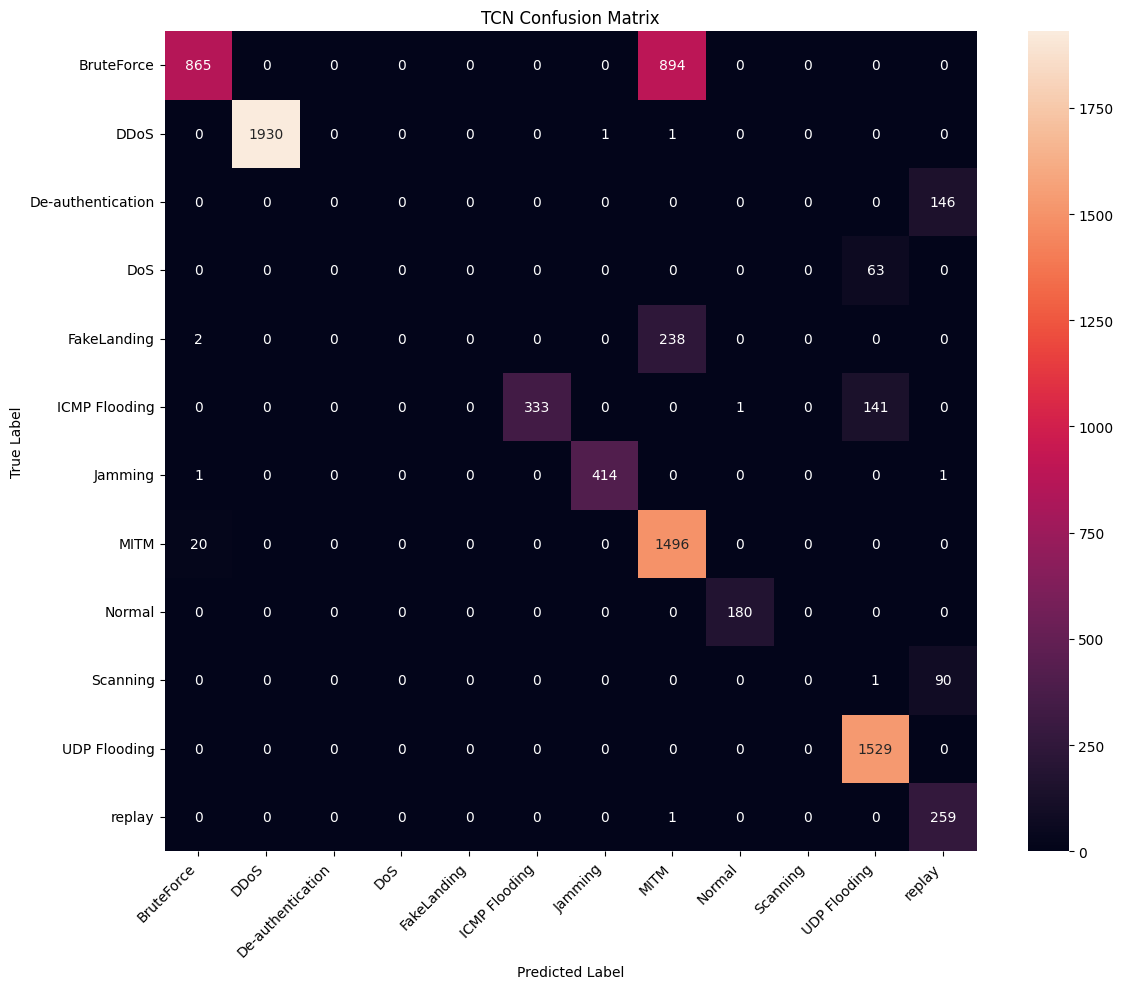

In [125]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test_tcn_scaled,
    tcn_pred
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("TCN Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [126]:
# Make sure the original order is preserved
ordered_df = df_model.sort_index().copy()

# Mark each row according to our existing duplicate-aware train/test split
train_group_set = set(train_groups)
test_group_set = set(test_groups)

ordered_df["partition"] = ordered_df["duplicate_group"].apply(
    lambda x: "train" if x in train_group_set else "test"
)

print("Total ordered rows:", len(ordered_df))
print(ordered_df["partition"].value_counts())

Total ordered rows: 860646
partition
train    688498
test     172148
Name: count, dtype: int64


In [127]:
SEQUENCE_LENGTH = 20
STRIDE = 20

def create_clean_temporal_sequences(df, feature_columns, sequence_length=20, stride=20):

    X_sequences = []
    y_sequences = []
    partitions = []

    values = df[feature_columns].apply(
        pd.to_numeric,
        errors="coerce"
    ).to_numpy(dtype=np.float32)

    labels = df["Label"].to_numpy()
    partition_values = df["partition"].to_numpy()

    original_indices = df.index.to_numpy()

    for start in range(
        0,
        len(df) - sequence_length + 1,
        stride
    ):

        end = start + sequence_length

        # The actual original row indices
        window_indices = original_indices[start:end]

        # Check that rows are genuinely consecutive
        if not np.all(np.diff(window_indices) == 1):
            continue

        # Do not allow train/test mixing inside a sequence
        window_partition = partition_values[start:end]

        if not np.all(window_partition == window_partition[0]):
            continue

        X_sequences.append(values[start:end])

        # Label = label of the final packet in the sequence
        y_sequences.append(labels[end - 1])

        partitions.append(window_partition[0])

    return (
        np.array(X_sequences, dtype=np.float32),
        np.array(y_sequences),
        np.array(partitions)
    )


X_temp, y_temp, partition_temp = create_clean_temporal_sequences(
    ordered_df,
    selected_features,
    SEQUENCE_LENGTH,
    STRIDE
)

print("All valid temporal sequences:", X_temp.shape)
print("Labels:", y_temp.shape)
print("Partitions:", partition_temp.shape)

print("\nSequence partition distribution:")
print(pd.Series(partition_temp).value_counts())

All valid temporal sequences: (480, 20, 22)
Labels: (480,)
Partitions: (480,)

Sequence partition distribution:
train    480
Name: count, dtype: int64


In [128]:
X_train_tcn_clean = X_temp[partition_temp == "train"]
y_train_tcn_clean = y_temp[partition_temp == "train"]

X_test_tcn_clean = X_temp[partition_temp == "test"]
y_test_tcn_clean = y_temp[partition_temp == "test"]

print("Clean TCN train:", X_train_tcn_clean.shape)
print("Clean TCN test :", X_test_tcn_clean.shape)

print("\nTrain class distribution:")
print(pd.Series(y_train_tcn_clean).value_counts().sort_index())

print("\nTest class distribution:")
print(pd.Series(y_test_tcn_clean).value_counts().sort_index())

Clean TCN train: (480, 20, 22)
Clean TCN test : (0, 20, 22)

Train class distribution:
BruteForce            88
DDoS                 118
De-authentication      9
DoS                    1
FakeLanding           12
ICMP Flooding         28
Jamming               24
MITM                  87
Normal                 5
Scanning               4
UDP Flooding          91
replay                13
Name: count, dtype: int64

Test class distribution:
Series([], Name: count, dtype: int64)


In [129]:
# Proposed chronological split points
n = len(df_model)

train_end = int(n * 0.70)
val_end = int(n * 0.80)

print("Total rows:", n)
print("Train rows:", train_end)
print("Validation rows:", val_end - train_end)
print("Test rows:", n - val_end)

# Original row-order positions
train_indices = df_model.index[:train_end]
val_indices = df_model.index[train_end:val_end]
test_indices = df_model.index[val_end:]

# Duplicate groups in each temporal partition
train_dup_groups = set(
    df_model.loc[train_indices, "duplicate_group"]
)

val_dup_groups = set(
    df_model.loc[val_indices, "duplicate_group"]
)

test_dup_groups = set(
    df_model.loc[test_indices, "duplicate_group"]
)

print("\nDuplicate groups shared between:")
print("Train & Validation:", len(train_dup_groups & val_dup_groups))
print("Train & Test:", len(train_dup_groups & test_dup_groups))
print("Validation & Test:", len(val_dup_groups & test_dup_groups))

Total rows: 860646
Train rows: 602452
Validation rows: 86064
Test rows: 172130

Duplicate groups shared between:
Train & Validation: 0
Train & Test: 0
Validation & Test: 0


In [130]:
# Sort by the original dataset order
df_temporal = df_model.sort_index().copy()

n = len(df_temporal)

train_end = int(n * 0.70)
val_end = int(n * 0.80)

train_temporal = df_temporal.iloc[:train_end].copy()
val_temporal = df_temporal.iloc[train_end:val_end].copy()
test_temporal = df_temporal.iloc[val_end:].copy()

print("Train:", train_temporal.shape)
print("Validation:", val_temporal.shape)
print("Test:", test_temporal.shape)

print("\nOriginal index ranges:")
print("Train:", train_temporal.index.min(), "→", train_temporal.index.max())
print("Validation:", val_temporal.index.min(), "→", val_temporal.index.max())
print("Test:", test_temporal.index.min(), "→", test_temporal.index.max())

Train: (602452, 46)
Validation: (86064, 46)
Test: (172130, 46)

Original index ranges:
Train: 0 → 602457
Validation: 602458 → 688521
Test: 688522 → 860651


In [131]:
def create_temporal_sequences(
    df,
    feature_columns,
    sequence_length=20,
    stride=20
):
    X_values = df[feature_columns].apply(
        pd.to_numeric,
        errors="coerce"
    ).to_numpy(dtype=np.float32)

    y_values = df["Label"].to_numpy()
    original_indices = df.index.to_numpy()

    X_sequences = []
    y_sequences = []

    for start in range(
        0,
        len(df) - sequence_length + 1,
        stride
    ):
        end = start + sequence_length

        # Make sure these are genuinely consecutive
        indices = original_indices[start:end]

        if not np.all(np.diff(indices) == 1):
            continue

        X_sequences.append(X_values[start:end])

        # Label of final packet in the window
        y_sequences.append(y_values[end - 1])

    return (
        np.array(X_sequences, dtype=np.float32),
        np.array(y_sequences)
    )


X_train_temporal, y_train_temporal = create_temporal_sequences(
    train_temporal,
    selected_features,
    SEQUENCE_LENGTH,
    STRIDE
)

X_val_temporal, y_val_temporal = create_temporal_sequences(
    val_temporal,
    selected_features,
    SEQUENCE_LENGTH,
    STRIDE
)

X_test_temporal, y_test_temporal = create_temporal_sequences(
    test_temporal,
    selected_features,
    SEQUENCE_LENGTH,
    STRIDE
)

print("Train sequences:", X_train_temporal.shape)
print("Validation sequences:", X_val_temporal.shape)
print("Test sequences:", X_test_temporal.shape)

Train sequences: (30121, 20, 22)
Validation sequences: (4303, 20, 22)
Test sequences: (8606, 20, 22)


In [132]:
print("TRAIN")
print(pd.Series(y_train_temporal).value_counts().sort_index())

print("\nVALIDATION")
print(pd.Series(y_val_temporal).value_counts().sort_index())

print("\nTEST")
print(pd.Series(y_test_temporal).value_counts().sort_index())

TRAIN
BruteForce           8795
De-authentication     730
DoS                   322
FakeLanding          1203
ICMP Flooding        2377
MITM                 7579
Normal                897
Scanning              452
UDP Flooding         7638
replay                128
Name: count, dtype: int64

VALIDATION
DDoS       1053
Jamming    2080
replay     1170
Name: count, dtype: int64

TEST
DDoS    8606
Name: count, dtype: int64


In [133]:
# Inspect where the attack/traffic label changes in the original order

labels_ordered = df_model.sort_index()["Label"].to_numpy()

change_positions = np.where(labels_ordered[1:] != labels_ordered[:-1])[0] + 1

print("Number of label transitions:", len(change_positions))

print("\nFirst 30 transitions:")
for pos in change_positions[:30]:
    previous_label = labels_ordered[pos - 1]
    next_label = labels_ordered[pos]

    print(
        f"Row {pos}: "
        f"{previous_label} -> {next_label}"
    )

print("\nLast 30 transitions:")
for pos in change_positions[-30:]:
    previous_label = labels_ordered[pos - 1]
    next_label = labels_ordered[pos]

    print(
        f"Row {pos}: "
        f"{previous_label} -> {next_label}"
    )

Number of label transitions: 13

First 30 transitions:
Row 17949: Normal -> ICMP Flooding
Row 65493: ICMP Flooding -> UDP Flooding
Row 217198: UDP Flooding -> DoS
Row 220409: DoS -> UDP Flooding
Row 221479: UDP Flooding -> DoS
Row 224692: DoS -> Scanning
Row 233722: Scanning -> BruteForce
Row 409647: BruteForce -> MITM
Row 561233: MITM -> De-authentication
Row 575839: De-authentication -> FakeLanding
Row 599889: FakeLanding -> replay
Row 625866: replay -> Jamming
Row 667466: Jamming -> DDoS

Last 30 transitions:
Row 17949: Normal -> ICMP Flooding
Row 65493: ICMP Flooding -> UDP Flooding
Row 217198: UDP Flooding -> DoS
Row 220409: DoS -> UDP Flooding
Row 221479: UDP Flooding -> DoS
Row 224692: DoS -> Scanning
Row 233722: Scanning -> BruteForce
Row 409647: BruteForce -> MITM
Row 561233: MITM -> De-authentication
Row 575839: De-authentication -> FakeLanding
Row 599889: FakeLanding -> replay
Row 625866: replay -> Jamming
Row 667466: Jamming -> DDoS


In [134]:
# Length of each consecutive label block

block_starts = np.r_[0, change_positions]
block_ends = np.r_[change_positions, len(labels_ordered)]

blocks = pd.DataFrame({
    "Start": block_starts,
    "End": block_ends - 1,
    "Label": [
        labels_ordered[start]
        for start in block_starts
    ]
})

blocks["Length"] = blocks["End"] - blocks["Start"] + 1

print(blocks.to_string(index=False))

 Start    End             Label  Length
     0  17948            Normal   17949
 17949  65492     ICMP Flooding   47544
 65493 217197      UDP Flooding  151705
217198 220408               DoS    3211
220409 221478      UDP Flooding    1070
221479 224691               DoS    3213
224692 233721          Scanning    9030
233722 409646        BruteForce  175925
409647 561232              MITM  151586
561233 575838 De-authentication   14606
575839 599888       FakeLanding   24050
599889 625865            replay   25977
625866 667465           Jamming   41600
667466 860645              DDoS  193180


In [136]:
# Identify contiguous label blocks in the original dataset

ordered_df = df_model.sort_index().copy()

labels = ordered_df["Label"].to_numpy()

change_positions = np.where(
    labels[1:] != labels[:-1]
)[0] + 1

block_starts = np.r_[0, change_positions]
block_ends = np.r_[change_positions, len(ordered_df)]

blocks = []

for i, (start, end) in enumerate(
    zip(block_starts, block_ends)
):
    block = ordered_df.iloc[start:end]

    blocks.append({
        "block_id": i,
        "start_position": start,
        "end_position": end - 1,
        "original_start": block.index.min(),
        "original_end": block.index.max(),
        "label": block["Label"].iloc[0],
        "rows": len(block)
    })

blocks_df = pd.DataFrame(blocks)

print(blocks_df.to_string(index=False))

 block_id  start_position  end_position  original_start  original_end             label   rows
        0               0         17948               0         17948            Normal  17949
        1           17949         65492           17949         65492     ICMP Flooding  47544
        2           65493        217197           65493        217197      UDP Flooding 151705
        3          217198        220408          217198        220408               DoS   3211
        4          220409        221478          220409        221478      UDP Flooding   1070
        5          221479        224691          221479        224691               DoS   3213
        6          224692        233721          224692        233721          Scanning   9030
        7          233722        409646          233728        409652        BruteForce 175925
        8          409647        561232          409653        561238              MITM 151586
        9          561233        575838          5

In [137]:
SEQUENCE_LENGTH = 20
STRIDE = 20

train_parts = []
val_parts = []
test_parts = []

for _, block_info in blocks_df.iterrows():

    start = int(block_info["start_position"])
    end = int(block_info["end_position"]) + 1

    block = ordered_df.iloc[start:end].copy()

    n = len(block)

    train_end = int(n * 0.70)
    val_end = int(n * 0.80)

    train_block = block.iloc[:train_end]
    val_block = block.iloc[train_end:val_end]
    test_block = block.iloc[val_end:]

    train_parts.append(train_block)
    val_parts.append(val_block)
    test_parts.append(test_block)

train_temporal = pd.concat(train_parts)
val_temporal = pd.concat(val_parts)
test_temporal = pd.concat(test_parts)

print("Train rows:", len(train_temporal))
print("Validation rows:", len(val_temporal))
print("Test rows:", len(test_temporal))

print("\nTrain labels:")
print(train_temporal["Label"].value_counts())

print("\nValidation labels:")
print(val_temporal["Label"].value_counts())

print("\nTest labels:")
print(test_temporal["Label"].value_counts())

Train rows: 602447
Validation rows: 86066
Test rows: 172133

Train labels:
Label
DDoS                 135226
BruteForce           123147
UDP Flooding         106942
MITM                 106110
ICMP Flooding         33280
Jamming               29119
replay                18183
FakeLanding           16835
Normal                12564
De-authentication     10224
Scanning               6321
DoS                    4496
Name: count, dtype: int64

Validation labels:
Label
DDoS                 19318
BruteForce           17593
UDP Flooding         15278
MITM                 15158
ICMP Flooding         4755
Jamming               4161
replay                2598
FakeLanding           2405
Normal                1795
De-authentication     1460
Scanning               903
DoS                    642
Name: count, dtype: int64

Test labels:
Label
DDoS                 38636
BruteForce           35185
UDP Flooding         30555
MITM                 30318
ICMP Flooding         9509
Jamming               8320

In [145]:
def make_sequences_from_blocks(
    block_list,
    feature_columns,
    sequence_length=20,
    stride=20
):
    X_all = []
    y_all = []

    for block in block_list:

        X_values = block[feature_columns].apply(
            pd.to_numeric,
            errors="coerce"
        ).to_numpy(dtype=np.float32)

        y_values = block["Label"].to_numpy()

        for start in range(
            0,
            len(block) - sequence_length + 1,
            stride
        ):
            end = start + sequence_length

            X_all.append(
                X_values[start:end]
            )

            y_all.append(
                y_values[end - 1]
            )

    return (
        np.array(X_all, dtype=np.float32),
        np.array(y_all)
    )

In [148]:
X_train_temporal, y_train_temporal = make_sequences_from_blocks(
    train_parts,
    selected_features,
    SEQUENCE_LENGTH,
    STRIDE
)

X_val_temporal, y_val_temporal = make_sequences_from_blocks(
    val_parts,
    selected_features,
    SEQUENCE_LENGTH,
    STRIDE
)

X_test_temporal, y_test_temporal = make_sequences_from_blocks(
    test_parts,
    selected_features,
    SEQUENCE_LENGTH,
    STRIDE
)

In [149]:
print("Train sequences:", X_train_temporal.shape)
print("Validation sequences:", X_val_temporal.shape)
print("Test sequences:", X_test_temporal.shape)

print("\nTRAIN")
print(pd.Series(y_train_temporal).value_counts().sort_index())

print("\nVALIDATION")
print(pd.Series(y_val_temporal).value_counts().sort_index())

print("\nTEST")
print(pd.Series(y_test_temporal).value_counts().sort_index())

Train sequences: (30117, 20, 22)
Validation sequences: (4297, 20, 22)
Test sequences: (8601, 20, 22)

TRAIN
BruteForce           6157
DDoS                 6761
De-authentication     511
DoS                   224
FakeLanding           841
ICMP Flooding        1664
Jamming              1455
MITM                 5305
Normal                628
Scanning              316
UDP Flooding         5346
replay                909
Name: count, dtype: int64

VALIDATION
BruteForce           879
DDoS                 965
De-authentication     73
DoS                   32
FakeLanding          120
ICMP Flooding        237
Jamming              208
MITM                 757
Normal                89
Scanning              45
UDP Flooding         763
replay               129
Name: count, dtype: int64

TEST
BruteForce           1759
DDoS                 1931
De-authentication     146
DoS                    64
FakeLanding           240
ICMP Flooding         475
Jamming               416
MITM                 1515
No

In [151]:
train_groups = set(train_temporal["duplicate_group"])
val_groups = set(val_temporal["duplicate_group"])
test_groups = set(test_temporal["duplicate_group"])

print("Train-Val overlap:", len(train_groups & val_groups))
print("Train-Test overlap:", len(train_groups & test_groups))
print("Val-Test overlap:", len(val_groups & test_groups))

Train-Val overlap: 1795
Train-Test overlap: 3590
Val-Test overlap: 0


In [152]:
# Find overlapping duplicate groups
train_val_overlap = train_groups & val_groups
train_test_overlap = train_groups & test_groups

print("Train-Val overlapping groups:", len(train_val_overlap))
print("Train-Test overlapping groups:", len(train_test_overlap))

# How many rows are involved?
print(
    "Train rows in Train-Val overlap:",
    train_temporal["duplicate_group"].isin(train_val_overlap).sum()
)

print(
    "Validation rows in Train-Val overlap:",
    val_temporal["duplicate_group"].isin(train_val_overlap).sum()
)

print(
    "Train rows in Train-Test overlap:",
    train_temporal["duplicate_group"].isin(train_test_overlap).sum()
)

print(
    "Test rows in Train-Test overlap:",
    test_temporal["duplicate_group"].isin(train_test_overlap).sum()
)

Train-Val overlapping groups: 1795
Train-Test overlapping groups: 3590
Train rows in Train-Val overlap: 1867
Validation rows in Train-Val overlap: 1795
Train rows in Train-Test overlap: 6805
Test rows in Train-Test overlap: 3590


In [153]:
print(
    "\nTrain-Val overlap labels:"
)
print(
    train_temporal[
        train_temporal["duplicate_group"].isin(train_val_overlap)
    ]["Label"].value_counts()
)

print(
    "\nTrain-Test overlap labels:"
)
print(
    train_temporal[
        train_temporal["duplicate_group"].isin(train_test_overlap)
    ]["Label"].value_counts()
)


Train-Val overlap labels:
Label
Normal    1867
Name: count, dtype: int64

Train-Test overlap labels:
Label
Normal    6805
Name: count, dtype: int64


In [154]:
normal_train = train_temporal[
    train_temporal["Label"] == "Normal"
].copy()

normal_val = val_temporal[
    val_temporal["Label"] == "Normal"
].copy()

normal_test = test_temporal[
    test_temporal["Label"] == "Normal"
].copy()

print("Normal rows:")
print("Train:", len(normal_train))
print("Validation:", len(normal_val))
print("Test:", len(normal_test))

print("\nUnique duplicate groups:")
print(
    "Train:",
    normal_train["duplicate_group"].nunique()
)
print(
    "Validation:",
    normal_val["duplicate_group"].nunique()
)
print(
    "Test:",
    normal_test["duplicate_group"].nunique()
)

print("\nRepeated rows within each partition:")
print(
    "Train:",
    len(normal_train) -
    normal_train["duplicate_group"].nunique()
)
print(
    "Validation:",
    len(normal_val) -
    normal_val["duplicate_group"].nunique()
)
print(
    "Test:",
    len(normal_test) -
    normal_test["duplicate_group"].nunique()
)

Normal rows:
Train: 12564
Validation: 1795
Test: 3590

Unique duplicate groups:
Train: 6358
Validation: 1795
Test: 3590

Repeated rows within each partition:
Train: 6206
Validation: 0
Test: 0


In [155]:
normal_duplicate_counts = (
    pd.concat([
        normal_train[["duplicate_group"]],
        normal_val[["duplicate_group"]],
        normal_test[["duplicate_group"]]
    ])
    .groupby("duplicate_group")
    .size()
)

print("\nNormal duplicate-group size distribution:")
print(normal_duplicate_counts.value_counts().sort_index())

print(
    "\nMaximum rows belonging to one duplicate group:",
    normal_duplicate_counts.max()
)


Normal duplicate-group size distribution:
2    2134
3    3215
4    1009
Name: count, dtype: int64

Maximum rows belonging to one duplicate group: 4


In [156]:
# ---------------------------------------------------------
# Remove Normal duplicate groups that have already appeared
# in an earlier partition.
# ---------------------------------------------------------

train_temporal_clean = train_temporal.copy()
val_temporal_clean = val_temporal.copy()
test_temporal_clean = test_temporal.copy()

# Duplicate groups already present in training
train_normal_groups = set(
    train_temporal_clean.loc[
        train_temporal_clean["Label"] == "Normal",
        "duplicate_group"
    ]
)

# Remove Normal groups from validation if already present in train
val_normal_mask = (
    (val_temporal_clean["Label"] == "Normal") &
    (val_temporal_clean["duplicate_group"].isin(train_normal_groups))
)

val_removed = val_normal_mask.sum()

val_temporal_clean = val_temporal_clean.loc[
    ~val_normal_mask
].copy()

# Groups now present in train + remaining validation
used_groups = set(
    train_temporal_clean["duplicate_group"]
) | set(
    val_temporal_clean["duplicate_group"]
)

# Remove Normal groups from test if already present earlier
test_normal_mask = (
    (test_temporal_clean["Label"] == "Normal") &
    (test_temporal_clean["duplicate_group"].isin(used_groups))
)

test_removed = test_normal_mask.sum()

test_temporal_clean = test_temporal_clean.loc[
    ~test_normal_mask
].copy()

print("Normal rows removed from validation:", val_removed)
print("Normal rows removed from test:", test_removed)

print("\nClean partition sizes:")
print("Train:", len(train_temporal_clean))
print("Validation:", len(val_temporal_clean))
print("Test:", len(test_temporal_clean))

Normal rows removed from validation: 1795
Normal rows removed from test: 3590

Clean partition sizes:
Train: 602447
Validation: 84271
Test: 168543


In [157]:
train_groups_clean = set(
    train_temporal_clean["duplicate_group"]
)

val_groups_clean = set(
    val_temporal_clean["duplicate_group"]
)

test_groups_clean = set(
    test_temporal_clean["duplicate_group"]
)

print("\nDuplicate-group overlap:")
print(
    "Train-Val:",
    len(train_groups_clean & val_groups_clean)
)

print(
    "Train-Test:",
    len(train_groups_clean & test_groups_clean)
)

print(
    "Val-Test:",
    len(val_groups_clean & test_groups_clean)
)


Duplicate-group overlap:
Train-Val: 0
Train-Test: 0
Val-Test: 0


In [161]:
# ---------------------------------------------------------
# Clean the original block lists
# ---------------------------------------------------------

train_clean_parts = []

for block in train_parts:
    train_clean_parts.append(block.copy())


# Validation:
# Remove Normal duplicate groups that already appeared in train
train_normal_groups = set(
    train_temporal[
        train_temporal["Label"] == "Normal"
    ]["duplicate_group"]
)

val_clean_parts = []

for block in val_parts:

    block_clean = block.copy()

    remove_mask = (
        (block_clean["Label"] == "Normal") &
        (block_clean["duplicate_group"].isin(train_normal_groups))
    )

    block_clean = block_clean.loc[~remove_mask].copy()

    if len(block_clean) > 0:
        val_clean_parts.append(block_clean)


# Test:
# Remove Normal duplicate groups already present in
# train or remaining validation
used_groups = set(
    train_temporal_clean["duplicate_group"]
) | set(
    val_temporal_clean["duplicate_group"]
)

test_clean_parts = []

for block in test_parts:

    block_clean = block.copy()

    remove_mask = (
        (block_clean["Label"] == "Normal") &
        (block_clean["duplicate_group"].isin(used_groups))
    )

    block_clean = block_clean.loc[~remove_mask].copy()

    if len(block_clean) > 0:
        test_clean_parts.append(block_clean)


print("Train blocks:", len(train_clean_parts))
print("Validation blocks:", len(val_clean_parts))
print("Test blocks:", len(test_clean_parts))

Train blocks: 14
Validation blocks: 13
Test blocks: 13


In [162]:
print(
    "Train rows:",
    sum(len(x) for x in train_clean_parts)
)

print(
    "Validation rows:",
    sum(len(x) for x in val_clean_parts)
)

print(
    "Test rows:",
    sum(len(x) for x in test_clean_parts)
)

Train rows: 602447
Validation rows: 84271
Test rows: 168543


In [170]:
def make_sequences_from_blocks(
    block_list,
    feature_columns,
    sequence_length=20,
    stride=20
):
    X_all = []
    y_all = []

    for block in block_list:

        X_values = block[feature_columns].apply(
            pd.to_numeric,
            errors="coerce"
        ).to_numpy(dtype=np.float32)

        y_values = block["Label"].to_numpy()

        for start in range(
            0,
            len(block) - sequence_length + 1,
            stride
        ):
            end = start + sequence_length

            X_all.append(
                X_values[start:end]
            )

            y_all.append(
                y_values[end - 1]
            )

    return (
        np.array(X_all, dtype=np.float32),
        np.array(y_all)
    )

In [171]:
X_train_temporal, y_train_temporal = make_sequences_from_blocks(
    train_clean_parts,
    selected_features,
    SEQUENCE_LENGTH,
    STRIDE
)

X_val_temporal, y_val_temporal = make_sequences_from_blocks(
    val_clean_parts,
    selected_features,
    SEQUENCE_LENGTH,
    STRIDE
)

X_test_temporal, y_test_temporal = make_sequences_from_blocks(
    test_clean_parts,
    selected_features,
    SEQUENCE_LENGTH,
    STRIDE
)

In [172]:
print("Train:", X_train_temporal.shape)
print("Validation:", X_val_temporal.shape)
print("Test:", X_test_temporal.shape)

print("\nTRAIN")
print(pd.Series(y_train_temporal).value_counts().sort_index())

print("\nVALIDATION")
print(pd.Series(y_val_temporal).value_counts().sort_index())

print("\nTEST")
print(pd.Series(y_test_temporal).value_counts().sort_index())

Train: (30117, 20, 22)
Validation: (4208, 20, 22)
Test: (8422, 20, 22)

TRAIN
BruteForce           6157
DDoS                 6761
De-authentication     511
DoS                   224
FakeLanding           841
ICMP Flooding        1664
Jamming              1455
MITM                 5305
Normal                628
Scanning              316
UDP Flooding         5346
replay                909
Name: count, dtype: int64

VALIDATION
BruteForce           879
DDoS                 965
De-authentication     73
DoS                   32
FakeLanding          120
ICMP Flooding        237
Jamming              208
MITM                 757
Scanning              45
UDP Flooding         763
replay               129
Name: count, dtype: int64

TEST
BruteForce           1759
DDoS                 1931
De-authentication     146
DoS                    64
FakeLanding           240
ICMP Flooding         475
Jamming               416
MITM                 1515
Scanning               90
UDP Flooding         1527
repla

In [173]:
print(
    "NaNs:",
    np.isnan(X_train_temporal).sum(),
    np.isnan(X_val_temporal).sum(),
    np.isnan(X_test_temporal).sum()
)

NaNs: 0 0 0


In [174]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler_tcn_final = StandardScaler()

# Flatten sequences temporarily:
# (samples, timesteps, features)
#       ↓
# (samples * timesteps, features)

X_train_2d = X_train_temporal.reshape(-1, X_train_temporal.shape[-1])

X_val_2d = X_val_temporal.reshape(-1, X_val_temporal.shape[-1])

X_test_2d = X_test_temporal.reshape(-1, X_test_temporal.shape[-1])

In [175]:
X_train_scaled_2d = scaler_tcn_final.fit_transform(X_train_2d)

X_val_scaled_2d = scaler_tcn_final.transform(X_val_2d)

X_test_scaled_2d = scaler_tcn_final.transform(X_test_2d)

In [176]:
X_train_scaled = X_train_scaled_2d.reshape(
    X_train_temporal.shape
)

X_val_scaled = X_val_scaled_2d.reshape(
    X_val_temporal.shape
)

X_test_scaled = X_test_scaled_2d.reshape(
    X_test_temporal.shape
)

print("Train:", X_train_scaled.shape)
print("Validation:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

Train: (30117, 20, 22)
Validation: (4208, 20, 22)
Test: (8422, 20, 22)


In [177]:
print("Train mean:", X_train_scaled.mean())
print("Train std:", X_train_scaled.std())

print("Train max abs:", np.abs(X_train_scaled).max())

print("Validation max abs:", np.abs(X_val_scaled).max())

print("Test max abs:", np.abs(X_test_scaled).max())


Train mean: 1.1906284e-09
Train std: 1.0000001
Train max abs: 385.84134
Validation max abs: 20.571276
Test max abs: 20.571276


In [178]:
y_train_tcn = label_encoder.transform(y_train_temporal)
y_val_tcn = label_encoder.transform(y_val_temporal)
y_test_tcn = label_encoder.transform(y_test_temporal)

print("Classes:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

Classes:
0 -> BruteForce
1 -> DDoS
2 -> De-authentication
3 -> DoS
4 -> FakeLanding
5 -> ICMP Flooding
6 -> Jamming
7 -> MITM
8 -> Normal
9 -> Scanning
10 -> UDP Flooding
11 -> replay


In [179]:
print("Train:", y_train_tcn.shape)
print("Validation:", y_val_tcn.shape)
print("Test:", y_test_tcn.shape)

Train: (30117,)
Validation: (4208,)
Test: (8422,)


In [180]:
import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(42)
np.random.seed(42)

SEQUENCE_LENGTH = X_train_scaled.shape[1]
NUM_FEATURES = X_train_scaled.shape[2]
NUM_CLASSES = len(label_encoder.classes_)

tcn_model = models.Sequential([

    layers.Input(
        shape=(SEQUENCE_LENGTH, NUM_FEATURES)
    ),

    layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="causal",
        dilation_rate=1,
        activation="relu"
    ),

    layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="causal",
        dilation_rate=2,
        activation="relu"
    ),

    layers.Conv1D(
        filters=64,
        kernel_size=3,
        padding="causal",
        dilation_rate=4,
        activation="relu"
    ),

    layers.GlobalAveragePooling1D(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

tcn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005,
        clipnorm=1.0
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

tcn_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_21 (Conv1D)              │ (None, 20, 64)         │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_22 (Conv1D)              │ (None, 20, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_23 (Conv1D)              │ (None, 20, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_7      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,932 (132.55 KB)

 Trainable params: 33,932 (132.55 KB)

 Non-trainable params: 0 (0.00 B)

In [181]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

start_time = time.time()

history = tcn_model.fit(
    X_train_scaled,
    y_train_tcn,

    validation_data=(
        X_val_scaled,
        y_val_tcn
    ),

    epochs=30,
    batch_size=256,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

tcn_train_time = time.time() - start_time

print(
    f"\nTCN training time: {tcn_train_time:.2f} seconds"
)

Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.6630 - loss: 1.0310 - val_accuracy: 0.7312 - val_loss: 0.5233
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.8487 - loss: 0.3724 - val_accuracy: 0.7540 - val_loss: 0.5320
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.8718 - loss: 0.3070 - val_accuracy: 0.7635 - val_loss: 0.5542
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.8792 - loss: 0.2821 - val_accuracy: 0.7640 - val_loss: 0.5771
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.8813 - loss: 0.2691 - val_accuracy: 0.7659 - val_loss: 0.5790
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.8837 - loss: 0.2611 - val_accuracy: 0.7676 - val_loss: 0.5924
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.

TCN training time: 32.54 seconds


In [182]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import numpy as np
import time

# Predict on untouched test set
start_time = time.time()

tcn_test_proba = tcn_model.predict(
    X_test_scaled,
    batch_size=256,
    verbose=1
)

tcn_inference_time = time.time() - start_time

tcn_test_pred = np.argmax(
    tcn_test_proba,
    axis=1
)

print(
    f"Test inference time: {tcn_inference_time:.2f} seconds"
)

print(
    f"Time per sequence: "
    f"{tcn_inference_time / len(X_test_scaled) * 1000:.4f} ms"
)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
Test inference time: 2.85 seconds
Time per sequence: 0.3389 ms


In [183]:
tcn_accuracy = accuracy_score(
    y_test_tcn,
    tcn_test_pred
)

tcn_macro_precision = precision_score(
    y_test_tcn,
    tcn_test_pred,
    average="macro",
    zero_division=0
)

tcn_macro_recall = recall_score(
    y_test_tcn,
    tcn_test_pred,
    average="macro",
    zero_division=0
)

tcn_macro_f1 = f1_score(
    y_test_tcn,
    tcn_test_pred,
    average="macro",
    zero_division=0
)

tcn_weighted_f1 = f1_score(
    y_test_tcn,
    tcn_test_pred,
    average="weighted",
    zero_division=0
)

print(f"Accuracy:       {tcn_accuracy:.4f}")
print(f"Macro Precision: {tcn_macro_precision:.4f}")
print(f"Macro Recall:    {tcn_macro_recall:.4f}")
print(f"Macro F1:        {tcn_macro_f1:.4f}")
print(f"Weighted F1:     {tcn_weighted_f1:.4f}")

Accuracy:       0.7547
Macro Precision: 0.5568
Macro Recall:    0.6103
Macro F1:        0.5495
Weighted F1:     0.6863


In [184]:
print(
    classification_report(
        y_test_tcn,
        tcn_test_pred,
        labels=np.arange(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                   precision    recall  f1-score   support

       BruteForce       0.53      1.00      0.70      1759
             DDoS       1.00      1.00      1.00      1931
De-authentication       0.48      0.10      0.16       146
              DoS       0.00      0.00      0.00        64
      FakeLanding       0.00      0.00      0.00       240
    ICMP Flooding       0.96      0.99      0.97       475
          Jamming       1.00      1.00      1.00       416
             MITM       0.00      0.00      0.00      1515
           Normal       0.00      0.00      0.00         0
         Scanning       0.33      0.98      0.49        90
     UDP Flooding       0.96      0.99      0.97      1527
           replay       0.86      0.66      0.75       259

         accuracy                           0.75      8422
        macro avg       0.51      0.56      0.50      8422
     weighted avg       0.66      0.75      0.69      8422



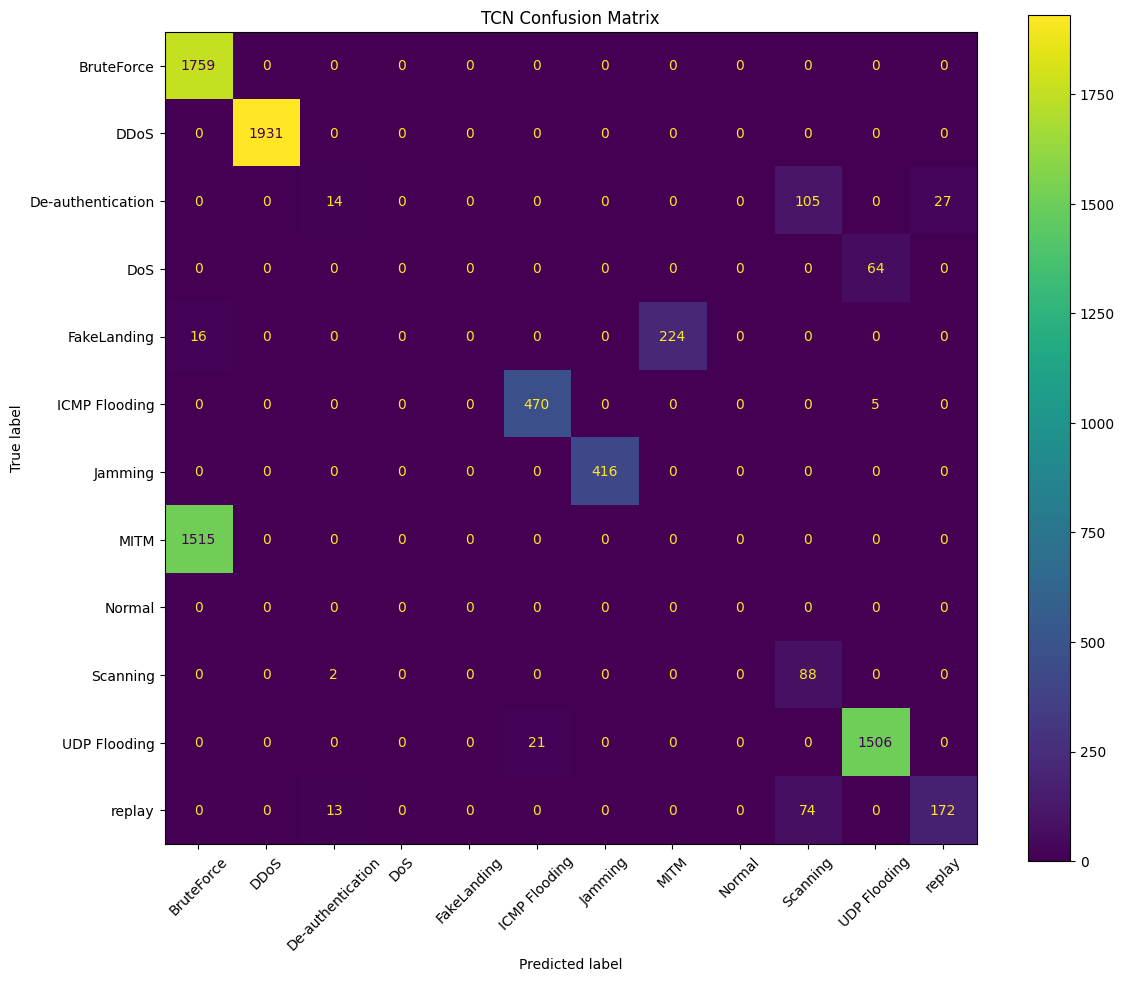

In [185]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test_tcn,
    tcn_test_pred,
    labels=np.arange(len(label_encoder.classes_))
)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title("TCN Confusion Matrix")
plt.tight_layout()
plt.show()

In [186]:
MODELS_DIR = "/content/drive/MyDrive/UAV_NIDD_Project/models"
RESULTS_DIR = "/content/drive/MyDrive/UAV_NIDD_Project/results"

tcn_model.save(
    os.path.join(MODELS_DIR, "tcn_temporal_final.keras")
)

joblib.dump(
    scaler_tcn_final,
    os.path.join(MODELS_DIR, "tcn_temporal_scaler.pkl")
)

['/content/drive/MyDrive/UAV_NIDD_Project/models/tcn_temporal_scaler.pkl']

In [188]:
tcn_results = pd.DataFrame({
    "true_label": label_encoder.inverse_transform(y_test_tcn),
    "predicted_label": label_encoder.inverse_transform(tcn_test_pred)
})

tcn_results.to_csv(
    os.path.join(RESULTS_DIR, "tcn_test_predictions.csv"),
    index=False
)

In [189]:
import tensorflow as tf
from tensorflow.keras import layers, Model

tf.random.set_seed(42)
np.random.seed(42)

SEQUENCE_LENGTH = X_train_scaled.shape[1]
NUM_FEATURES = X_train_scaled.shape[2]
NUM_CLASSES = len(label_encoder.classes_)

inputs = layers.Input(
    shape=(SEQUENCE_LENGTH, NUM_FEATURES),
    name="traffic_sequence"
)

# ---------------------------------------------------------
# Encoder
# ---------------------------------------------------------

x = layers.Conv1D(
    filters=64,
    kernel_size=3,
    padding="same",
    activation="relu"
)(inputs)

x = layers.Conv1D(
    filters=64,
    kernel_size=3,
    padding="same",
    activation="relu"
)(x)

# ---------------------------------------------------------
# Self-attention
# ---------------------------------------------------------

attention_output = layers.MultiHeadAttention(
    num_heads=4,
    key_dim=16,
    dropout=0.1,
    name="self_attention"
)(
    x,
    x
)

x = layers.Add()([x, attention_output])

x = layers.LayerNormalization()(x)

# ---------------------------------------------------------
# Feed-forward representation
# ---------------------------------------------------------

x = layers.Dense(
    64,
    activation="relu"
)(x)

latent = layers.GlobalAveragePooling1D(
    name="latent_representation"
)(x)

latent = layers.Dense(
    64,
    activation="relu",
    name="latent_dense"
)(latent)

# ---------------------------------------------------------
# Classification branch
# ---------------------------------------------------------

classification_output = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="classification"
)(latent)

# ---------------------------------------------------------
# Reconstruction branch
# ---------------------------------------------------------

decoder = layers.Dense(
    SEQUENCE_LENGTH * 64,
    activation="relu"
)(latent)

decoder = layers.Reshape(
    (SEQUENCE_LENGTH, 64)
)(decoder)

decoder = layers.Conv1D(
    filters=64,
    kernel_size=3,
    padding="same",
    activation="relu"
)(decoder)

reconstruction_output = layers.Conv1D(
    filters=NUM_FEATURES,
    kernel_size=3,
    padding="same",
    activation="linear",
    name="reconstruction"
)(decoder)

# ---------------------------------------------------------
# Complete model
# ---------------------------------------------------------

ae_attention_model = Model(
    inputs=inputs,
    outputs=[
        classification_output,
        reconstruction_output
    ]
)

ae_attention_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss={
        "classification": "sparse_categorical_crossentropy",
        "reconstruction": "mse"
    },
    loss_weights={
        "classification": 1.0,
        "reconstruction": 0.1
    },
    metrics={
        "classification": ["accuracy"]
    }
)

ae_attention_model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ traffic_sequence    │ (None, 20, 22)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 20, 64)    │      4,288 │ traffic_sequence… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_25 (Conv1D)  │ (None, 20, 64)    │     12,352 │ conv1d_24[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 20, 64)    │     16,640 │ conv1d_25[0][0],  │
│ (MultiHeadAttentio… │                   │            │ conv1d_25[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 64)    │          0 │ conv1d_25[0][0],  │
│                     │                   │            │ self_attention[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 20, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 20, 64)    │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_representat… │ (None, 64)        │          0 │ dense_16[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_dense        │ (None, 64)        │      4,160 │ latent_represent… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 1280)      │     83,200 │ latent_dense[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 20, 64)    │          0 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_26 (Conv1D)  │ (None, 20, 64)    │     12,352 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification      │ (None, 12)        │        780 │ latent_dense[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reconstruction      │ (None, 20, 22)    │      4,246 │ conv1d_26[0][0]   │
│ (Conv1D)            │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 142,306 (555.88 KB)

 Trainable params: 142,306 (555.88 KB)

 Non-trainable params: 0 (0.00 B)

In [191]:
ae_y_train = {
    "classification": y_train_tcn,
    "reconstruction": X_train_scaled
}

ae_y_val = {
    "classification": y_val_tcn,
    "reconstruction": X_val_scaled
}

ae_y_test = {
    "classification": y_test_tcn,
    "reconstruction": X_test_scaled
}

In [192]:
from tensorflow.keras.callbacks import EarlyStopping

ae_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [194]:
start_time = time.time()

ae_history = ae_attention_model.fit(
    X_train_scaled,
    ae_y_train,

    validation_data=(
        X_val_scaled,
        ae_y_val
    ),

    epochs=30,
    batch_size=256,

    callbacks=[
        ae_early_stopping
    ],

    verbose=1
)

ae_train_time = time.time() - start_time

print(
    f"\nAutoencoder + Attention training time: "
    f"{ae_train_time:.2f} seconds"
)

Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 15s 124ms/step - classification_accuracy: 0.8839 - classification_loss: 0.2559 - loss: 0.2882 - reconstruction_loss: 0.3211 - val_classification_accuracy: 0.7659 - val_classification_loss: 0.5801 - val_loss: 0.6444 - val_reconstruction_loss: 0.4308
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - classification_accuracy: 0.8905 - classification_loss: 0.2395 - loss: 0.2696 - reconstruction_loss: 0.2997 - val_classification_accuracy: 0.7643 - val_classification_loss: 0.6695 - val_loss: 0.7366 - val_reconstruction_loss: 0.4275
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 21s 121ms/step - classification_accuracy: 0.8918 - classification_loss: 0.2333 - loss: 0.2629 - reconstruction_loss: 0.2948 - val_classification_accuracy: 0.7652 - val_classification_loss: 0.6941 - val_loss: 0.7613 - val_reconstruction_loss: 0.4210
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - classification_accuracy: 0.8930 - classification_loss: 0.2297 - loss: 0.2590

In [195]:
# ---------------------------------------------------------
# Autoencoder + Attention test prediction
# ---------------------------------------------------------

start_time = time.time()

ae_test_outputs = ae_attention_model.predict(
    X_test_scaled,
    batch_size=256,
    verbose=1
)

ae_inference_time = time.time() - start_time

# First output = classification probabilities
ae_test_proba = ae_test_outputs[0]

# Second output = reconstructed sequences
ae_test_reconstruction = ae_test_outputs[1]

ae_test_pred = np.argmax(
    ae_test_proba,
    axis=1
)

print(
    f"Test inference time: "
    f"{ae_inference_time:.2f} seconds"
)

print(
    f"Time per sequence: "
    f"{ae_inference_time / len(X_test_scaled) * 1000:.4f} ms"
)

print(
    "Classification probability shape:",
    ae_test_proba.shape
)

print(
    "Reconstruction shape:",
    ae_test_reconstruction.shape
)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
Test inference time: 1.51 seconds
Time per sequence: 0.1792 ms
Classification probability shape: (8422, 12)
Reconstruction shape: (8422, 20, 22)


In [196]:
ae_accuracy = accuracy_score(
    y_test_tcn,
    ae_test_pred
)

ae_macro_precision = precision_score(
    y_test_tcn,
    ae_test_pred,
    average="macro",
    zero_division=0
)

ae_macro_recall = recall_score(
    y_test_tcn,
    ae_test_pred,
    average="macro",
    zero_division=0
)

ae_macro_f1 = f1_score(
    y_test_tcn,
    ae_test_pred,
    average="macro",
    zero_division=0
)

ae_weighted_f1 = f1_score(
    y_test_tcn,
    ae_test_pred,
    average="weighted",
    zero_division=0
)

print(f"Accuracy:       {ae_accuracy:.4f}")
print(f"Macro Precision: {ae_macro_precision:.4f}")
print(f"Macro Recall:    {ae_macro_recall:.4f}")
print(f"Macro F1:        {ae_macro_f1:.4f}")
print(f"Weighted F1:     {ae_weighted_f1:.4f}")

Accuracy:       0.7756
Macro Precision: 0.6704
Macro Recall:    0.6698
Macro F1:        0.6488
Weighted F1:     0.7129


In [197]:
print(
    classification_report(
        y_test_tcn,
        ae_test_pred,
        labels=np.arange(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                   precision    recall  f1-score   support

       BruteForce       0.54      1.00      0.70      1759
             DDoS       1.00      1.00      1.00      1931
De-authentication       0.58      0.97      0.73       146
              DoS       0.94      0.47      0.62        64
      FakeLanding       0.00      0.00      0.00       240
    ICMP Flooding       1.00      1.00      1.00       475
          Jamming       1.00      1.00      1.00       416
             MITM       0.04      0.01      0.01      1515
           Normal       0.00      0.00      0.00         0
         Scanning       1.00      0.99      0.99        90
     UDP Flooding       0.98      1.00      0.99      1527
           replay       0.97      0.60      0.74       259

         accuracy                           0.78      8422
        macro avg       0.67      0.67      0.65      8422
     weighted avg       0.69      0.78      0.71      8422



In [198]:
reconstruction_error = np.mean(
    np.square(
        X_test_scaled - ae_test_reconstruction
    ),
    axis=(1, 2)
)

print(
    "Mean reconstruction error:",
    reconstruction_error.mean()
)

print(
    "Median reconstruction error:",
    np.median(reconstruction_error)
)

print(
    "Maximum reconstruction error:",
    reconstruction_error.max()
)

Mean reconstruction error: 0.21147853
Median reconstruction error: 0.028618684
Maximum reconstruction error: 8.560051


In [200]:
ae_attention_model.save(
    os.path.join(
        MODELS_DIR,
        "autoencoder_attention_final.keras"
    )
)

pd.DataFrame({
    "true_label": label_encoder.inverse_transform(y_test_tcn),
    "predicted_label": label_encoder.inverse_transform(ae_test_pred)
}).to_csv(
    os.path.join(
        RESULTS_DIR,
        "autoencoder_attention_test_predictions.csv"
    ),
    index=False
)

print("Autoencoder + Attention artifacts saved.")

Autoencoder + Attention artifacts saved.


In [202]:
# ---------------------------------------------------------
# Prepare XGBoost data using the same clean temporal split
# ---------------------------------------------------------

X_train_xgb = train_temporal_clean[selected_features].apply(
    pd.to_numeric,
    errors="coerce"
)

y_train_xgb = label_encoder.transform(
    train_temporal_clean["Label"]
)

X_val_xgb = val_temporal_clean[selected_features].apply(
    pd.to_numeric,
    errors="coerce"
)

y_val_xgb = label_encoder.transform(
    val_temporal_clean["Label"]
)

print("XGBoost train:", X_train_xgb.shape)
print("XGBoost validation:", X_val_xgb.shape)

XGBoost train: (602447, 22)
XGBoost validation: (84271, 22)


In [203]:
# ---------------------------------------------------------
# Get the final packet of every test sequence
# ---------------------------------------------------------

X_test_xgb_parts = []
y_test_xgb_parts = []

for block in test_clean_parts:

    block_features = block[selected_features].apply(
        pd.to_numeric,
        errors="coerce"
    )

    block_labels = label_encoder.transform(
        block["Label"]
    )

    for start in range(
        0,
        len(block) - SEQUENCE_LENGTH + 1,
        STRIDE
    ):
        end = start + SEQUENCE_LENGTH

        # Final packet of the 20-packet sequence
        X_test_xgb_parts.append(
            block_features.iloc[end - 1].to_numpy()
        )

        y_test_xgb_parts.append(
            block_labels[end - 1]
        )

X_test_xgb = np.asarray(
    X_test_xgb_parts,
    dtype=np.float32
)

y_test_xgb = np.asarray(
    y_test_xgb_parts,
    dtype=np.int64
)

print("XGBoost test:", X_test_xgb.shape)
print("XGBoost test labels:", y_test_xgb.shape)

XGBoost test: (8422, 22)
XGBoost test labels: (8422,)


In [204]:
print(
    "Labels identical to TCN test:",
    np.array_equal(y_test_xgb, y_test_tcn)
)

Labels identical to TCN test: True


In [206]:
import xgboost as xgb
import time

xgb_temporal_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=NUM_CLASSES,

    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,

    subsample=0.8,
    colsample_bytree=0.8,

    tree_method="hist",

    eval_metric="mlogloss",

    random_state=42,
    n_jobs=-1,

    early_stopping_rounds=20
)

In [207]:
start_time = time.time()

xgb_temporal_model.fit(
    X_train_xgb,
    y_train_xgb,

    eval_set=[
        (X_val_xgb, y_val_xgb)
    ],

    verbose=50
)

xgb_temporal_train_time = time.time() - start_time

print(
    f"\nTemporal XGBoost training time: "
    f"{xgb_temporal_train_time:.2f} seconds"
)

print(
    "Best iteration:",
    xgb_temporal_model.best_iteration
)

[0]	validation_0-mlogloss:1.63580
[36]	validation_0-mlogloss:1.11097

Temporal XGBoost training time: 29.83 seconds
Best iteration: 16


In [209]:
# ---------------------------------------------------------
# Evaluate temporal XGBoost on the SAME 8,422 test samples
# ---------------------------------------------------------

start_time = time.time()

xgb_temporal_proba = xgb_temporal_model.predict_proba(
    X_test_xgb
)

xgb_temporal_inference_time = time.time() - start_time

xgb_temporal_pred = np.argmax(
    xgb_temporal_proba,
    axis=1
)

print(
    f"Test inference time: "
    f"{xgb_temporal_inference_time:.2f} seconds"
)

print(
    f"Time per sequence: "
    f"{xgb_temporal_inference_time / len(X_test_xgb) * 1000:.4f} ms"
)

print(
    "Probability shape:",
    xgb_temporal_proba.shape
)

Test inference time: 0.03 seconds
Time per sequence: 0.0040 ms
Probability shape: (8422, 12)


In [210]:
xgb_temporal_accuracy = accuracy_score(
    y_test_xgb,
    xgb_temporal_pred
)

xgb_temporal_macro_precision = precision_score(
    y_test_xgb,
    xgb_temporal_pred,
    average="macro",
    zero_division=0
)

xgb_temporal_macro_recall = recall_score(
    y_test_xgb,
    xgb_temporal_pred,
    average="macro",
    zero_division=0
)

xgb_temporal_macro_f1 = f1_score(
    y_test_xgb,
    xgb_temporal_pred,
    average="macro",
    zero_division=0
)

xgb_temporal_weighted_f1 = f1_score(
    y_test_xgb,
    xgb_temporal_pred,
    average="weighted",
    zero_division=0
)

print(f"Accuracy:       {xgb_temporal_accuracy:.4f}")
print(f"Macro Precision: {xgb_temporal_macro_precision:.4f}")
print(f"Macro Recall:    {xgb_temporal_macro_recall:.4f}")
print(f"Macro F1:        {xgb_temporal_macro_f1:.4f}")
print(f"Weighted F1:     {xgb_temporal_weighted_f1:.4f}")

Accuracy:       0.5809
Macro Precision: 0.7088
Macro Recall:    0.6383
Macro F1:        0.6045
Weighted F1:     0.5090


In [211]:
print(
    classification_report(
        y_test_xgb,
        xgb_temporal_pred,
        labels=np.arange(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                   precision    recall  f1-score   support

       BruteForce       0.36      1.00      0.53      1759
             DDoS       0.98      0.19      0.32      1931
De-authentication       1.00      0.13      0.23       146
              DoS       1.00      1.00      1.00        64
      FakeLanding       0.00      0.00      0.00       240
    ICMP Flooding       0.86      1.00      0.93       475
          Jamming       1.00      1.00      1.00       416
             MITM       0.00      0.00      0.00      1515
           Normal       0.00      0.00      0.00         0
         Scanning       1.00      1.00      1.00        90
     UDP Flooding       1.00      0.99      1.00      1527
           replay       0.59      0.71      0.64       259

         accuracy                           0.58      8422
        macro avg       0.65      0.59      0.55      8422
     weighted avg       0.63      0.58      0.51      8422



In [212]:
np.save(
    os.path.join(
        RESULTS_DIR,
        "xgb_temporal_test_probabilities.npy"
    ),
    xgb_temporal_proba
)

np.save(
    os.path.join(
        RESULTS_DIR,
        "tcn_test_probabilities.npy"
    ),
    tcn_test_proba
)

np.save(
    os.path.join(
        RESULTS_DIR,
        "ae_attention_test_probabilities.npy"
    ),
    ae_test_proba
)

print("All three probability matrices saved.")

All three probability matrices saved.


In [213]:
joblib.dump(
    xgb_temporal_model,
    os.path.join(
        MODELS_DIR,
        "xgboost_temporal_mi_final.pkl"
    )
)

print("Temporal XGBoost saved.")

Temporal XGBoost saved.


In [214]:
# ---------------------------------------------------------
# Equal-weight probability fusion
# ---------------------------------------------------------

equal_fused_proba = (
    xgb_temporal_proba
    + tcn_test_proba
    + ae_test_proba
) / 3.0

equal_fused_pred = np.argmax(
    equal_fused_proba,
    axis=1
)

print(
    "Equal-fusion probability shape:",
    equal_fused_proba.shape
)

Equal-fusion probability shape: (8422, 12)


In [216]:
equal_accuracy = accuracy_score(
    y_test_tcn,
    equal_fused_pred
)

equal_macro_precision = precision_score(
    y_test_tcn,
    equal_fused_pred,
    average="macro",
    zero_division=0
)

equal_macro_recall = recall_score(
    y_test_tcn,
    equal_fused_pred,
    average="macro",
    zero_division=0
)

equal_macro_f1 = f1_score(
    y_test_tcn,
    equal_fused_pred,
    average="macro",
    zero_division=0
)

equal_weighted_f1 = f1_score(
    y_test_tcn,
    equal_fused_pred,
    average="weighted",
    zero_division=0
)

print(f"Accuracy:       {equal_accuracy:.4f}")
print(f"Macro Precision: {equal_macro_precision:.4f}")
print(f"Macro Recall:    {equal_macro_recall:.4f}")
print(f"Macro F1:        {equal_macro_f1:.4f}")
print(f"Weighted F1:     {equal_weighted_f1:.4f}")

Accuracy:       0.7685
Macro Precision: 0.6811
Macro Recall:    0.6807
Macro F1:        0.6608
Weighted F1:     0.7018


In [218]:
print(
    classification_report(
        y_test_tcn,
        equal_fused_pred,
        labels=np.arange(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                   precision    recall  f1-score   support

       BruteForce       0.54      1.00      0.70      1759
             DDoS       1.00      1.00      1.00      1931
De-authentication       0.34      0.12      0.18       146
              DoS       1.00      0.50      0.67        64
      FakeLanding       0.00      0.00      0.00       240
    ICMP Flooding       1.00      1.00      1.00       475
          Jamming       1.00      1.00      1.00       416
             MITM       0.00      0.00      0.00      1515
           Normal       0.00      0.00      0.00         0
         Scanning       1.00      1.00      1.00        90
     UDP Flooding       0.98      1.00      0.99      1527
           replay       0.64      0.86      0.73       259

         accuracy                           0.77      8422
        macro avg       0.62      0.62      0.61      8422
     weighted avg       0.67      0.77      0.70      8422



In [220]:
xgb_confidence = np.max(
    xgb_temporal_proba,
    axis=1
)

tcn_confidence = np.max(
    tcn_test_proba,
    axis=1
)

ae_confidence = np.max(
    ae_test_proba,
    axis=1
)

print("Mean confidence:")
print(
    "XGBoost:",
    xgb_confidence.mean()
)

print(
    "TCN:",
    tcn_confidence.mean()
)

print(
    "AE+Attention:",
    ae_confidence.mean()
)

print("\nMedian confidence:")
print(
    "XGBoost:",
    np.median(xgb_confidence)
)

print(
    "TCN:",
    np.median(tcn_confidence)
)

print(
    "AE+Attention:",
    np.median(ae_confidence)
)

Mean confidence:
XGBoost: 0.6944275
TCN: 0.9257005
AE+Attention: 0.96771264

Median confidence:
XGBoost: 0.732072
TCN: 0.98763704
AE+Attention: 0.9986753


In [222]:
tcn_val_proba = tcn_model.predict(
    X_val_scaled,
    verbose=0
)

print("TCN validation probability shape:", tcn_val_proba.shape)

TCN validation probability shape: (4208, 12)


In [227]:
# Show variables whose names look related to the Autoencoder/Attention model
[name for name in globals() if any(
    word in name.lower()
    for word in ["ae", "autoencoder", "attention"]
)]

['attention_output',
 'ae_attention_model',
 'ae_y_train',
 'ae_y_val',
 'ae_y_test',
 'ae_early_stopping',
 'ae_history',
 'ae_train_time',
 'ae_test_outputs',
 'ae_inference_time',
 'ae_test_proba',
 'ae_test_reconstruction',
 'ae_test_pred',
 'ae_accuracy',
 'ae_macro_precision',
 'ae_macro_recall',
 'ae_macro_f1',
 'ae_weighted_f1',
 'ae_confidence']

In [229]:
ae_val_outputs = ae_attention_model.predict(
    X_val_scaled,
    verbose=0
)

ae_val_proba = ae_val_outputs[0]

print("AE validation probability shape:", ae_val_proba.shape)

AE validation probability shape: (4208, 12)


In [231]:
X_val_xgb_seq = []

for part in val_clean_parts:
    n_seq = len(part) // 20
    if n_seq > 0:
        seq_part = part.iloc[:n_seq * 20]
        endpoint_rows = seq_part.iloc[19::20]
        X_val_xgb_seq.append(endpoint_rows)

X_val_xgb_seq = pd.concat(X_val_xgb_seq, axis=0)

X_val_xgb_seq = X_val_xgb_seq[selected_features].apply(
    pd.to_numeric,
    errors="coerce"
)

print("XGBoost validation endpoint shape:", X_val_xgb_seq.shape)

XGBoost validation endpoint shape: (4208, 22)


In [232]:
xgb_val_proba = xgb_temporal_model.predict_proba(
    X_val_xgb_seq
)

print("XGBoost validation probability shape:", xgb_val_proba.shape)

XGBoost validation probability shape: (4208, 12)


In [234]:
print("XGB:", xgb_val_proba.shape)
print("TCN:", tcn_val_proba.shape)
print("AE :", ae_val_proba.shape)
print("Validation labels:", len(y_val_tcn))

XGB: (4208, 12)
TCN: (4208, 12)
AE : (4208, 12)
Validation labels: 4208


In [236]:
import numpy as np

xgb_val_conf = np.max(xgb_val_proba, axis=1)
tcn_val_conf = np.max(tcn_val_proba, axis=1)
ae_val_conf = np.max(ae_val_proba, axis=1)

print("Mean validation confidence:")
print("XGBoost:", xgb_val_conf.mean())
print("TCN:", tcn_val_conf.mean())
print("AE+Attention:", ae_val_conf.mean())

Mean validation confidence:
XGBoost: 0.6974638
TCN: 0.8896067
AE+Attention: 0.94694376


In [237]:
confidence_sum = (
    xgb_val_conf +
    tcn_val_conf +
    ae_val_conf
)

xgb_val_weight = xgb_val_conf / confidence_sum
tcn_val_weight = tcn_val_conf / confidence_sum
ae_val_weight = ae_val_conf / confidence_sum

print("Average weights:")
print("XGBoost:", xgb_val_weight.mean())
print("TCN:", tcn_val_weight.mean())
print("AE+Attention:", ae_val_weight.mean())

Average weights:
XGBoost: 0.2773717
TCN: 0.34917438
AE+Attention: 0.37345392


In [239]:
confidence_fused_val_proba = (
    xgb_val_weight[:, None] * xgb_val_proba +
    tcn_val_weight[:, None] * tcn_val_proba +
    ae_val_weight[:, None] * ae_val_proba
)

confidence_fused_val_pred = np.argmax(
    confidence_fused_val_proba,
    axis=1
)

print(
    "Confidence-aware probability shape:",
    confidence_fused_val_proba.shape
)

Confidence-aware probability shape: (4208, 12)


In [242]:
print(
    classification_report(
        y_val_tcn,
        confidence_fused_val_pred,
        labels=np.arange(12),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                   precision    recall  f1-score   support

       BruteForce       0.54      1.00      0.70       879
             DDoS       1.00      1.00      1.00       965
De-authentication       1.00      0.08      0.15        73
              DoS       1.00      0.66      0.79        32
      FakeLanding       0.00      0.00      0.00       120
    ICMP Flooding       0.98      1.00      0.99       237
          Jamming       1.00      1.00      1.00       208
             MITM       0.14      0.03      0.04       757
           Normal       0.00      0.00      0.00         0
         Scanning       1.00      1.00      1.00        45
     UDP Flooding       0.99      0.99      0.99       763
           replay       0.66      1.00      0.79       129

         accuracy                           0.78      4208
        macro avg       0.69      0.65      0.62      4208
     weighted avg       0.71      0.78      0.71      4208



In [244]:
# Equal-weight fusion on validation set

equal_fused_val_proba = (
    xgb_val_proba +
    tcn_val_proba +
    ae_val_proba
) / 3.0

equal_fused_val_pred = np.argmax(
    equal_fused_val_proba,
    axis=1
)

print("Equal-fusion validation probability shape:",
      equal_fused_val_proba.shape)

print("Accuracy:",
      accuracy_score(y_val_tcn, equal_fused_val_pred))

print("Macro Precision:",
      precision_score(
          y_val_tcn,
          equal_fused_val_pred,
          average="macro",
          zero_division=0
      ))

print("Macro Recall:",
      recall_score(
          y_val_tcn,
          equal_fused_val_pred,
          average="macro",
          zero_division=0
      ))

print("Macro F1:",
      f1_score(
          y_val_tcn,
          equal_fused_val_pred,
          average="macro",
          zero_division=0
      ))

print("Weighted F1:",
      f1_score(
          y_val_tcn,
          equal_fused_val_pred,
          average="weighted",
          zero_division=0
      ))

Equal-fusion validation probability shape: (4208, 12)
Accuracy: 0.7759030418250951
Macro Precision: 0.7548333280779466
Macro Recall: 0.6967761821988716
Macro F1: 0.6719958015236163
Weighted F1: 0.7113282789213955


In [246]:
# Frozen confidence-aware fusion applied to untouched test set

xgb_test_conf = np.max(xgb_temporal_proba, axis=1)
tcn_test_conf = np.max(tcn_test_proba, axis=1)
ae_test_conf = np.max(ae_test_proba, axis=1)

test_confidence_sum = (
    xgb_test_conf +
    tcn_test_conf +
    ae_test_conf
)

xgb_test_weight = xgb_test_conf / test_confidence_sum
tcn_test_weight = tcn_test_conf / test_confidence_sum
ae_test_weight = ae_test_conf / test_confidence_sum

confidence_fused_test_proba = (
    xgb_test_weight[:, None] * xgb_temporal_proba +
    tcn_test_weight[:, None] * tcn_test_proba +
    ae_test_weight[:, None] * ae_test_proba
)

confidence_fused_test_pred = np.argmax(
    confidence_fused_test_proba,
    axis=1
)

print(
    "Confidence-aware test probability shape:",
    confidence_fused_test_proba.shape
)

Confidence-aware test probability shape: (8422, 12)


In [248]:
confidence_test_accuracy = accuracy_score(
    y_test_tcn,
    confidence_fused_test_pred
)

confidence_test_macro_precision = precision_score(
    y_test_tcn,
    confidence_fused_test_pred,
    average="macro",
    zero_division=0
)

confidence_test_macro_recall = recall_score(
    y_test_tcn,
    confidence_fused_test_pred,
    average="macro",
    zero_division=0
)

confidence_test_macro_f1 = f1_score(
    y_test_tcn,
    confidence_fused_test_pred,
    average="macro",
    zero_division=0
)

confidence_test_weighted_f1 = f1_score(
    y_test_tcn,
    confidence_fused_test_pred,
    average="weighted",
    zero_division=0
)

print(f"Accuracy:       {confidence_test_accuracy:.4f}")
print(f"Macro Precision: {confidence_test_macro_precision:.4f}")
print(f"Macro Recall:    {confidence_test_macro_recall:.4f}")
print(f"Macro F1:        {confidence_test_macro_f1:.4f}")
print(f"Weighted F1:     {confidence_test_weighted_f1:.4f}")

Accuracy:       0.7686
Macro Precision: 0.6775
Macro Recall:    0.6843
Macro F1:        0.6630
Weighted F1:     0.7021


In [250]:
print(
    classification_report(
        y_test_tcn,
        confidence_fused_test_pred,
        labels=np.arange(12),
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                   precision    recall  f1-score   support

       BruteForce       0.54      1.00      0.70      1759
             DDoS       1.00      1.00      1.00      1931
De-authentication       0.33      0.12      0.17       146
              DoS       0.97      0.55      0.70        64
      FakeLanding       0.00      0.00      0.00       240
    ICMP Flooding       1.00      1.00      1.00       475
          Jamming       1.00      1.00      1.00       416
             MITM       0.00      0.00      0.00      1515
           Normal       0.00      0.00      0.00         0
         Scanning       1.00      1.00      1.00        90
     UDP Flooding       0.98      1.00      0.99      1527
           replay       0.63      0.86      0.73       259

         accuracy                           0.77      8422
        macro avg       0.62      0.63      0.61      8422
     weighted avg       0.67      0.77      0.70      8422



In [252]:
final_results = pd.DataFrame({
    "Model": [
        "Temporal XGBoost + MI",
        "TCN",
        "AE + Attention",
        "Equal-weight Fusion",
        "Confidence-aware Fusion"
    ],
    "Accuracy": [
        0.5809,
        0.7547,
        0.7756,
        0.7685,
        confidence_test_accuracy
    ],
    "Macro-F1": [
        0.6045,
        0.5495,
        0.6488,
        0.6608,
        confidence_test_macro_f1
    ],
    "Weighted-F1": [
        0.5090,
        0.6863,
        0.7129,
        0.7018,
        confidence_test_weighted_f1
    ]
})

final_results

,Model,Accuracy,Macro-F1,Weighted-F1
0,Temporal XGBoost + MI,0.580900,0.604500,0.509000
1,TCN,0.754700,0.549500,0.686300
2,AE + Attention,0.775600,0.648800,0.712900
3,Equal-weight Fusion,0.768500,0.660800,0.701800
4,Confidence-aware Fusion,0.768582,0.662987,0.702075


In [254]:
final_results.to_csv(
    "/content/drive/MyDrive/UAV_NIDD_Project/results/final_model_comparison.csv",
    index=False
)

print("Saved final_model_comparison.csv")

Saved final_model_comparison.csv


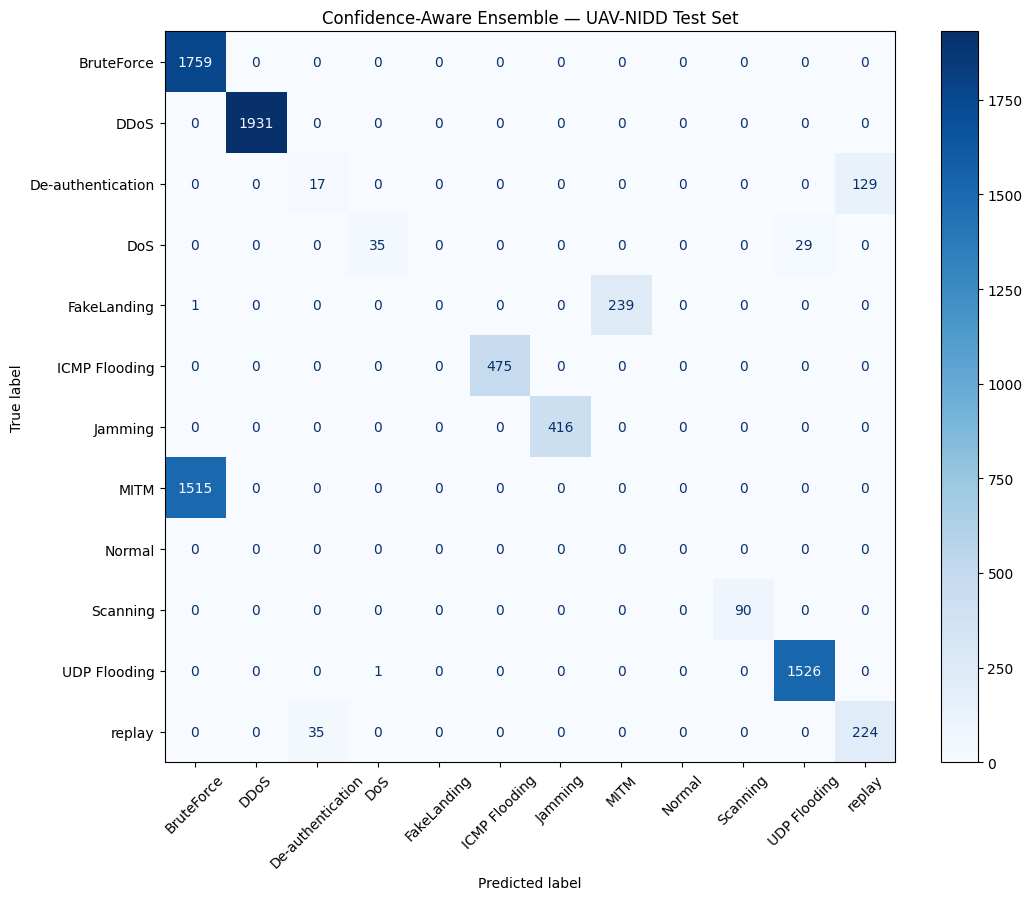

In [256]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 9))

ConfusionMatrixDisplay.from_predictions(
    y_test_tcn,
    confidence_fused_test_pred,
    labels=np.arange(12),
    display_labels=label_encoder.classes_,
    xticks_rotation=45,
    cmap="Blues",
    ax=ax
)

ax.set_title("Confidence-Aware Ensemble — UAV-NIDD Test Set")
plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/UAV_NIDD_Project/figures/confidence_aware_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [258]:
normal_df = df_model[df_model["Label"] == "Normal"].copy()

normal_feature_groups = (
    normal_df[feature_cols_all]
    .astype(str)
    .agg("|".join, axis=1)
    .factorize()[0]
)

print("Normal rows:", len(normal_df))
print("Unique Normal feature groups:",
      len(np.unique(normal_feature_groups)))
print("Repeated Normal rows:",
      len(normal_df) - len(np.unique(normal_feature_groups)))

Normal rows: 17949
Unique Normal feature groups: 6358
Repeated Normal rows: 11591


In [260]:
normal_group_df = pd.DataFrame({
    "group_id": normal_feature_groups
})

normal_group_counts = normal_group_df["group_id"].value_counts()

print("Unique Normal groups:", len(normal_group_counts))
print("\nGroup-size distribution:")
print(normal_group_counts.describe())

print("\nLargest Normal groups:")
print(normal_group_counts.head(20))

Unique Normal groups: 6358

Group-size distribution:
count    6358.000000
mean        2.823058
std         0.680516
min         2.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         4.000000
Name: count, dtype: float64

Largest Normal groups:
group_id
663    4
664    4
665    4
666    4
667    4
668    4
669    4
670    4
671    4
672    4
673    4
674    4
675    4
676    4
504    4
678    4
679    4
680    4
681    4
682    4
Name: count, dtype: int64


In [262]:
normal_indices = df_model.index[
    df_model["Label"] == "Normal"
]

print("Normal first index:", normal_indices.min())
print("Normal last index:", normal_indices.max())

print(
    "Normal rows contiguous:",
    normal_indices.is_monotonic_increasing
    and (normal_indices.to_numpy() ==
         np.arange(normal_indices.min(), normal_indices.max() + 1)).all()
)

Normal first index: 0
Normal last index: 17948
Normal rows contiguous: True


In [264]:
# ============================================================
# EXPERIMENT 2 — GROUP-AWARE NORMAL + TEMPORAL ATTACK SPLIT
# ============================================================

import numpy as np
import pandas as pd

# Work from df_model
df_exp2 = df_model.copy()

# ------------------------------------------------------------
# 1. Identify the Normal block
# ------------------------------------------------------------

normal_df = df_exp2[df_exp2["Label"] == "Normal"].copy()
attack_df = df_exp2[df_exp2["Label"] != "Normal"].copy()

print("Normal rows:", len(normal_df))
print("Attack rows:", len(attack_df))


# ------------------------------------------------------------
# 2. Create feature groups for Normal samples
#    Identical feature patterns stay in the same split
# ------------------------------------------------------------

normal_group_ids = (
    normal_df[feature_cols_all]
    .astype(str)
    .agg("|".join, axis=1)
    .factorize()[0]
)

normal_df = normal_df.copy()
normal_df["normal_group"] = normal_group_ids

unique_groups = normal_df["normal_group"].unique()

rng = np.random.RandomState(42)
rng.shuffle(unique_groups)

n_groups = len(unique_groups)

n_train = int(0.70 * n_groups)
n_val = int(0.10 * n_groups)

train_groups = set(unique_groups[:n_train])
val_groups = set(unique_groups[n_train:n_train + n_val])
test_groups = set(unique_groups[n_train + n_val:])


normal_train = normal_df[
    normal_df["normal_group"].isin(train_groups)
].copy()

normal_val = normal_df[
    normal_df["normal_group"].isin(val_groups)
].copy()

normal_test = normal_df[
    normal_df["normal_group"].isin(test_groups)
].copy()


# Remove helper column
normal_train = normal_train.drop(columns=["normal_group"])
normal_val = normal_val.drop(columns=["normal_group"])
normal_test = normal_test.drop(columns=["normal_group"])


# ------------------------------------------------------------
# 3. Split every attack block chronologically
#    70% train / 10% validation / 20% test
# ------------------------------------------------------------

attack_parts_train = []
attack_parts_val = []
attack_parts_test = []

labels_in_order = attack_df["Label"].tolist()

# Find contiguous label blocks
block_start = 0

for i in range(1, len(attack_df)):
    if labels_in_order[i] != labels_in_order[i - 1]:

        block = attack_df.iloc[block_start:i]

        n = len(block)
        train_end = int(0.70 * n)
        val_end = int(0.80 * n)

        attack_parts_train.append(block.iloc[:train_end])
        attack_parts_val.append(block.iloc[train_end:val_end])
        attack_parts_test.append(block.iloc[val_end:])

        block_start = i

# Add final block
block = attack_df.iloc[block_start:]

n = len(block)
train_end = int(0.70 * n)
val_end = int(0.80 * n)

attack_parts_train.append(block.iloc[:train_end])
attack_parts_val.append(block.iloc[train_end:val_end])
attack_parts_test.append(block.iloc[val_end:])


# Combine attack partitions
attack_train = pd.concat(attack_parts_train, axis=0)
attack_val = pd.concat(attack_parts_val, axis=0)
attack_test = pd.concat(attack_parts_test, axis=0)


# ------------------------------------------------------------
# 4. Combine Normal + attack partitions
# ------------------------------------------------------------

train_exp2 = pd.concat(
    [normal_train, attack_train],
    axis=0
).sort_index()

val_exp2 = pd.concat(
    [normal_val, attack_val],
    axis=0
).sort_index()

test_exp2 = pd.concat(
    [normal_test, attack_test],
    axis=0
).sort_index()


# ------------------------------------------------------------
# 5. Check class distributions
# ------------------------------------------------------------

print("\n===== EXPERIMENT 2 SPLIT =====")

print("\nTrain shape:", train_exp2.shape)
print("Validation shape:", val_exp2.shape)
print("Test shape:", test_exp2.shape)

print("\nTrain classes:")
print(train_exp2["Label"].value_counts())

print("\nValidation classes:")
print(val_exp2["Label"].value_counts())

print("\nTest classes:")
print(test_exp2["Label"].value_counts())

Normal rows: 17949
Attack rows: 842697

===== EXPERIMENT 2 SPLIT =====

Train shape: (602432, 46)
Validation shape: (86105, 46)
Test shape: (172109, 46)

Train classes:
Label
DDoS                 135226
BruteForce           123147
UDP Flooding         106942
MITM                 106110
ICMP Flooding         33280
Jamming               29119
replay                18183
FakeLanding           16835
Normal                12549
De-authentication     10224
Scanning               6321
DoS                    4496
Name: count, dtype: int64

Validation classes:
Label
DDoS                 19318
BruteForce           17593
UDP Flooding         15278
MITM                 15158
ICMP Flooding         4755
Jamming               4161
replay                2598
FakeLanding           2405
Normal                1834
De-authentication     1460
Scanning               903
DoS                    642
Name: count, dtype: int64

Test classes:
Label
DDoS                 38636
BruteForce           35185
UDP Floodin

In [266]:
# ============================================================
# EXPERIMENT 2 — DUPLICATE GROUP LEAKAGE CHECK
# ============================================================

def make_group_ids(data):
    return (
        data[feature_cols_all]
        .astype(str)
        .agg("|".join, axis=1)
        .factorize()[0]
    )

train_groups_exp2 = set(
    train_exp2[feature_cols_all]
    .astype(str)
    .agg("|".join, axis=1)
)

val_groups_exp2 = set(
    val_exp2[feature_cols_all]
    .astype(str)
    .agg("|".join, axis=1)
)

test_groups_exp2 = set(
    test_exp2[feature_cols_all]
    .astype(str)
    .agg("|".join, axis=1)
)

print("Train unique feature groups:", len(train_groups_exp2))
print("Validation unique feature groups:", len(val_groups_exp2))
print("Test unique feature groups:", len(test_groups_exp2))

print("\nTrain ∩ Validation:", len(train_groups_exp2 & val_groups_exp2))
print("Train ∩ Test:", len(train_groups_exp2 & test_groups_exp2))
print("Validation ∩ Test:", len(val_groups_exp2 & test_groups_exp2))

Train unique feature groups: 594333
Validation unique feature groups: 84906
Test unique feature groups: 169816

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [268]:
# ============================================================
# EXPERIMENT 2 — NUMERIC FEATURE AUDIT
# ============================================================

candidate_numeric_features = []

for col in feature_cols_all:
    train_numeric = pd.to_numeric(
        train_exp2[col],
        errors="coerce"
    )

    if train_numeric.notna().all():
        candidate_numeric_features.append(col)

print("Total raw features:", len(feature_cols_all))
print("Fully numeric features:", len(candidate_numeric_features))

print("\nFully numeric features:")
for i, col in enumerate(candidate_numeric_features, 1):
    print(f"{i:2d}. {col}")

Total raw features: 44
Fully numeric features: 33

Fully numeric features:
 1. frame.encap_type
 2. frame.len
 3. frame.number
 4. frame.time_delta_displayed
 5. frame.time_epoch
 6. frame.time_relative
 7. radiotap.channel.flags.cck
 8. radiotap.channel.flags.ofdm
 9. radiotap.channel.freq
10. radiotap.datarate
11. radiotap.dbm_antsignal
12. radiotap.length
13. radiotap.mactime
14. radiotap.present.tsft
15. radiotap.rxflags
16. radiotap.vendor_oui
17. wlan.bssid
18. wlan.fc.retry
19. wlan.fc.subtype
20. wlan.fcs.bad_checksum
21. wlan.fixed.beacon
22. wlan.fixed.capabilities.ess
23. wlan_radio.frequency
24. wlan_radio.signal_dbm
25. wlan_radio.start_tsf
26. wlan_radio.phy
27. wlan_radio.timestamp
28. wlan.rsn.capabilities.mfpc
29. wlan_rsna_eapol.keydes.msgnr
30. tcp.ack
31. udp.dstport
32. udp.srcport
33. udp.length


In [270]:
# ============================================================
# EXPERIMENT 2 — EXPANDED FEATURE SET
# ============================================================

additional_features = [
    "frame.encap_type",
    "radiotap.channel.flags.ofdm",
    "radiotap.vendor_oui",
    "wlan.fc.retry",
    "wlan.fc.subtype",
    "wlan.fixed.beacon",
    "tcp.ack"
]

expanded_features = selected_features.copy()

for feature in additional_features:
    if feature not in expanded_features:
        expanded_features.append(feature)

print("MI-selected features:", len(selected_features))
print("Additional features:", len(additional_features))
print("Expanded feature count:", len(expanded_features))

print("\nExpanded feature set:")
for i, feature in enumerate(expanded_features, 1):
    print(f"{i:2d}. {feature}")

MI-selected features: 22
Additional features: 7
Expanded feature count: 29

Expanded feature set:
 1. radiotap.channel.flags.cck
 2. frame.len
 3. frame.time_delta_displayed
 4. udp.dstport
 5. wlan.rsn.capabilities.mfpc
 6. radiotap.rxflags
 7. wlan_radio.timestamp
 8. radiotap.mactime
 9. wlan_radio.start_tsf
10. wlan.fcs.bad_checksum
11. radiotap.dbm_antsignal
12. wlan_radio.signal_dbm
13. radiotap.present.tsft
14. radiotap.datarate
15. wlan_radio.phy
16. radiotap.length
17. wlan.fixed.capabilities.ess
18. wlan_rsna_eapol.keydes.msgnr
19. radiotap.channel.freq
20. udp.srcport
21. udp.length
22. wlan.bssid
23. frame.encap_type
24. radiotap.channel.flags.ofdm
25. radiotap.vendor_oui
26. wlan.fc.retry
27. wlan.fc.subtype
28. wlan.fixed.beacon
29. tcp.ack


In [272]:
# ============================================================
# EXPERIMENT 2 — TEMPORAL SEQUENCE CREATION
# ============================================================

WINDOW_SIZE = 20
STRIDE = 5

def create_sequences_by_block(df, feature_columns, window_size=20, stride=5):
    """
    Create temporal windows without crossing label boundaries.

    Each window receives the label of the first/only label in
    the block. Windows are created independently for each
    contiguous label block.
    """

    X_sequences = []
    y_sequences = []

    labels = df["Label"].to_numpy()

    # Find contiguous label blocks
    block_starts = [0]

    for i in range(1, len(labels)):
        if labels[i] != labels[i - 1]:
            block_starts.append(i)

    block_starts.append(len(df))

    for start, end in zip(block_starts[:-1], block_starts[1:]):

        block = df.iloc[start:end]

        # Convert selected features to numeric
        X_block = block[feature_columns].apply(
            pd.to_numeric,
            errors="coerce"
        ).to_numpy(dtype=np.float32)

        y_block = block["Label"].iloc[0]

        # Create overlapping windows
        for i in range(0, len(block) - window_size + 1, stride):

            window = X_block[i:i + window_size]

            X_sequences.append(window)
            y_sequences.append(y_block)

    X_sequences = np.asarray(
        X_sequences,
        dtype=np.float32
    )

    y_sequences = np.asarray(y_sequences)

    return X_sequences, y_sequences


# ------------------------------------------------------------
# Create train / validation / test sequences
# ------------------------------------------------------------

X_train_exp2, y_train_exp2 = create_sequences_by_block(
    train_exp2,
    expanded_features,
    WINDOW_SIZE,
    STRIDE
)

X_val_exp2, y_val_exp2 = create_sequences_by_block(
    val_exp2,
    expanded_features,
    WINDOW_SIZE,
    STRIDE
)

X_test_exp2, y_test_exp2 = create_sequences_by_block(
    test_exp2,
    expanded_features,
    WINDOW_SIZE,
    STRIDE
)


# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

print("===== SEQUENCE SHAPES =====")

print("Train:", X_train_exp2.shape)
print("Validation:", X_val_exp2.shape)
print("Test:", X_test_exp2.shape)

print("\nExpected feature dimension:", len(expanded_features))

print("\nNaNs:")
print("Train:", np.isnan(X_train_exp2).sum())
print("Validation:", np.isnan(X_val_exp2).sum())
print("Test:", np.isnan(X_test_exp2).sum())

print("\nSequence class distribution — Train:")
print(pd.Series(y_train_exp2).value_counts())

print("\nSequence class distribution — Validation:")
print(pd.Series(y_val_exp2).value_counts())

print("\nSequence class distribution — Test:")
print(pd.Series(y_test_exp2).value_counts())

===== SEQUENCE SHAPES =====
Train: (120438, 20, 29)
Validation: (17174, 20, 29)
Test: (34375, 20, 29)

Expected feature dimension: 29

NaNs:
Train: 0
Validation: 0
Test: 0

Sequence class distribution — Train:
DDoS                 27042
BruteForce           24626
UDP Flooding         21381
MITM                 21219
ICMP Flooding         6653
Jamming               5820
replay                3633
FakeLanding           3364
Normal                2506
De-authentication     2041
Scanning              1261
DoS                    892
Name: count, dtype: int64

Sequence class distribution — Validation:
DDoS                 3860
BruteForce           3515
UDP Flooding         3049
MITM                 3028
ICMP Flooding         948
Jamming               829
replay                516
FakeLanding           478
Normal                363
De-authentication     289
Scanning              177
DoS                   122
Name: count, dtype: int64

Sequence class distribution — Test:
DDoS                 7

In [274]:
# ============================================================
# EXPERIMENT 2 — FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler

# Flatten temporal dimension so scaler sees individual features
n_train, seq_len, n_features = X_train_exp2.shape
n_val = X_val_exp2.shape[0]
n_test = X_test_exp2.shape[0]

scaler_exp2 = StandardScaler()

X_train_flat = X_train_exp2.reshape(-1, n_features)

# Fit ONLY on training data
scaler_exp2.fit(X_train_flat)

# Transform all three splits
X_train_scaled_exp2 = scaler_exp2.transform(
    X_train_flat
).reshape(X_train_exp2.shape).astype(np.float32)

X_val_scaled_exp2 = scaler_exp2.transform(
    X_val_exp2.reshape(-1, n_features)
).reshape(X_val_exp2.shape).astype(np.float32)

X_test_scaled_exp2 = scaler_exp2.transform(
    X_test_exp2.reshape(-1, n_features)
).reshape(X_test_exp2.shape).astype(np.float32)


print("Train scaled shape:", X_train_scaled_exp2.shape)
print("Validation scaled shape:", X_val_scaled_exp2.shape)
print("Test scaled shape:", X_test_scaled_exp2.shape)

print("\nTrain mean:", X_train_scaled_exp2.mean())
print("Train std:", X_train_scaled_exp2.std())

print("\nNaNs after scaling:")
print("Train:", np.isnan(X_train_scaled_exp2).sum())
print("Validation:", np.isnan(X_val_scaled_exp2).sum())
print("Test:", np.isnan(X_test_scaled_exp2).sum())

Train scaled shape: (120438, 20, 29)
Validation scaled shape: (17174, 20, 29)
Test scaled shape: (34375, 20, 29)

Train mean: -3.6170085e-09
Train std: 0.98260736

NaNs after scaling:
Train: 0
Validation: 0
Test: 0


In [276]:
# ============================================================
# EXPERIMENT 2 — LABEL ENCODING
# ============================================================

from sklearn.preprocessing import LabelEncoder

label_encoder_exp2 = LabelEncoder()

y_train_exp2 = label_encoder_exp2.fit_transform(y_train_exp2)
y_val_exp2 = label_encoder_exp2.transform(y_val_exp2)
y_test_exp2 = label_encoder_exp2.transform(y_test_exp2)

NUM_CLASSES_EXP2 = len(label_encoder_exp2.classes_)

print("Number of classes:", NUM_CLASSES_EXP2)

print("\nClass mapping:")
for i, cls in enumerate(label_encoder_exp2.classes_):
    print(f"{i}: {cls}")

print("\nEncoded shapes:")
print("Train:", y_train_exp2.shape)
print("Validation:", y_val_exp2.shape)
print("Test:", y_test_exp2.shape)

Number of classes: 12

Class mapping:
0: 0
1: 1
2: 2
3: 3
4: 4
5: 5
6: 6
7: 7
8: 8
9: 9
10: 10
11: 11

Encoded shapes:
Train: (120438,)
Validation: (17174,)
Test: (34375,)


In [278]:
# ============================================================
# EXPERIMENT 2 — IMPROVED RESIDUAL TCN
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, Model

tf.random.set_seed(42)
np.random.seed(42)


def residual_tcn_block(x, filters, dilation_rate, dropout_rate=0.15):

    shortcut = x

    # Match shortcut dimensions if necessary
    if x.shape[-1] != filters:
        shortcut = layers.Conv1D(
            filters,
            kernel_size=1,
            padding="same"
        )(shortcut)

    # First causal convolution
    x = layers.Conv1D(
        filters,
        kernel_size=3,
        padding="causal",
        dilation_rate=dilation_rate,
        activation=None
    )(x)

    x = layers.LayerNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(dropout_rate)(x)

    # Second causal convolution
    x = layers.Conv1D(
        filters,
        kernel_size=3,
        padding="causal",
        dilation_rate=dilation_rate,
        activation=None
    )(x)

    x = layers.LayerNormalization()(x)

    # Residual connection
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)

    return x


# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

tcn_input = layers.Input(
    shape=(
        X_train_scaled_exp2.shape[1],
        X_train_scaled_exp2.shape[2]
    )
)

x = layers.Conv1D(
    64,
    kernel_size=3,
    padding="causal",
    activation="relu"
)(tcn_input)

x = residual_tcn_block(
    x,
    filters=64,
    dilation_rate=1
)

x = residual_tcn_block(
    x,
    filters=64,
    dilation_rate=2
)

x = residual_tcn_block(
    x,
    filters=128,
    dilation_rate=4
)

x = residual_tcn_block(
    x,
    filters=128,
    dilation_rate=8
)

x = layers.GlobalAveragePooling1D()(x)

x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(0.30)(x)

tcn_output = layers.Dense(
    NUM_CLASSES_EXP2,
    activation="softmax"
)(x)

tcn_exp2_model = Model(
    inputs=tcn_input,
    outputs=tcn_output
)


# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

tcn_exp2_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005,
        clipnorm=1.0
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

tcn_exp2_model.summary()

print(
    "\nTotal parameters:",
    tcn_exp2_model.count_params()
)

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 20, 29)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_37 (Conv1D)  │ (None, 20, 64)    │      5,632 │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_38 (Conv1D)  │ (None, 20, 64)    │     12,352 │ conv1d_37[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ conv1d_38[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 20, 64)    │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 20, 64)    │          0 │ activation_8[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_39 (Conv1D)  │ (None, 20, 64)    │     12,352 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ conv1d_39[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 20, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ conv1d_37[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 20, 64)    │          0 │ add_5[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_40 (Conv1D)  │ (None, 20, 64)    │     12,352 │ activation_9[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ conv1d_40[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 20, 64)    │          0 │ layer_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 20, 64)    │          0 │ activation_10[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_41 (Conv1D)  │ (None, 20, 64)    │     12,352 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ conv1d_41[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 20, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ activation_9[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 20, 64)    │          0 │ add_6[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 255,500 (998.05 KB)

 Trainable params: 255,500 (998.05 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 255500


In [282]:
# ============================================================
# EXPERIMENT 2 — TRAIN IMPROVED TCN
# ============================================================

import time
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping_tcn_exp2 = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_tcn_exp2 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

start_time = time.time()

tcn_exp2_history = tcn_exp2_model.fit(
    X_train_scaled_exp2,
    y_train_exp2,
    validation_data=(
        X_val_scaled_exp2,
        y_val_exp2
    ),
    epochs=20,
    batch_size=256,
    callbacks=[
        early_stopping_tcn_exp2,
        reduce_lr_tcn_exp2
    ],
    verbose=1
)

tcn_training_time_exp2 = time.time() - start_time

print(
    f"\nTCN training time: "
    f"{tcn_training_time_exp2:.2f} seconds"
)

print(
    "Epochs actually trained:",
    len(tcn_exp2_history.history["loss"])
)

Epoch 1/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 164s 348ms/step - accuracy: 0.8929 - loss: 0.2282 - val_accuracy: 0.7692 - val_loss: 1.1904 - learning_rate: 3.1250e-05
Epoch 2/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 199s 342ms/step - accuracy: 0.8932 - loss: 0.2260 - val_accuracy: 0.7758 - val_loss: 1.1796 - learning_rate: 3.1250e-05
Epoch 3/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 203s 344ms/step - accuracy: 0.8935 - loss: 0.2245 - val_accuracy: 0.7738 - val_loss: 1.2555 - learning_rate: 3.1250e-05
Epoch 4/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.8935 - loss: 0.2236
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
471/471 ━━━━━━━━━━━━━━━━━━━━ 163s 345ms/step - accuracy: 0.8941 - loss: 0.2228 - val_accuracy: 0.7745 - val_loss: 1.2553 - learning_rate: 3.1250e-05
Epoch 5/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 202s 345ms/step - accuracy: 0.8942 - loss: 0.2206 - val_accuracy: 0.7708 - val_loss: 1.3452 - learning_rate: 1.5625e-05
Epoch 6/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 0s 332

In [284]:
# ============================================================
# EXPERIMENT 2 — TCN TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import time

start_time = time.time()

tcn_exp2_test_proba = tcn_exp2_model.predict(
    X_test_scaled_exp2,
    batch_size=256,
    verbose=1
)

tcn_exp2_inference_time = time.time() - start_time

tcn_exp2_test_pred = np.argmax(
    tcn_exp2_test_proba,
    axis=1
)

print("\n===== EXPERIMENT 2 TCN TEST RESULTS =====")

print(
    "Accuracy:",
    accuracy_score(
        y_test_exp2,
        tcn_exp2_test_pred
    )
)

print(
    "Macro Precision:",
    precision_score(
        y_test_exp2,
        tcn_exp2_test_pred,
        average="macro",
        zero_division=0
    )
)

print(
    "Macro Recall:",
    recall_score(
        y_test_exp2,
        tcn_exp2_test_pred,
        average="macro",
        zero_division=0
    )
)

print(
    "Macro F1:",
    f1_score(
        y_test_exp2,
        tcn_exp2_test_pred,
        average="macro",
        zero_division=0
    )
)

print(
    "Weighted F1:",
    f1_score(
        y_test_exp2,
        tcn_exp2_test_pred,
        average="weighted",
        zero_division=0
    )
)

print(
    "\nInference time:",
    round(tcn_exp2_inference_time, 2),
    "seconds"
)

print(
    "Inference per sequence:",
    round(
        tcn_exp2_inference_time /
        len(X_test_scaled_exp2) * 1000,
        4
    ),
    "ms"
)

print("\n===== PER-CLASS REPORT =====")

print(
    classification_report(
        y_test_exp2,
        tcn_exp2_test_pred,
        labels=np.arange(NUM_CLASSES_EXP2),
        target_names=label_encoder_exp2.classes_,
        digits=4,
        zero_division=0
    )
)

135/135 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step

===== EXPERIMENT 2 TCN TEST RESULTS =====
Accuracy: 0.78368
Macro Precision: 0.7465031194717686
Macro Recall: 0.7941092526034086
Macro F1: 0.7585491092607315
Weighted F1: 0.7232912972973838

Inference time: 12.34 seconds
Inference per sequence: 0.3591 ms

===== PER-CLASS REPORT =====


TypeError: object of type 'numpy.int64' has no len()

In [286]:
print("\n===== PER-CLASS REPORT =====")

print(
    classification_report(
        y_test_exp2,
        tcn_exp2_test_pred,
        labels=np.arange(NUM_CLASSES_EXP2),
        target_names=[str(x) for x in label_encoder_exp2.classes_],
        digits=4,
        zero_division=0
    )
)


===== PER-CLASS REPORT =====
              precision    recall  f1-score   support

           0     0.5365    1.0000    0.6983      7034
           1     1.0000    1.0000    1.0000      7724
           2     0.5872    0.8812    0.7047       581
           3     0.8768    0.9960    0.9326       250
           4     0.0000    0.0000    0.0000       959
           5     0.9979    1.0000    0.9989      1898
           6     1.0000    1.0000    1.0000      1661
           7     0.0553    0.0086    0.0149      6060
           8     0.9972    1.0000    0.9986       710
           9     1.0000    0.9972    0.9986       358
          10     0.9998    0.9938    0.9968      6104
          11     0.9074    0.6525    0.7591      1036

    accuracy                         0.7837     34375
   macro avg     0.7465    0.7941    0.7585     34375
weighted avg     0.6998    0.7837    0.7233     34375



In [289]:
np.save(
    "/content/drive/MyDrive/UAV_NIDD_Project/results/tcn_exp2_test_probabilities.npy",
    tcn_exp2_test_proba
)

np.save(
    "/content/drive/MyDrive/UAV_NIDD_Project/results/tcn_exp2_test_predictions.npy",
    tcn_exp2_test_pred
)

print("TCN Experiment 2 probabilities saved.")

TCN Experiment 2 probabilities saved.


In [290]:
# ============================================================
# EXPERIMENT 2 — TEMPORAL STATISTICAL FEATURES FOR XGBOOST
# ============================================================

def create_statistical_features(X):
    """
    Convert each temporal window from:
        (samples, 20, 29)

    into:
        (samples, 29 * 5)

    using mean, std, min, max and median.
    """

    mean_features = np.mean(X, axis=1)
    std_features = np.std(X, axis=1)
    min_features = np.min(X, axis=1)
    max_features = np.max(X, axis=1)
    median_features = np.median(X, axis=1)

    X_stats = np.concatenate(
        [
            mean_features,
            std_features,
            min_features,
            max_features,
            median_features
        ],
        axis=1
    )

    return X_stats.astype(np.float32)


X_train_xgb_exp2 = create_statistical_features(
    X_train_scaled_exp2
)

X_val_xgb_exp2 = create_statistical_features(
    X_val_scaled_exp2
)

X_test_xgb_exp2 = create_statistical_features(
    X_test_scaled_exp2
)


print("Train XGBoost shape:", X_train_xgb_exp2.shape)
print("Validation XGBoost shape:", X_val_xgb_exp2.shape)
print("Test XGBoost shape:", X_test_xgb_exp2.shape)

print(
    "\nExpected features:",
    len(expanded_features) * 5
)

print("\nNaNs:")
print("Train:", np.isnan(X_train_xgb_exp2).sum())
print("Validation:", np.isnan(X_val_xgb_exp2).sum())
print("Test:", np.isnan(X_test_xgb_exp2).sum())

Train XGBoost shape: (120438, 145)
Validation XGBoost shape: (17174, 145)
Test XGBoost shape: (34375, 145)

Expected features: 145

NaNs:
Train: 0
Validation: 0
Test: 0


In [293]:
print([name for name in globals() if "y_train" in name])
print([name for name in globals() if "y_val" in name])

['y_train', 'y_train_encoded', 'y_train_tcn', 'y_train_tcn_scaled', 'y_train_tcn_clean', 'y_train_temporal', 'ae_y_train', 'y_train_xgb', 'y_train_exp2']
['y_val_temporal', 'y_val_tcn', 'ae_y_val', 'y_val_xgb', 'y_val_exp2']


In [295]:
print("Train labels:", y_train_exp2.shape)
print("Validation labels:", y_val_exp2.shape)
print("Test labels:", y_test_exp2.shape)

print("\nXGBoost:")
print("Train:", X_train_xgb_exp2.shape)
print("Validation:", X_val_xgb_exp2.shape)
print("Test:", X_test_xgb_exp2.shape)

Train labels: (120438,)
Validation labels: (17174,)
Test labels: (34375,)

XGBoost:
Train: (120438, 145)
Validation: (17174, 145)
Test: (34375, 145)


In [298]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Validation predictions
y_val_xgb_pred_exp2 = xgb_exp2.predict(X_val_xgb_exp2)
y_val_xgb_prob_exp2 = xgb_exp2.predict_proba(X_val_xgb_exp2)

print("Validation Accuracy:",
      accuracy_score(y_val_exp2, y_val_xgb_pred_exp2))

print("Validation Macro-F1:",
      f1_score(y_val_exp2, y_val_xgb_pred_exp2, average="macro"))

print("Validation Weighted-F1:",
      f1_score(y_val_exp2, y_val_xgb_pred_exp2, average="weighted"))

print("\nClassification Report:\n")

print(
    classification_report(
        y_val_exp2,
        y_val_xgb_pred_exp2,
        target_names=[str(x) for x in label_encoder_exp2.classes_],
        zero_division=0
    )
)

Validation Accuracy: 0.959764760684756
Validation Macro-F1: 0.8405897291414876
Validation Weighted-F1: 0.9458612577980934

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3515
           1       1.00      1.00      1.00      3860
           2       0.72      0.41      0.52       289
           3       1.00      0.61      0.76       122
           4       1.00      0.01      0.02       478
           5       1.00      1.00      1.00       948
           6       1.00      1.00      1.00       829
           7       0.86      1.00      0.93      3028
           8       1.00      1.00      1.00       363
           9       1.00      1.00      1.00       177
          10       1.00      1.00      1.00      3049
          11       0.75      1.00      0.86       516

    accuracy                           0.96     17174
   macro avg       0.94      0.84      0.84     17174
weighted avg       0.96      0.96      0.

In [300]:
from xgboost import XGBClassifier
import time

xgb_exp2 = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=12,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30
)

start_time = time.time()

xgb_exp2.fit(
    X_train_xgb_exp2,
    y_train_exp2,
    eval_set=[(X_val_xgb_exp2, y_val_exp2)],
    verbose=True
)

training_time = time.time() - start_time

print(f"\nTraining time: {training_time:.2f} seconds")
print(f"Best iteration: {xgb_exp2.best_iteration}")
print(f"Best validation log-loss: {xgb_exp2.best_score}")

[0]	validation_0-mlogloss:1.66248
[1]	validation_0-mlogloss:1.51312
[2]	validation_0-mlogloss:1.36876
[3]	validation_0-mlogloss:1.24816
[4]	validation_0-mlogloss:1.14539
[5]	validation_0-mlogloss:1.07364
[6]	validation_0-mlogloss:0.99458
[7]	validation_0-mlogloss:0.92411
[8]	validation_0-mlogloss:0.86186
[9]	validation_0-mlogloss:0.81863
[10]	validation_0-mlogloss:0.76678
[11]	validation_0-mlogloss:0.73112
[12]	validation_0-mlogloss:0.70053
[13]	validation_0-mlogloss:0.67214
[14]	validation_0-mlogloss:0.64655
[15]	validation_0-mlogloss:0.61350
[16]	validation_0-mlogloss:0.58330
[17]	validation_0-mlogloss:0.56397
[18]	validation_0-mlogloss:0.54658
[19]	validation_0-mlogloss:0.53078
[20]	validation_0-mlogloss:0.51647
[21]	validation_0-mlogloss:0.50331
[22]	validation_0-mlogloss:0.49096
[23]	validation_0-mlogloss:0.48051
[24]	validation_0-mlogloss:0.47060
[25]	validation_0-mlogloss:0.45385
[26]	validation_0-mlogloss:0.43773
[27]	validation_0-mlogloss:0.43000
[28]	validation_0-mlogloss:0.4

In [302]:
print("Train:", X_train_scaled_exp2.shape)
print("Validation:", X_val_scaled_exp2.shape)
print("Test:", X_test_scaled_exp2.shape)

print("Train labels:", y_train_exp2.shape)
print("Validation labels:", y_val_exp2.shape)
print("Test labels:", y_test_exp2.shape)

Train: (120438, 20, 29)
Validation: (17174, 20, 29)
Test: (34375, 20, 29)
Train labels: (120438,)
Validation labels: (17174,)
Test labels: (34375,)


In [304]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# Input
inputs = layers.Input(shape=(20, 29), name="input_sequence")

# Feature extraction
x = layers.Conv1D(
    filters=64,
    kernel_size=3,
    padding="same",
    activation="relu"
)(inputs)

x = layers.Conv1D(
    filters=64,
    kernel_size=3,
    padding="same",
    activation="relu"
)(x)

# Self-attention
attention = layers.MultiHeadAttention(
    num_heads=4,
    key_dim=16,
    dropout=0.1
)(x, x)

# Residual connection + normalization
x = layers.Add()([x, attention])
x = layers.LayerNormalization()(x)

# Latent representation
x = layers.Dense(64, activation="relu")(x)

# Classification representation
latent = layers.GlobalAveragePooling1D(name="latent")(x)

classifier = layers.Dense(
    64,
    activation="relu"
)(latent)

classifier = layers.Dropout(0.3)(classifier)

class_output = layers.Dense(
    12,
    activation="softmax",
    name="class_output"
)(classifier)

# Reconstruction branch
decoder = layers.Dense(
    64,
    activation="relu"
)(x)

reconstruction = layers.Conv1D(
    29,
    kernel_size=3,
    padding="same",
    activation="linear",
    name="reconstruction"
)(decoder)

# Complete model
ae_attention_model = Model(
    inputs=inputs,
    outputs=[class_output, reconstruction]
)

ae_attention_model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 20, 29)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_49 (Conv1D)  │ (None, 20, 64)    │      5,632 │ input_sequence[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_50 (Conv1D)  │ (None, 20, 64)    │     12,352 │ conv1d_49[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 64)    │     16,640 │ conv1d_50[0][0],  │
│ (MultiHeadAttentio… │                   │            │ conv1d_50[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 20, 64)    │          0 │ conv1d_50[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 20, 64)    │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent              │ (None, 64)        │          0 │ dense_25[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 64)        │      4,160 │ latent[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 64)        │          0 │ dense_26[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 20, 64)    │      4,160 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 12)        │        780 │ dropout_22[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reconstruction      │ (None, 20, 29)    │      5,597 │ dense_27[0][0]    │
│ (Conv1D)            │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 53,609 (209.41 KB)

 Trainable params: 53,609 (209.41 KB)

 Non-trainable params: 0 (0.00 B)

In [306]:
# Loss weights:
# 90% classification + 10% reconstruction
CLASSIFICATION_WEIGHT = 1.0
RECONSTRUCTION_WEIGHT = 0.1

ae_attention_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005,
        clipnorm=1.0
    ),
    loss={
        "class_output": tf.keras.losses.SparseCategoricalCrossentropy(),
        "reconstruction": tf.keras.losses.MeanSquaredError()
    },
    loss_weights={
        "class_output": CLASSIFICATION_WEIGHT,
        "reconstruction": RECONSTRUCTION_WEIGHT
    },
    metrics={
        "class_output": ["accuracy"],
        "reconstruction": ["mse"]
    }
)

print("AE + Attention model compiled successfully.")

AE + Attention model compiled successfully.


In [308]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping_ae = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_ae = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history_ae_exp2 = ae_attention_model.fit(
    X_train_scaled_exp2,
    {
        "class_output": y_train_exp2,
        "reconstruction": X_train_scaled_exp2
    },
    validation_data=(
        X_val_scaled_exp2,
        {
            "class_output": y_val_exp2,
            "reconstruction": X_val_scaled_exp2
        }
    ),
    epochs=20,
    batch_size=256,
    callbacks=[
        early_stopping_ae,
        reduce_lr_ae
    ],
    verbose=1
)

Epoch 1/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 57s 121ms/step - class_output_accuracy: 0.8898 - class_output_loss: 0.2449 - loss: 0.2612 - reconstruction_loss: 0.1625 - reconstruction_mse: 0.1626 - val_class_output_accuracy: 0.7692 - val_class_output_loss: 0.6999 - val_loss: 0.7185 - val_reconstruction_loss: 0.0893 - val_reconstruction_mse: 0.0904 - learning_rate: 1.2500e-04
Epoch 2/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 57s 120ms/step - class_output_accuracy: 0.8926 - class_output_loss: 0.2363 - loss: 0.2500 - reconstruction_loss: 0.1366 - reconstruction_mse: 0.1367 - val_class_output_accuracy: 0.7699 - val_class_output_loss: 0.7637 - val_loss: 0.7814 - val_reconstruction_loss: 0.0715 - val_reconstruction_mse: 0.0724 - learning_rate: 1.2500e-04
Epoch 3/20
471/471 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - class_output_accuracy: 0.8925 - class_output_loss: 0.2300 - loss: 0.2423 - reconstruction_loss: 0.1229 - reconstruction_mse: 0.1229
Epoch 3: ReduceLROnPlateau reducing learning rate to 6.25000029685907e

In [310]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import numpy as np
import time

# Validation predictions
start_time = time.perf_counter()

ae_val_outputs = ae_attention_model.predict(
    X_val_scaled_exp2,
    batch_size=256,
    verbose=1
)

ae_val_time = time.perf_counter() - start_time

# Classification probabilities
y_val_ae_prob_exp2 = ae_val_outputs[0]

# Predicted classes
y_val_ae_pred_exp2 = np.argmax(
    y_val_ae_prob_exp2,
    axis=1
)

# Metrics
ae_val_accuracy = accuracy_score(
    y_val_exp2,
    y_val_ae_pred_exp2
)

ae_val_macro_precision = precision_score(
    y_val_exp2,
    y_val_ae_pred_exp2,
    average="macro",
    zero_division=0
)

ae_val_macro_recall = recall_score(
    y_val_exp2,
    y_val_ae_pred_exp2,
    average="macro",
    zero_division=0
)

ae_val_macro_f1 = f1_score(
    y_val_exp2,
    y_val_ae_pred_exp2,
    average="macro",
    zero_division=0
)

ae_val_weighted_f1 = f1_score(
    y_val_exp2,
    y_val_ae_pred_exp2,
    average="weighted",
    zero_division=0
)

print("\n===== AE + Attention — Validation =====")
print(f"Accuracy:          {ae_val_accuracy:.4f}")
print(f"Macro Precision:   {ae_val_macro_precision:.4f}")
print(f"Macro Recall:      {ae_val_macro_recall:.4f}")
print(f"Macro F1:          {ae_val_macro_f1:.4f}")
print(f"Weighted F1:       {ae_val_weighted_f1:.4f}")
print(f"Inference time:    {ae_val_time:.2f} sec")
print(f"Time per sequence: {(ae_val_time / len(X_val_scaled_exp2)) * 1000:.4f} ms")

print("\n===== Per-Class Results =====")
print(
    classification_report(
        y_val_exp2,
        y_val_ae_pred_exp2,
        target_names=[str(x) for x in label_encoder_exp2.classes_],
        zero_division=0
    )
)

68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step

===== AE + Attention — Validation =====
Accuracy:          0.7692
Macro Precision:   0.7021
Macro Recall:      0.7487
Macro F1:          0.6910
Weighted F1:       0.7097
Inference time:    2.65 sec
Time per sequence: 0.1545 ms

===== Per-Class Results =====
              precision    recall  f1-score   support

           0       0.54      1.00      0.70      3515
           1       1.00      1.00      1.00      3860
           2       0.38      0.89      0.54       289
           3       0.59      0.89      0.71       122
           4       0.00      0.00      0.00       478
           5       1.00      1.00      1.00       948
           6       1.00      1.00      1.00       829
           7       0.15      0.03      0.05      3028
           8       1.00      1.00      1.00       363
           9       1.00      1.00      1.00       177
          10       1.00      0.97      0.98      3049
          11       0.77      0.20      0.31       51

In [311]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Validation predictions from the FINAL early-stopped XGBoost
y_val_xgb_pred_exp2 = xgb_exp2.predict(X_val_xgb_exp2)
y_val_xgb_prob_exp2 = xgb_exp2.predict_proba(X_val_xgb_exp2)

# Metrics
xgb_val_accuracy = accuracy_score(
    y_val_exp2,
    y_val_xgb_pred_exp2
)

xgb_val_macro_precision = precision_score(
    y_val_exp2,
    y_val_xgb_pred_exp2,
    average="macro",
    zero_division=0
)

xgb_val_macro_recall = recall_score(
    y_val_exp2,
    y_val_xgb_pred_exp2,
    average="macro",
    zero_division=0
)

xgb_val_macro_f1 = f1_score(
    y_val_exp2,
    y_val_xgb_pred_exp2,
    average="macro",
    zero_division=0
)

xgb_val_weighted_f1 = f1_score(
    y_val_exp2,
    y_val_xgb_pred_exp2,
    average="weighted",
    zero_division=0
)

print("\n===== XGBoost — Validation =====")
print(f"Accuracy:          {xgb_val_accuracy:.4f}")
print(f"Macro Precision:   {xgb_val_macro_precision:.4f}")
print(f"Macro Recall:      {xgb_val_macro_recall:.4f}")
print(f"Macro F1:          {xgb_val_macro_f1:.4f}")
print(f"Weighted F1:       {xgb_val_weighted_f1:.4f}")

print("\n===== Per-Class Results =====")
print(
    classification_report(
        y_val_exp2,
        y_val_xgb_pred_exp2,
        target_names=[str(x) for x in label_encoder_exp2.classes_],
        zero_division=0
    )
)


===== XGBoost — Validation =====
Accuracy:          0.9556
Macro Precision:   0.9428
Macro Recall:      0.7903
Macro F1:          0.7886
Weighted F1:       0.9394

===== Per-Class Results =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3515
           1       0.99      1.00      0.99      3860
           2       0.71      0.38      0.50       289
           3       1.00      0.09      0.17       122
           4       1.00      0.01      0.02       478
           5       1.00      1.00      1.00       948
           6       1.00      1.00      1.00       829
           7       0.86      1.00      0.92      3028
           8       1.00      1.00      1.00       363
           9       1.00      1.00      1.00       177
          10       1.00      1.00      1.00      3049
          11       0.75      1.00      0.86       516

    accuracy                           0.96     17174
   macro avg       0.94      0.79      0.79    

In [315]:
# Show TensorFlow/Keras model variables currently in memory

import tensorflow as tf

model_variables = []

for name, value in globals().items():
    if isinstance(value, tf.keras.Model):
        model_variables.append((name, value.name))

print("Keras models currently in memory:\n")

for name, model_name in model_variables:
    print(f"{name}  →  {model_name}")

Keras models currently in memory:

tcn_model  →  sequential_7
ae_attention_model  →  functional_12
tcn_exp2_model  →  functional_10


In [317]:
# TCN Experiment 2 validation probabilities

tcn_val_outputs_exp2 = tcn_exp2_model.predict(
    X_val_scaled_exp2,
    batch_size=256,
    verbose=1
)

y_val_tcn_prob_exp2 = tcn_val_outputs_exp2

y_val_tcn_pred_exp2 = np.argmax(
    y_val_tcn_prob_exp2,
    axis=1
)

print("TCN validation probability shape:",
      y_val_tcn_prob_exp2.shape)

print("Expected:",
      (len(y_val_exp2), 12))

68/68 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step
TCN validation probability shape: (17174, 12)
Expected: (17174, 12)


In [318]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ---------------------------------------------------------
# 1. Make sure all probability arrays have matching shapes
# ---------------------------------------------------------

print("XGBoost:", y_val_xgb_prob_exp2.shape)
print("TCN:    ", y_val_tcn_prob_exp2.shape)
print("AE:     ", y_val_ae_prob_exp2.shape)

assert y_val_xgb_prob_exp2.shape == y_val_tcn_prob_exp2.shape
assert y_val_xgb_prob_exp2.shape == y_val_ae_prob_exp2.shape

# ---------------------------------------------------------
# Helper function
# ---------------------------------------------------------

def evaluate_predictions(y_true, y_pred, name):
    accuracy = accuracy_score(y_true, y_pred)
    macro_precision = precision_score(
        y_true, y_pred, average="macro", zero_division=0
    )
    macro_recall = recall_score(
        y_true, y_pred, average="macro", zero_division=0
    )
    macro_f1 = f1_score(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_f1 = f1_score(
        y_true, y_pred, average="weighted", zero_division=0
    )

    print(f"\n===== {name} =====")
    print(f"Accuracy:        {accuracy:.4f}")
    print(f"Macro Precision: {macro_precision:.4f}")
    print(f"Macro Recall:    {macro_recall:.4f}")
    print(f"Macro F1:        {macro_f1:.4f}")
    print(f"Weighted F1:     {weighted_f1:.4f}")

    return {
        "Accuracy": accuracy,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    }

# ---------------------------------------------------------
# 2. Equal-weight probability fusion
# ---------------------------------------------------------

equal_prob = (
    y_val_xgb_prob_exp2 +
    y_val_tcn_prob_exp2 +
    y_val_ae_prob_exp2
) / 3.0

equal_pred = np.argmax(equal_prob, axis=1)

equal_results = evaluate_predictions(
    y_val_exp2,
    equal_pred,
    "Equal-Weight Ensemble"
)

# ---------------------------------------------------------
# 3. Confidence-weighted fusion
#
# Confidence = maximum predicted class probability
# ---------------------------------------------------------

xgb_conf = np.max(y_val_xgb_prob_exp2, axis=1)
tcn_conf = np.max(y_val_tcn_prob_exp2, axis=1)
ae_conf = np.max(y_val_ae_prob_exp2, axis=1)

confidence_sum = xgb_conf + tcn_conf + ae_conf

# Avoid division by zero
confidence_sum = np.maximum(confidence_sum, 1e-12)

xgb_weight = xgb_conf / confidence_sum
tcn_weight = tcn_conf / confidence_sum
ae_weight = ae_conf / confidence_sum

confidence_prob = (
    y_val_xgb_prob_exp2 * xgb_weight[:, None] +
    y_val_tcn_prob_exp2 * tcn_weight[:, None] +
    y_val_ae_prob_exp2 * ae_weight[:, None]
)

confidence_pred = np.argmax(
    confidence_prob,
    axis=1
)

confidence_results = evaluate_predictions(
    y_val_exp2,
    confidence_pred,
    "Confidence-Weighted Ensemble"
)

# ---------------------------------------------------------
# 4. Confidence-aware model selection
#
# Select the model with the highest confidence
# ---------------------------------------------------------

all_confidences = np.column_stack([
    xgb_conf,
    tcn_conf,
    ae_conf
])

selected_model = np.argmax(
    all_confidences,
    axis=1
)

selection_prob = np.zeros_like(
    y_val_xgb_prob_exp2
)

# 0 = XGBoost
# 1 = TCN
# 2 = AE + Attention

for model_id, probs in enumerate([
    y_val_xgb_prob_exp2,
    y_val_tcn_prob_exp2,
    y_val_ae_prob_exp2
]):
    mask = selected_model == model_id
    selection_prob[mask] = probs[mask]

selection_pred = np.argmax(
    selection_prob,
    axis=1
)

selection_results = evaluate_predictions(
    y_val_exp2,
    selection_pred,
    "Confidence-Aware Model Selection"
)

# ---------------------------------------------------------
# 5. Which model was selected?
# ---------------------------------------------------------

selection_counts = np.bincount(
    selected_model,
    minlength=3
)

selection_percentages = (
    selection_counts / len(selected_model) * 100
)

print("\n===== Model Selection Distribution =====")
print(
    f"XGBoost:          "
    f"{selection_counts[0]:5d} "
    f"({selection_percentages[0]:.2f}%)"
)

print(
    f"TCN:              "
    f"{selection_counts[1]:5d} "
    f"({selection_percentages[1]:.2f}%)"
)

print(
    f"AE + Attention:   "
    f"{selection_counts[2]:5d} "
    f"({selection_percentages[2]:.2f}%)"
)

XGBoost: (17174, 12)
TCN:     (17174, 12)
AE:      (17174, 12)

===== Equal-Weight Ensemble =====
Accuracy:        0.8073
Macro Precision: 0.7899
Macro Recall:    0.8055
Macro F1:        0.7806
Weighted F1:     0.7629

===== Confidence-Weighted Ensemble =====
Accuracy:        0.8095
Macro Precision: 0.7995
Macro Recall:    0.8091
Macro F1:        0.7868
Weighted F1:     0.7657

===== Confidence-Aware Model Selection =====
Accuracy:        0.8476
Macro Precision: 0.9266
Macro Recall:    0.8315
Macro F1:        0.8256
Weighted F1:     0.8214

===== Model Selection Distribution =====
XGBoost:           2854 (16.62%)
TCN:              14048 (81.80%)
AE + Attention:     272 (1.58%)


In [320]:
from sklearn.metrics import classification_report

print("===== Confidence-Aware Selection — Per-Class Validation =====")

print(
    classification_report(
        y_val_exp2,
        selection_pred,
        target_names=[str(x) for x in label_encoder_exp2.classes_],
        zero_division=0
    )
)

===== Confidence-Aware Selection — Per-Class Validation =====
              precision    recall  f1-score   support

           0       0.63      1.00      0.77      3515
           1       1.00      1.00      1.00      3860
           2       0.99      0.66      0.79       289
           3       0.98      0.99      0.98       122
           4       1.00      0.00      0.00       478
           5       1.00      1.00      1.00       948
           6       1.00      1.00      1.00       829
           7       0.68      0.33      0.44      3028
           8       1.00      1.00      1.00       363
           9       1.00      1.00      1.00       177
          10       1.00      1.00      1.00      3049
          11       0.84      1.00      0.91       516

    accuracy                           0.85     17174
   macro avg       0.93      0.83      0.83     17174
weighted avg       0.86      0.85      0.82     17174



In [322]:
import time
import numpy as np

# XGBoost test prediction
start_time = time.perf_counter()

y_test_xgb_pred_exp2 = xgb_exp2.predict(X_test_xgb_exp2)
y_test_xgb_prob_exp2 = xgb_exp2.predict_proba(X_test_xgb_exp2)

xgb_test_inference_time = time.perf_counter() - start_time

print("XGBoost test probability shape:",
      y_test_xgb_prob_exp2.shape)

print("Expected:",
      (len(y_test_exp2), 12))

print(f"Inference time: {xgb_test_inference_time:.2f} sec")
print(
    f"Time per sequence: "
    f"{(xgb_test_inference_time / len(X_test_xgb_exp2)) * 1000:.4f} ms"
)

XGBoost test probability shape: (34375, 12)
Expected: (34375, 12)
Inference time: 0.78 sec
Time per sequence: 0.0226 ms


In [324]:
import time
import numpy as np

# AE + Attention test prediction
start_time = time.perf_counter()

ae_test_outputs_exp2 = ae_attention_model.predict(
    X_test_scaled_exp2,
    batch_size=256,
    verbose=1
)

ae_test_inference_time = time.perf_counter() - start_time

# Classification probabilities
y_test_ae_prob_exp2 = ae_test_outputs_exp2[0]

# Predicted classes
y_test_ae_pred_exp2 = np.argmax(
    y_test_ae_prob_exp2,
    axis=1
)

print("AE test probability shape:",
      y_test_ae_prob_exp2.shape)

print("Expected:",
      (len(y_test_exp2), 12))

print(f"Inference time: {ae_test_inference_time:.2f} sec")
print(
    f"Time per sequence: "
    f"{(ae_test_inference_time / len(X_test_scaled_exp2)) * 1000:.4f} ms"
)

135/135 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step
AE test probability shape: (34375, 12)
Expected: (34375, 12)
Inference time: 6.37 sec
Time per sequence: 0.1854 ms


In [328]:
import os
import numpy as np

TCN_PROB_PATH = (
    "/content/drive/MyDrive/"
    "UAV_NIDD_Project/results/tcn_exp2_test_probabilities.npy"
)

print("File exists:", os.path.exists(TCN_PROB_PATH))

y_test_tcn_prob_exp2 = np.load(TCN_PROB_PATH)

print("TCN test probability shape:",
      y_test_tcn_prob_exp2.shape)

print("Expected:",
      (len(y_test_exp2), 12))

File exists: True
TCN test probability shape: (34375, 12)
Expected: (34375, 12)


In [330]:
import numpy as np

print("===== FINAL TEST PROBABILITY CHECK =====")

print("XGBoost:", y_test_xgb_prob_exp2.shape)
print("TCN:    ", y_test_tcn_prob_exp2.shape)
print("AE:     ", y_test_ae_prob_exp2.shape)

# Shape checks
assert y_test_xgb_prob_exp2.shape == (34375, 12)
assert y_test_tcn_prob_exp2.shape == (34375, 12)
assert y_test_ae_prob_exp2.shape == (34375, 12)

# NaN / Inf checks
print("\nNaN checks:")
print("XGBoost:", np.isnan(y_test_xgb_prob_exp2).any())
print("TCN:    ", np.isnan(y_test_tcn_prob_exp2).any())
print("AE:     ", np.isnan(y_test_ae_prob_exp2).any())

print("\nInf checks:")
print("XGBoost:", np.isinf(y_test_xgb_prob_exp2).any())
print("TCN:    ", np.isinf(y_test_tcn_prob_exp2).any())
print("AE:     ", np.isinf(y_test_ae_prob_exp2).any())

# Probability-sum checks
print("\nProbability sum checks:")

print(
    "XGBoost:",
    np.min(y_test_xgb_prob_exp2.sum(axis=1)),
    np.max(y_test_xgb_prob_exp2.sum(axis=1))
)

print(
    "TCN:",
    np.min(y_test_tcn_prob_exp2.sum(axis=1)),
    np.max(y_test_tcn_prob_exp2.sum(axis=1))
)

print(
    "AE:",
    np.min(y_test_ae_prob_exp2.sum(axis=1)),
    np.max(y_test_ae_prob_exp2.sum(axis=1))
)

print("\nAll test probability arrays are ready.")

===== FINAL TEST PROBABILITY CHECK =====
XGBoost: (34375, 12)
TCN:     (34375, 12)
AE:      (34375, 12)

NaN checks:
XGBoost: False
TCN:     False
AE:      False

Inf checks:
XGBoost: False
TCN:     False
AE:      False

Probability sum checks:
XGBoost: 0.9999998 1.0000001
TCN: 0.9999997 1.0000004
AE: 0.99999964 1.0000004

All test probability arrays are ready.


In [331]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ============================================================
# 1. Individual model predictions
# ============================================================

test_probs = {
    "XGBoost": y_test_xgb_prob_exp2,
    "TCN": y_test_tcn_prob_exp2,
    "AE + Attention": y_test_ae_prob_exp2
}

test_preds = {
    name: np.argmax(probs, axis=1)
    for name, probs in test_probs.items()
}

# ============================================================
# 2. Equal-weight ensemble
# ============================================================

equal_prob = (
    y_test_xgb_prob_exp2
    + y_test_tcn_prob_exp2
    + y_test_ae_prob_exp2
) / 3.0

equal_pred = np.argmax(equal_prob, axis=1)

# ============================================================
# 3. Confidence-weighted ensemble
#    Confidence = maximum predicted probability
# ============================================================

xgb_conf = np.max(y_test_xgb_prob_exp2, axis=1)
tcn_conf = np.max(y_test_tcn_prob_exp2, axis=1)
ae_conf  = np.max(y_test_ae_prob_exp2, axis=1)

conf_stack = np.column_stack([
    xgb_conf,
    tcn_conf,
    ae_conf
])

conf_weights = conf_stack / conf_stack.sum(axis=1, keepdims=True)

confidence_prob = (
    y_test_xgb_prob_exp2 * conf_weights[:, 0:1]
    + y_test_tcn_prob_exp2 * conf_weights[:, 1:2]
    + y_test_ae_prob_exp2 * conf_weights[:, 2:3]
)

confidence_pred = np.argmax(confidence_prob, axis=1)

# ============================================================
# 4. Frozen confidence-aware MODEL SELECTION
#
#    Select the model with the highest confidence for
#    each individual sequence.
#
#    IMPORTANT:
#    This rule was frozen using VALIDATION data.
# ============================================================

selected_model_idx = np.argmax(conf_stack, axis=1)

selection_pred = np.empty(len(y_test_exp2), dtype=int)

selection_pred[selected_model_idx == 0] = np.argmax(
    y_test_xgb_prob_exp2[selected_model_idx == 0],
    axis=1
)

selection_pred[selected_model_idx == 1] = np.argmax(
    y_test_tcn_prob_exp2[selected_model_idx == 1],
    axis=1
)

selection_pred[selected_model_idx == 2] = np.argmax(
    y_test_ae_prob_exp2[selected_model_idx == 2],
    axis=1
)

# ============================================================
# 5. Evaluation function
# ============================================================

def evaluate_model(name, y_true, y_pred):

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Weighted F1": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        )
    }

    return result


# ============================================================
# 6. Compare all approaches
# ============================================================

results = []

for name, pred in test_preds.items():
    results.append(
        evaluate_model(name, y_test_exp2, pred)
    )

results.append(
    evaluate_model(
        "Equal-weight Ensemble",
        y_test_exp2,
        equal_pred
    )
)

results.append(
    evaluate_model(
        "Confidence-weighted Ensemble",
        y_test_exp2,
        confidence_pred
    )
)

results.append(
    evaluate_model(
        "Confidence-aware Model Selection",
        y_test_exp2,
        selection_pred
    )
)

results_df = pd.DataFrame(results)

print("\n===== FINAL TEST RESULTS =====\n")

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}",
        "Weighted F1": "{:.4f}"
    })
)


===== FINAL TEST RESULTS =====



,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,XGBoost,0.9481,0.7901,0.7552,0.7346,0.9266
1,TCN,0.7837,0.7465,0.7941,0.7585,0.7233
2,AE + Attention,0.7786,0.7244,0.7650,0.7347,0.7167
3,Equal-weight Ensemble,0.7839,0.7664,0.7595,0.7406,0.7214
4,Confidence-weighted Ensemble,0.7849,0.7735,0.7630,0.7456,0.7230
5,Confidence-aware Model Selection,0.7923,0.7927,0.7720,0.7590,0.7365


In [334]:
print("===== CONFIDENCE-AWARE MODEL SELECTION =====\n")

target_names = [
    str(x) for x in label_encoder_exp2.classes_
]

print(
    classification_report(
        y_test_exp2,
        selection_pred,
        target_names=target_names,
        digits=4,
        zero_division=0
    )
)

===== CONFIDENCE-AWARE MODEL SELECTION =====

              precision    recall  f1-score   support

           0     0.5487    1.0000    0.7086      7034
           1     1.0000    1.0000    1.0000      7724
           2     1.0000    0.3993    0.5707       581
           3     1.0000    0.8200    0.9011       250
           4     0.0000    0.0000    0.0000       959
           5     0.9989    1.0000    0.9995      1898
           6     1.0000    1.0000    1.0000      1661
           7     0.2238    0.0455    0.0757      6060
           8     1.0000    1.0000    1.0000       710
           9     1.0000    1.0000    1.0000       358
          10     0.9927    0.9997    0.9962      6104
          11     0.7480    1.0000    0.8558      1036

    accuracy                         0.7923     34375
   macro avg     0.7927    0.7720    0.7590     34375
weighted avg     0.7340    0.7923    0.7365     34375



In [336]:
model_names = [
    "XGBoost",
    "TCN",
    "AE + Attention"
]

selection_counts = np.bincount(
    selected_model_idx,
    minlength=3
)

selection_distribution = pd.DataFrame({
    "Selected Model": model_names,
    "Sequences Selected": selection_counts,
    "Percentage": (
        selection_counts / len(selected_model_idx) * 100
    )
})

print("===== MODEL SELECTION DISTRIBUTION =====\n")

display(
    selection_distribution.style.format({
        "Percentage": "{:.2f}%"
    })
)

===== MODEL SELECTION DISTRIBUTION =====



,Selected Model,Sequences Selected,Percentage
0,XGBoost,2366,6.88%
1,TCN,30816,89.65%
2,AE + Attention,1193,3.47%


In [338]:
# ============================================================
# PER-CLASS COMPARISON OF ALL THREE MODELS
# ============================================================

from sklearn.metrics import precision_recall_fscore_support
import pandas as pd
import numpy as np

model_pred_dict = {
    "XGBoost": test_preds["XGBoost"],
    "TCN": test_preds["TCN"],
    "AE + Attention": test_preds["AE + Attention"],
    "Confidence-aware Selection": selection_pred
}

class_names = [str(x) for x in label_encoder_exp2.classes_]

rows = []

for class_id, class_name in enumerate(class_names):

    row = {"Class": class_name}

    for model_name, preds in model_pred_dict.items():

        p, r, f, s = precision_recall_fscore_support(
            y_test_exp2,
            preds,
            labels=[class_id],
            average=None,
            zero_division=0
        )

        row[f"{model_name} F1"] = f[0]
        row[f"{model_name} Recall"] = r[0]

    rows.append(row)

per_class_comparison = pd.DataFrame(rows)

display(
    per_class_comparison.style.format({
        col: "{:.4f}"
        for col in per_class_comparison.columns
        if col != "Class"
    })
)

,Class,XGBoost F1,XGBoost Recall,TCN F1,TCN Recall,AE + Attention F1,AE + Attention Recall,Confidence-aware Selection F1,Confidence-aware Selection Recall
0,0,0.9994,1.0000,0.6983,1.0000,0.6965,1.0000,0.7086,1.0000
1,1,0.9908,0.9990,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,2,0.0000,0.0000,0.7047,0.8812,0.7040,0.8761,0.5707,0.3993
3,3,0.1203,0.0640,0.9326,0.9960,0.6694,0.6600,0.9011,0.8200
4,4,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,5,1.0000,1.0000,0.9989,1.0000,0.9992,1.0000,0.9995,1.0000
6,6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,7,0.9243,1.0000,0.0149,0.0086,0.0006,0.0003,0.0757,0.0455
8,8,1.0000,1.0000,0.9986,1.0000,1.0000,1.0000,1.0000,1.0000
9,9,1.0000,1.0000,0.9986,0.9972,1.0000,1.0000,1.0000,1.0000


<Figure size 1100x900 with 0 Axes>

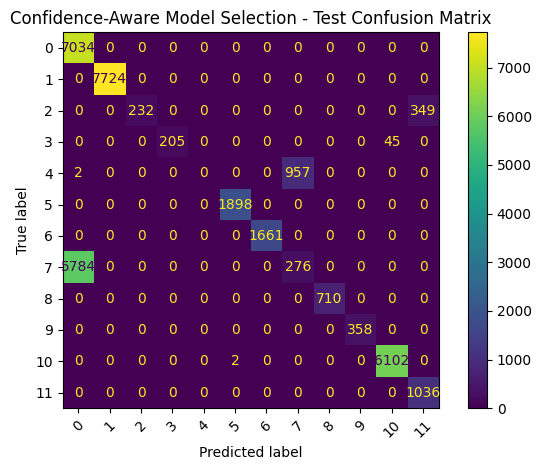

In [340]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(
    y_test_exp2,
    selection_pred,
    labels=np.arange(12)
)

plt.figure(figsize=(11, 9))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder_exp2.classes_
)

disp.plot(
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confidence-Aware Model Selection - Test Confusion Matrix")
plt.tight_layout()

# Save to Drive
FIGURES_DIR = "/content/drive/MyDrive/UAV_NIDD_Project/figures"

plt.savefig(
    f"{FIGURES_DIR}/confusion_matrix_confidence_selection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [342]:
# ============================================================
# DIFFICULT / RARE ATTACK ANALYSIS
# ============================================================

difficult_classes = [
    "De-authentication",
    "DoS",
    "FakeLanding",
    "MITM",
    "replay"
]

rare_attack_rows = per_class_comparison[
    per_class_comparison["Class"].isin(difficult_classes)
].copy()

display(
    rare_attack_rows.style.format({
        col: "{:.4f}"
        for col in rare_attack_rows.columns
        if col != "Class"
    })
)

,Class,XGBoost F1,XGBoost Recall,TCN F1,TCN Recall,AE + Attention F1,AE + Attention Recall,Confidence-aware Selection F1,Confidence-aware Selection Recall


In [344]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

cm = confusion_matrix(
    y_test_exp2,
    selection_pred,
    labels=np.arange(12)
)

class_names = [
    str(x) for x in label_encoder_exp2.classes_
]

cm_df = pd.DataFrame(
    cm,
    index=[f"True: {x}" for x in class_names],
    columns=[f"Pred: {x}" for x in class_names]
)

display(cm_df)

,Pred: 0,Pred: 1,Pred: 2,Pred: 3,Pred: 4,Pred: 5,Pred: 6,Pred: 7,Pred: 8,Pred: 9,Pred: 10,Pred: 11
True: 0,7034,0,0,0,0,0,0,0,0,0,0,0
True: 1,0,7724,0,0,0,0,0,0,0,0,0,0
True: 2,0,0,232,0,0,0,0,0,0,0,0,349
True: 3,0,0,0,205,0,0,0,0,0,0,45,0
True: 4,2,0,0,0,0,0,0,957,0,0,0,0
True: 5,0,0,0,0,0,1898,0,0,0,0,0,0
True: 6,0,0,0,0,0,0,1661,0,0,0,0,0
True: 7,5784,0,0,0,0,0,0,276,0,0,0,0
True: 8,0,0,0,0,0,0,0,0,710,0,0,0
True: 9,0,0,0,0,0,0,0,0,0,358,0,0


In [346]:
# ============================================================
# LEARNED MODEL ROUTER
# Training uses VALIDATION data only.
# Test set remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ------------------------------------------------------------
# 1. Validation probability matrices
# ------------------------------------------------------------

val_probs = {
    "XGBoost": y_val_xgb_prob_exp2,
    "TCN": y_val_tcn_prob_exp2,
    "AE": y_val_ae_prob_exp2
}

# ------------------------------------------------------------
# 2. Construct router features
# ------------------------------------------------------------

def build_router_features(prob_dict):

    xgb = prob_dict["XGBoost"]
    tcn = prob_dict["TCN"]
    ae  = prob_dict["AE"]

    # Full probability distributions
    features = np.hstack([
        xgb,
        tcn,
        ae
    ])

    # Maximum confidence of each model
    confidences = np.column_stack([
        np.max(xgb, axis=1),
        np.max(tcn, axis=1),
        np.max(ae, axis=1)
    ])

    # Predicted class of each model
    predictions = np.column_stack([
        np.argmax(xgb, axis=1),
        np.argmax(tcn, axis=1),
        np.argmax(ae, axis=1)
    ])

    # Prediction disagreement indicators
    disagreement = np.column_stack([
        predictions[:, 0] == predictions[:, 1],
        predictions[:, 0] == predictions[:, 2],
        predictions[:, 1] == predictions[:, 2]
    ]).astype(float)

    # Entropy of each probability distribution
    def entropy(p):
        p_safe = np.clip(p, 1e-12, 1.0)
        return -np.sum(
            p_safe * np.log(p_safe),
            axis=1
        )

    entropies = np.column_stack([
        entropy(xgb),
        entropy(tcn),
        entropy(ae)
    ])

    # Add confidence + disagreement + entropy
    router_features = np.hstack([
        features,
        confidences,
        disagreement,
        entropies
    ])

    return router_features


X_router_val = build_router_features(val_probs)

print("Router validation shape:", X_router_val.shape)
print("Validation samples:", len(y_val_exp2))

Router validation shape: (17174, 45)
Validation samples: 17174


In [348]:
# ============================================================
# TRAIN ROUTER ON VALIDATION OUTPUTS
# ============================================================

router = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            multi_class="multinomial",
            C=1.0,
            random_state=42
        )
    )
])

router.fit(
    X_router_val,
    y_val_exp2
)

print("Router trained successfully.")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Router trained successfully.


In [349]:
# ============================================================
# CREATE VALIDATION MODEL-SELECTION TARGET
# ============================================================

val_xgb_pred = np.argmax(y_val_xgb_prob_exp2, axis=1)
val_tcn_pred = np.argmax(y_val_tcn_prob_exp2, axis=1)
val_ae_pred  = np.argmax(y_val_ae_prob_exp2, axis=1)

correctness = np.column_stack([
    val_xgb_pred == y_val_exp2,
    val_tcn_pred == y_val_exp2,
    val_ae_pred == y_val_exp2
])

# Choose among models that are correct.
# If several models are correct, choose the one
# with the highest confidence.

val_confidences = np.column_stack([
    np.max(y_val_xgb_prob_exp2, axis=1),
    np.max(y_val_tcn_prob_exp2, axis=1),
    np.max(y_val_ae_prob_exp2, axis=1)
])

routing_target = np.empty(len(y_val_exp2), dtype=int)

for i in range(len(y_val_exp2)):

    correct_models = np.where(correctness[i])[0]

    if len(correct_models) > 0:
        # Among correct models, choose highest confidence
        routing_target[i] = correct_models[
            np.argmax(val_confidences[i, correct_models])
        ]
    else:
        # If none are correct, choose highest-confidence model
        routing_target[i] = np.argmax(val_confidences[i])

print("Routing target distribution:")

for i, name in enumerate(["XGBoost", "TCN", "AE + Attention"]):
    count = np.sum(routing_target == i)
    print(
        f"{name}: {count} "
        f"({count / len(routing_target) * 100:.2f}%)"
    )

Routing target distribution:
XGBoost: 4827 (28.11%)
TCN: 12008 (69.92%)
AE + Attention: 339 (1.97%)


In [351]:
# ============================================================
# TRAIN MODEL-SELECTION ROUTER
# ============================================================

model_router = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            multi_class="multinomial",
            C=1.0,
            random_state=42
        )
    )
])

model_router.fit(
    X_router_val,
    routing_target
)

print("Model-selection router trained.")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Model-selection router trained.


In [353]:
# ============================================================
# APPLY FROZEN ROUTER TO TEST
# ============================================================

test_probs = {
    "XGBoost": y_test_xgb_prob_exp2,
    "TCN": y_test_tcn_prob_exp2,
    "AE": y_test_ae_prob_exp2
}

X_router_test = build_router_features(test_probs)

print("Test router shape:", X_router_test.shape)

# Router chooses which branch to trust
test_routed_model = model_router.predict(
    X_router_test
)

# ------------------------------------------------------------
# Select prediction from chosen branch
# ------------------------------------------------------------

routed_pred = np.empty(
    len(y_test_exp2),
    dtype=int
)

for model_idx in range(3):

    mask = test_routed_model == model_idx

    if model_idx == 0:
        routed_pred[mask] = np.argmax(
            y_test_xgb_prob_exp2[mask],
            axis=1
        )

    elif model_idx == 1:
        routed_pred[mask] = np.argmax(
            y_test_tcn_prob_exp2[mask],
            axis=1
        )

    elif model_idx == 2:
        routed_pred[mask] = np.argmax(
            y_test_ae_prob_exp2[mask],
            axis=1
        )

print("Routing completed.")

Test router shape: (34375, 45)
Routing completed.


In [354]:
# ============================================================
# EVALUATE LEARNED ROUTER
# ============================================================

print("===== LEARNED ROUTER TEST RESULTS =====\n")

print(
    "Accuracy:",
    accuracy_score(y_test_exp2, routed_pred)
)

print(
    "Macro Precision:",
    precision_score(
        y_test_exp2,
        routed_pred,
        average="macro",
        zero_division=0
    )
)

print(
    "Macro Recall:",
    recall_score(
        y_test_exp2,
        routed_pred,
        average="macro",
        zero_division=0
    )
)

print(
    "Macro F1:",
    f1_score(
        y_test_exp2,
        routed_pred,
        average="macro",
        zero_division=0
    )
)

print(
    "Weighted F1:",
    f1_score(
        y_test_exp2,
        routed_pred,
        average="weighted",
        zero_division=0
    )
)

===== LEARNED ROUTER TEST RESULTS =====

Accuracy: 0.9588654545454546
Macro Precision: 0.8766601339717536
Macro Recall: 0.8402475495979612
Macro F1: 0.8463053259748557
Weighted F1: 0.9444397278128368


In [356]:
print(
    classification_report(
        y_test_exp2,
        routed_pred,
        target_names=[
            str(x) for x in label_encoder_exp2.classes_
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0     0.9973    1.0000    0.9987      7034
           1     1.0000    1.0000    1.0000      7724
           2     0.9231    0.4131    0.5707       581
           3     1.0000    0.6920    0.8180       250
           4     0.0000    0.0000    0.0000       959
           5     1.0000    1.0000    1.0000      1898
           6     1.0000    1.0000    1.0000      1661
           7     0.8633    0.9972    0.9254      6060
           8     1.0000    1.0000    1.0000       710
           9     1.0000    1.0000    1.0000       358
          10     0.9875    1.0000    0.9937      6104
          11     0.7487    0.9807    0.8491      1036

    accuracy                         0.9589     34375
   macro avg     0.8767    0.8402    0.8463     34375
weighted avg     0.9364    0.9589    0.9444     34375



In [359]:
# ============================================================
# LEARNED ROUTER - TEST ROUTING DISTRIBUTION
# ============================================================

router_model_names = [
    "XGBoost",
    "TCN",
    "AE + Attention"
]

router_counts = np.bincount(
    test_routed_model,
    minlength=3
)

router_distribution = pd.DataFrame({
    "Selected Model": router_model_names,
    "Sequences Selected": router_counts,
    "Percentage": (
        router_counts / len(test_routed_model) * 100
    )
})

print("===== LEARNED ROUTER TEST DISTRIBUTION =====\n")

display(
    router_distribution.style.format({
        "Percentage": "{:.2f}%"
    })
)

===== LEARNED ROUTER TEST DISTRIBUTION =====



,Selected Model,Sequences Selected,Percentage
0,XGBoost,8104,23.58%
1,TCN,25774,74.98%
2,AE + Attention,497,1.45%


In [361]:
# ============================================================
# LEARNED ROUTER PER-CLASS RESULTS
# ============================================================

router_report = classification_report(
    y_test_exp2,
    routed_pred,
    target_names=[
        str(x) for x in label_encoder_exp2.classes_
    ],
    output_dict=True,
    zero_division=0
)

router_rows = []

for class_name in label_encoder_exp2.classes_:

    class_name = str(class_name)

    router_rows.append({
        "Class": class_name,
        "F1": router_report[class_name]["f1-score"],
        "Recall": router_report[class_name]["recall"],
        "Precision": router_report[class_name]["precision"],
        "Support": router_report[class_name]["support"]
    })

router_per_class = pd.DataFrame(router_rows)

display(
    router_per_class.style.format({
        "F1": "{:.4f}",
        "Recall": "{:.4f}",
        "Precision": "{:.4f}",
        "Support": "{:.0f}"
    })
)

,Class,F1,Recall,Precision,Support
0,0,0.9987,1.0000,0.9973,7034
1,1,1.0000,1.0000,1.0000,7724
2,2,0.5707,0.4131,0.9231,581
3,3,0.8180,0.6920,1.0000,250
4,4,0.0000,0.0000,0.0000,959
5,5,1.0000,1.0000,1.0000,1898
6,6,1.0000,1.0000,1.0000,1661
7,7,0.9254,0.9972,0.8633,6060
8,8,1.0000,1.0000,1.0000,710
9,9,1.0000,1.0000,1.0000,358


In [363]:
# ============================================================
# ROUTER GENERALIZATION SANITY CHECK
#
# Base models are already trained.
# We only split the EXISTING validation predictions.
# Test data is NOT used.
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ------------------------------------------------------------
# Split validation outputs into router-train / router-holdout
# ------------------------------------------------------------

(
    X_router_train,
    X_router_holdout,
    y_router_train,
    y_router_holdout
) = train_test_split(
    X_router_val,
    routing_target,
    test_size=0.30,
    random_state=42,
    stratify=routing_target
)

print("Router training samples:", len(y_router_train))
print("Router holdout samples:", len(y_router_holdout))


# ------------------------------------------------------------
# Train a fresh router
# ------------------------------------------------------------

sanity_router = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            C=1.0,
            random_state=42
        )
    )
])

sanity_router.fit(
    X_router_train,
    y_router_train
)


# ------------------------------------------------------------
# Predict which model should be selected
# ------------------------------------------------------------

holdout_selected_model = sanity_router.predict(
    X_router_holdout
)

print("\nRouter model-selection accuracy:")
print(
    accuracy_score(
        y_router_holdout,
        holdout_selected_model
    )
)

Router training samples: 12021
Router holdout samples: 5153

Router model-selection accuracy:
0.9796235202794489


In [365]:
# ============================================================
# APPLY HOLDOUT ROUTING TO THE ACTUAL VALIDATION PREDICTIONS
# ============================================================

# Recover the corresponding validation sample indices
_, holdout_indices = train_test_split(
    np.arange(len(y_val_exp2)),
    test_size=0.30,
    random_state=42,
    stratify=routing_target
)

holdout_indices = np.array(holdout_indices)

# Predictions from each branch
val_xgb_pred = np.argmax(
    y_val_xgb_prob_exp2,
    axis=1
)

val_tcn_pred = np.argmax(
    y_val_tcn_prob_exp2,
    axis=1
)

val_ae_pred = np.argmax(
    y_val_ae_prob_exp2,
    axis=1
)

# Select the prediction from the router-selected branch
holdout_routed_pred = np.empty(
    len(holdout_indices),
    dtype=int
)

for model_idx in range(3):

    mask = holdout_selected_model == model_idx

    sample_indices = holdout_indices[mask]

    if model_idx == 0:
        holdout_routed_pred[mask] = val_xgb_pred[sample_indices]

    elif model_idx == 1:
        holdout_routed_pred[mask] = val_tcn_pred[sample_indices]

    elif model_idx == 2:
        holdout_routed_pred[mask] = val_ae_pred[sample_indices]


# Actual validation labels for those samples
y_holdout_true = y_val_exp2[holdout_indices]


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

print("\n===== ROUTER HOLDOUT PERFORMANCE =====")

print(
    "Accuracy:",
    accuracy_score(
        y_holdout_true,
        holdout_routed_pred
    )
)

print(
    "Macro Precision:",
    precision_score(
        y_holdout_true,
        holdout_routed_pred,
        average="macro",
        zero_division=0
    )
)

print(
    "Macro Recall:",
    recall_score(
        y_holdout_true,
        holdout_routed_pred,
        average="macro",
        zero_division=0
    )
)

print(
    "Macro F1:",
    f1_score(
        y_holdout_true,
        holdout_routed_pred,
        average="macro",
        zero_division=0
    )
)

print(
    "Weighted F1:",
    f1_score(
        y_holdout_true,
        holdout_routed_pred,
        average="weighted",
        zero_division=0
    )
)


===== ROUTER HOLDOUT PERFORMANCE =====
Accuracy: 0.9670095090238696
Macro Precision: 0.8885212118321242
Macro Recall: 0.8938974366976261
Macro F1: 0.8894202086177887
Weighted F1: 0.9539785373679777


In [367]:
# ============================================================
# FINAL FROZEN ROUTER
#
# Train ONLY on the 70% router-training portion.
# Do not use router holdout or test labels.
# ============================================================

final_router = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            C=1.0,
            random_state=42
        )
    )
])

final_router.fit(
    X_router_train,
    y_router_train
)

print("Final router trained.")
print("Training samples:", len(y_router_train))

Final router trained.
Training samples: 12021


In [369]:
# ============================================================
# FINAL ROUTER → TEST
# ============================================================

final_test_selected_model = final_router.predict(
    X_router_test
)

final_routed_pred = np.empty(
    len(y_test_exp2),
    dtype=int
)

# XGBoost
mask = final_test_selected_model == 0
final_routed_pred[mask] = np.argmax(
    y_test_xgb_prob_exp2[mask],
    axis=1
)

# TCN
mask = final_test_selected_model == 1
final_routed_pred[mask] = np.argmax(
    y_test_tcn_prob_exp2[mask],
    axis=1
)

# AE + Attention
mask = final_test_selected_model == 2
final_routed_pred[mask] = np.argmax(
    y_test_ae_prob_exp2[mask],
    axis=1
)

print("Final routing completed.")

Final routing completed.


In [371]:
# ============================================================
# FINAL TEST RESULT
# ============================================================

final_accuracy = accuracy_score(
    y_test_exp2,
    final_routed_pred
)

final_precision = precision_score(
    y_test_exp2,
    final_routed_pred,
    average="macro",
    zero_division=0
)

final_recall = recall_score(
    y_test_exp2,
    final_routed_pred,
    average="macro",
    zero_division=0
)

final_macro_f1 = f1_score(
    y_test_exp2,
    final_routed_pred,
    average="macro",
    zero_division=0
)

final_weighted_f1 = f1_score(
    y_test_exp2,
    final_routed_pred,
    average="weighted",
    zero_division=0
)

print("===== FINAL ADAPTIVE ROUTER TEST RESULT =====\n")

print(f"Accuracy:        {final_accuracy:.4f}")
print(f"Macro Precision: {final_precision:.4f}")
print(f"Macro Recall:    {final_recall:.4f}")
print(f"Macro F1:        {final_macro_f1:.4f}")
print(f"Weighted F1:     {final_weighted_f1:.4f}")

===== FINAL ADAPTIVE ROUTER TEST RESULT =====

Accuracy:        0.9588
Macro Precision: 0.8759
Macro Recall:    0.8401
Macro F1:        0.8460
Weighted F1:     0.9444


In [373]:
print(
    classification_report(
        y_test_exp2,
        final_routed_pred,
        target_names=[
            str(x) for x in label_encoder_exp2.classes_
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0     0.9974    1.0000    0.9987      7034
           1     1.0000    1.0000    1.0000      7724
           2     0.9154    0.4096    0.5660       581
           3     1.0000    0.6960    0.8208       250
           4     0.0000    0.0000    0.0000       959
           5     1.0000    1.0000    1.0000      1898
           6     1.0000    1.0000    1.0000      1661
           7     0.8633    0.9974    0.9255      6060
           8     1.0000    1.0000    1.0000       710
           9     1.0000    1.0000    1.0000       358
          10     0.9877    1.0000    0.9938      6104
          11     0.7472    0.9788    0.8475      1036

    accuracy                         0.9588     34375
   macro avg     0.8759    0.8401    0.8460     34375
weighted avg     0.9362    0.9588    0.9444     34375



In [375]:
import os
import json
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

FINAL_DIR = "/content/drive/MyDrive/UAV_NIDD_Project/results/final_adaptive_router"
os.makedirs(FINAL_DIR, exist_ok=True)

# Final predictions already produced
final_pred = final_routed_pred

# -----------------------------
# 1. Overall metrics
# -----------------------------
final_metrics = {
    "accuracy": float(accuracy_score(y_test_exp2, final_pred)),
    "macro_precision": float(
        precision_score(y_test_exp2, final_pred, average="macro", zero_division=0)
    ),
    "macro_recall": float(
        recall_score(y_test_exp2, final_pred, average="macro", zero_division=0)
    ),
    "macro_f1": float(
        f1_score(y_test_exp2, final_pred, average="macro", zero_division=0)
    ),
    "weighted_f1": float(
        f1_score(y_test_exp2, final_pred, average="weighted", zero_division=0)
    ),
    "test_samples": int(len(y_test_exp2))
}

with open(os.path.join(FINAL_DIR, "final_metrics.json"), "w") as f:
    json.dump(final_metrics, f, indent=4)

print("Saved final_metrics.json")
print(final_metrics)

Saved final_metrics.json
{'accuracy': 0.9588072727272727, 'macro_precision': 0.8759230172246529, 'macro_recall': 0.8401468974129119, 'macro_f1': 0.8460215006740128, 'weighted_f1': 0.9443726127058772, 'test_samples': 34375}


In [377]:
# -----------------------------
# 2. Classification report
# -----------------------------
class_names = [str(x) for x in label_encoder_exp2.classes_]

report_dict = classification_report(
    y_test_exp2,
    final_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T
report_df.to_csv(
    os.path.join(FINAL_DIR, "final_classification_report.csv")
)

print(report_df)
print("\nSaved final_classification_report.csv")

              precision    recall  f1-score       support
0              0.997448  1.000000  0.998722   7034.000000
1              1.000000  1.000000  1.000000   7724.000000
2              0.915385  0.409639  0.565993    581.000000
3              1.000000  0.696000  0.820755    250.000000
4              0.000000  0.000000  0.000000    959.000000
5              1.000000  1.000000  1.000000   1898.000000
6              1.000000  1.000000  1.000000   1661.000000
7              0.863305  0.997360  0.925503   6060.000000
8              1.000000  1.000000  1.000000    710.000000
9              1.000000  1.000000  1.000000    358.000000
10             0.987702  1.000000  0.993813   6104.000000
11             0.747237  0.978764  0.847472   1036.000000
accuracy       0.958807  0.958807  0.958807      0.958807
macro avg      0.875923  0.840147  0.846022  34375.000000
weighted avg   0.936250  0.958807  0.944373  34375.000000

Saved final_classification_report.csv


In [379]:
# -----------------------------
# 3. Confusion matrix
# -----------------------------
cm = confusion_matrix(y_test_exp2, final_pred)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

cm_df.to_csv(
    os.path.join(FINAL_DIR, "final_confusion_matrix.csv")
)

print(cm_df)
print("\nSaved final_confusion_matrix.csv")

       0     1    2    3  4     5     6     7    8    9    10    11
0   7034     0    0    0  0     0     0     0    0    0     0     0
1      0  7724    0    0  0     0     0     0    0    0     0     0
2      0     0  238    0  0     0     0     0    0    0     0   343
3      0     0    0  174  0     0     0     0    0    0    76     0
4      2     0    0    0  0     0     0   957    0    0     0     0
5      0     0    0    0  0  1898     0     0    0    0     0     0
6      0     0    0    0  0     0  1661     0    0    0     0     0
7     16     0    0    0  0     0     0  6044    0    0     0     0
8      0     0    0    0  0     0     0     0  710    0     0     0
9      0     0    0    0  0     0     0     0    0  358     0     0
10     0     0    0    0  0     0     0     0    0    0  6104     0
11     0     0   22    0  0     0     0     0    0    0     0  1014

Saved final_confusion_matrix.csv


In [381]:
# -----------------------------
# 4. Final predictions
# -----------------------------
import numpy as np

np.save(
    os.path.join(FINAL_DIR, "final_adaptive_router_predictions.npy"),
    final_pred
)

np.save(
    os.path.join(FINAL_DIR, "y_test_true.npy"),
    y_test_exp2
)

print("Saved final prediction files.")
print("Final results directory:")
print(FINAL_DIR)

Saved final prediction files.
Final results directory:
/content/drive/MyDrive/UAV_NIDD_Project/results/final_adaptive_router


In [383]:
# Final router selection distribution

import numpy as np
from collections import Counter

router_names = {
    0: "XGBoost",
    1: "TCN",
    2: "AE + Attention"
}

routing_counts = Counter(final_router.predict(X_router_test))

routing_df = pd.DataFrame({
    "Model": [router_names[i] for i in sorted(routing_counts.keys())],
    "Samples": [routing_counts[i] for i in sorted(routing_counts.keys())]
})

routing_df["Percentage"] = (
    routing_df["Samples"] / len(X_router_test) * 100
)

print(routing_df)

routing_df.to_csv(
    os.path.join(FINAL_DIR, "final_routing_distribution.csv"),
    index=False
)

            Model  Samples  Percentage
0         XGBoost     8091   23.537455
1             TCN    25773   74.976000
2  AE + Attention      511    1.486545


In [388]:
import tensorflow as tf

print("Keras models currently in memory:\n")

for name, obj in globals().items():
    if isinstance(obj, tf.keras.Model):
        print(name, "→", obj.name, "| params:", obj.count_params())

Keras models currently in memory:

tcn_model → sequential_7 | params: 33932
ae_attention_model → functional_12 | params: 53609
tcn_exp2_model → functional_10 | params: 255500


In [390]:
import os

# ==========================================
# FINAL EXPERIMENT 2 MODEL SIZES
# ==========================================

# XGBoost
xgb_path = os.path.join(FINAL_DIR, "xgb_exp2_model.json")
xgb_exp2.save_model(xgb_path)
xgb_size_kb = os.path.getsize(xgb_path) / 1024

# TCN — Experiment 2
tcn_weights_path = os.path.join(FINAL_DIR, "tcn_exp2.weights.h5")
tcn_exp2_model.save_weights(tcn_weights_path)
tcn_size_kb = os.path.getsize(tcn_weights_path) / 1024

# AE + Attention — Experiment 2
ae_weights_path = os.path.join(FINAL_DIR, "ae_attention_exp2.weights.h5")
ae_attention_model.save_weights(ae_weights_path)
ae_size_kb = os.path.getsize(ae_weights_path) / 1024

print("===== FINAL MODEL SIZES =====")
print(f"XGBoost:        {xgb_size_kb:.2f} KB")
print(f"TCN:            {tcn_size_kb:.2f} KB")
print(f"AE + Attention: {ae_size_kb:.2f} KB")

print("\n===== PARAMETER COUNTS =====")
print(f"TCN:            {tcn_exp2_model.count_params():,}")
print(f"AE + Attention: {ae_attention_model.count_params():,}")

===== FINAL MODEL SIZES =====
XGBoost:        1953.70 KB
TCN:            3121.69 KB
AE + Attention: 700.98 KB

===== PARAMETER COUNTS =====
TCN:            255,500
AE + Attention: 53,609


In [392]:
print("X_test_scaled_exp2:", X_test_scaled_exp2.shape)
print("y_test_exp2:", y_test_exp2.shape)

print("X_router_test:", X_router_test.shape)
print("final_pred:", final_routed_pred.shape)

X_test_scaled_exp2: (34375, 20, 29)
y_test_exp2: (34375,)
X_router_test: (34375, 45)
final_pred: (34375,)


In [394]:
print("Models:")
print("XGBoost:", type(xgb_exp2).__name__)
print("TCN:", tcn_exp2_model.name)
print("AE + Attention:", ae_attention_model.name)
print("Router:", type(final_router).__name__)

Models:
XGBoost: XGBClassifier
TCN: functional_10
AE + Attention: functional_12
Router: Pipeline


In [407]:
# ============================================================
# UAV-NIDD LIVE INFERENCE DEMO
# Final Experiment 2
# ============================================================

import numpy as np
import pandas as pd

# Class mapping
class_names = [str(x) for x in label_encoder_exp2.classes_]

# ------------------------------------------------------------
# 1. Convert one 20x29 sequence into XGBoost features
# ------------------------------------------------------------

def make_xgb_features_single(sequence):
    """
    Convert one scaled 20x29 temporal sequence into
    the same 145 statistical features used by XGBoost.

    29 features × 5 statistics:
    mean, std, min, max, median
    """

    mean_features = np.mean(sequence, axis=0)
    std_features = np.std(sequence, axis=0)
    min_features = np.min(sequence, axis=0)
    max_features = np.max(sequence, axis=0)
    median_features = np.median(sequence, axis=0)

    return np.concatenate([
        mean_features,
        std_features,
        min_features,
        max_features,
        median_features
    ]).reshape(1, -1)


# ------------------------------------------------------------
# 2. Build router features for ONE sample
# ------------------------------------------------------------

def build_single_router_features(
    xgb_prob,
    tcn_prob,
    ae_prob
):
    """
    Same 45-feature router representation used during training:

    36 probability values
    + 3 confidence values
    + 3 pairwise agreement values
    + 3 entropy values
    """

    probs = [xgb_prob, tcn_prob, ae_prob]

    # 36 probability features
    probability_features = np.concatenate(probs)

    # Confidence = maximum probability
    confidence_features = np.array([
        np.max(xgb_prob),
        np.max(tcn_prob),
        np.max(ae_prob)
    ])

    # Predicted classes
    predictions = [
        np.argmax(xgb_prob),
        np.argmax(tcn_prob),
        np.argmax(ae_prob)
    ]

    # Pairwise agreement
    agreement_features = np.array([
        float(predictions[0] == predictions[1]),
        float(predictions[0] == predictions[2]),
        float(predictions[1] == predictions[2])
    ])

    # Entropy
    entropy_features = np.array([
        -np.sum(xgb_prob * np.log(xgb_prob + 1e-12)),
        -np.sum(tcn_prob * np.log(tcn_prob + 1e-12)),
        -np.sum(ae_prob * np.log(ae_prob + 1e-12))
    ])

    return np.concatenate([
        probability_features,
        confidence_features,
        agreement_features,
        entropy_features
    ]).reshape(1, -1)


# ------------------------------------------------------------
# 3. LIVE INFERENCE FUNCTION
# ------------------------------------------------------------

def live_inference(test_index=0):

    # Get one actual test sequence
    sequence = X_test_scaled_exp2[test_index:test_index+1]

    # True label
    true_class = int(y_test_exp2[test_index])

    # --------------------------------------------------------
    # XGBoost
    # --------------------------------------------------------

    single_sequence = sequence[0]

    xgb_input = make_xgb_features_single(single_sequence)

    xgb_prob = xgb_exp2.predict_proba(xgb_input)[0]

    xgb_pred = int(np.argmax(xgb_prob))
    xgb_conf = float(np.max(xgb_prob))


    # --------------------------------------------------------
    # TCN
    # --------------------------------------------------------

    tcn_prob = tcn_exp2_model.predict(
        sequence,
        verbose=0
    )[0]

    tcn_pred = int(np.argmax(tcn_prob))
    tcn_conf = float(np.max(tcn_prob))


    # --------------------------------------------------------
    # AE + Attention
    # --------------------------------------------------------

    ae_output = ae_attention_model.predict(
        sequence,
        verbose=0
    )

    # AE model has two outputs:
    # classification probabilities + reconstruction
    if isinstance(ae_output, (list, tuple)):
        ae_prob = ae_output[0][0]
    else:
        ae_prob = ae_output[0]

    ae_pred = int(np.argmax(ae_prob))
    ae_conf = float(np.max(ae_prob))


    # --------------------------------------------------------
    # Router
    # --------------------------------------------------------

    router_input = build_single_router_features(
        xgb_prob,
        tcn_prob,
        ae_prob
    )

    selected_model = int(
        final_router.predict(router_input)[0]
    )

    model_names = {
        0: "XGBoost",
        1: "TCN",
        2: "AE + Attention"
    }

    final_prediction = [
        xgb_pred,
        tcn_pred,
        ae_pred
    ][selected_model]

    # --------------------------------------------------------
    # DISPLAY
    # --------------------------------------------------------

    print("=" * 64)
    print("          UAV-NIDD LIVE INFERENCE DEMONSTRATION")
    print("=" * 64)

    print(f"\nTest sequence: #{test_index}")
    print(f"Sequence shape: {sequence.shape[1:]}")

    print("\n" + "-" * 64)
    print("TRUE CLASS")
    print("-" * 64)

    print(f"  {class_names[true_class]}")

    print("\n" + "-" * 64)
    print("MODEL PREDICTIONS")
    print("-" * 64)

    print("\nXGBoost")
    print(f"  Prediction : {class_names[xgb_pred]}")
    print(f"  Confidence : {xgb_conf:.2%}")

    print("\nTCN")
    print(f"  Prediction : {class_names[tcn_pred]}")
    print(f"  Confidence : {tcn_conf:.2%}")

    print("\nAE + Attention")
    print(f"  Prediction : {class_names[ae_pred]}")
    print(f"  Confidence : {ae_conf:.2%}")

    print("\n" + "-" * 64)
    print("ADAPTIVE ROUTER")
    print("-" * 64)

    print(f"\n  Selected model  : {model_names[selected_model]}")
    print(f"  Final prediction: {class_names[final_prediction]}")

    print("\n" + "-" * 64)

    if final_prediction == true_class:
        print("RESULT: ✓ CORRECT")
    else:
        print("RESULT: ✗ INCORRECT")

    print("=" * 64)

    return {
        "index": test_index,
        "true_class": class_names[true_class],
        "xgb_prediction": class_names[xgb_pred],
        "xgb_confidence": xgb_conf,
        "tcn_prediction": class_names[tcn_pred],
        "tcn_confidence": tcn_conf,
        "ae_prediction": class_names[ae_pred],
        "ae_confidence": ae_conf,
        "selected_model": model_names[selected_model],
        "final_prediction": class_names[final_prediction],
        "correct": final_prediction == true_class
    }

In [409]:
demo_result = live_inference(0)

          UAV-NIDD LIVE INFERENCE DEMONSTRATION

Test sequence: #0
Sequence shape: (20, 29)

----------------------------------------------------------------
TRUE CLASS
----------------------------------------------------------------
  8

----------------------------------------------------------------
MODEL PREDICTIONS
----------------------------------------------------------------

XGBoost
  Prediction : 8
  Confidence : 99.53%

TCN
  Prediction : 8
  Confidence : 73.53%

AE + Attention
  Prediction : 8
  Confidence : 99.66%

----------------------------------------------------------------
ADAPTIVE ROUTER
----------------------------------------------------------------

  Selected model  : XGBoost
  Final prediction: 8

----------------------------------------------------------------
RESULT: ✓ CORRECT


In [411]:
# ================================================================
# FIND GOOD LIVE-DEMO EXAMPLES FOR EACH ROUTER BRANCH
# ================================================================

# Predictions from the three already-generated test probability arrays
xgb_test_pred = np.argmax(y_test_xgb_prob_exp2, axis=1)
tcn_test_pred = np.argmax(y_test_tcn_prob_exp2, axis=1)
ae_test_pred  = np.argmax(y_test_ae_prob_exp2, axis=1)

# Which branch the final router selected
router_test_selection = final_router.predict(X_router_test)

models = {
    0: ("XGBoost", xgb_test_pred),
    1: ("TCN", tcn_test_pred),
    2: ("AE + Attention", ae_test_pred)
}

print("=" * 70)
print("          LIVE DEMO CANDIDATES")
print("=" * 70)

for branch_id, (model_name, model_pred) in models.items():

    # Router selected this model AND this model was correct
    candidates = np.where(
        (router_test_selection == branch_id) &
        (model_pred == y_test_exp2)
    )[0]

    print(f"\n{model_name}")
    print("-" * 70)
    print("Correctly routed samples:", len(candidates))

    if len(candidates) > 0:
        # Show first few candidates
        for idx in candidates[:10]:
            true_class = y_test_exp2[idx]

            print(
                f"Index #{idx:5d} | "
                f"True={true_class} | "
                f"XGB={xgb_test_pred[idx]} | "
                f"TCN={tcn_test_pred[idx]} | "
                f"AE={ae_test_pred[idx]}"
            )

          LIVE DEMO CANDIDATES

XGBoost
----------------------------------------------------------------------
Correctly routed samples: 6855
Index #    0 | True=8 | XGB=8 | TCN=8 | AE=8
Index #   37 | True=8 | XGB=8 | TCN=8 | AE=8
Index #  204 | True=8 | XGB=8 | TCN=8 | AE=8
Index #  241 | True=8 | XGB=8 | TCN=8 | AE=8
Index # 2859 | True=10 | XGB=10 | TCN=10 | AE=10
Index # 2860 | True=10 | XGB=10 | TCN=10 | AE=10
Index # 2861 | True=10 | XGB=10 | TCN=10 | AE=10
Index # 3569 | True=10 | XGB=10 | TCN=10 | AE=10
Index # 3573 | True=10 | XGB=10 | TCN=10 | AE=10
Index # 3574 | True=10 | XGB=10 | TCN=10 | AE=10

TCN
----------------------------------------------------------------------
Correctly routed samples: 25750
Index #    1 | True=8 | XGB=8 | TCN=8 | AE=8
Index #    2 | True=8 | XGB=8 | TCN=8 | AE=8
Index #    3 | True=8 | XGB=8 | TCN=8 | AE=8
Index #    5 | True=8 | XGB=8 | TCN=8 | AE=8
Index #    6 | True=8 | XGB=8 | TCN=8 | AE=8
Index #    7 | True=8 | XGB=8 | TCN=8 | AE=8
Index 

In [413]:
# ================================================================
# FIND STRONG DISAGREEMENT CASES FOR THE LIVE DEMO
# ================================================================

print("=" * 75)
print("       STRONG ADAPTIVE ROUTER DEMO CANDIDATES")
print("=" * 75)

preds = {
    0: xgb_test_pred,
    1: tcn_test_pred,
    2: ae_test_pred
}

names = {
    0: "XGBoost",
    1: "TCN",
    2: "AE + Attention"
}

# For each router-selected model:
# Find cases where:
#   1. router selected that model
#   2. selected model is correct
#   3. at least one other model is wrong
#   4. preferably the other models disagree with each other too

for selected_id in [0, 1, 2]:

    selected_pred = preds[selected_id]

    # Router selected this branch
    mask = (router_test_selection == selected_id)

    # Selected model is correct
    mask &= (selected_pred == y_test_exp2)

    # At least one other model is wrong
    other_wrong = np.zeros(len(y_test_exp2), dtype=bool)

    for other_id in [0, 1, 2]:
        if other_id != selected_id:
            other_wrong |= (preds[other_id] != y_test_exp2)

    mask &= other_wrong

    candidates = np.where(mask)[0]

    print(f"\n{names[selected_id]}")
    print("-" * 75)
    print("Strong disagreement cases:", len(candidates))

    # Prefer cases where ALL THREE models disagree
    all_disagree = []

    for idx in candidates:
        if len({
            xgb_test_pred[idx],
            tcn_test_pred[idx],
            ae_test_pred[idx]
        }) == 3:
            all_disagree.append(idx)

    if len(all_disagree) > 0:
        print("Cases where all 3 models disagree:", len(all_disagree))
        display_indices = all_disagree[:10]
    else:
        display_indices = candidates[:10]

    for idx in display_indices:

        print(
            f"Index #{idx:5d} | "
            f"True={y_test_exp2[idx]} | "
            f"XGB={xgb_test_pred[idx]} | "
            f"TCN={tcn_test_pred[idx]} | "
            f"AE={ae_test_pred[idx]} | "
            f"Router={names[router_test_selection[idx]]}"
        )

       STRONG ADAPTIVE ROUTER DEMO CANDIDATES

XGBoost
---------------------------------------------------------------------------
Strong disagreement cases: 6477
Index # 5373 | True=10 | XGB=10 | TCN=3 | AE=10 | Router=XGBoost
Index # 5374 | True=10 | XGB=10 | TCN=3 | AE=10 | Router=XGBoost
Index # 6139 | True=10 | XGB=10 | TCN=3 | AE=10 | Router=XGBoost
Index # 6243 | True=10 | XGB=10 | TCN=3 | AE=10 | Router=XGBoost
Index # 6244 | True=10 | XGB=10 | TCN=3 | AE=10 | Router=XGBoost
Index # 6270 | True=10 | XGB=10 | TCN=3 | AE=10 | Router=XGBoost
Index # 6327 | True=10 | XGB=10 | TCN=10 | AE=3 | Router=XGBoost
Index # 6356 | True=10 | XGB=10 | TCN=10 | AE=3 | Router=XGBoost
Index # 6414 | True=10 | XGB=10 | TCN=10 | AE=3 | Router=XGBoost
Index # 6415 | True=10 | XGB=10 | TCN=10 | AE=3 | Router=XGBoost

TCN
---------------------------------------------------------------------------
Strong disagreement cases: 237
Cases where all 3 models disagree: 9
Index # 8688 | True=3 | XGB=1 | TCN=3 

In [414]:
# ================================================================
#       UAV-NIDD ADAPTIVE ROUTER — LIVE INFERENCE DEMO
# ================================================================

DEMO_INDICES = [5371, 8688, 5373]

CLASS_NAMES = {
    0: "BruteForce",
    1: "DDoS",
    2: "De-authentication",
    3: "DoS",
    4: "FakeLanding",
    5: "ICMP Flooding",
    6: "Jamming",
    7: "MITM",
    8: "Normal",
    9: "Scanning",
    10: "UDP Flooding",
    11: "replay"
}

MODEL_NAMES = {
    0: "XGBoost",
    1: "TCN",
    2: "AE + Attention"
}


def run_demo(index):

    sequence = X_test_scaled_exp2[index:index+1]
    true_class = int(y_test_exp2[index])

    # ------------------------------------------------------------
    # XGBoost
    # ------------------------------------------------------------
    xgb_features = make_xgb_features_single(
        X_test_scaled_exp2[index]
    )

    xgb_prob = xgb_exp2.predict_proba(xgb_features)[0]
    xgb_pred = int(np.argmax(xgb_prob))
    xgb_conf = float(np.max(xgb_prob))

    # ------------------------------------------------------------
    # TCN
    # ------------------------------------------------------------
    tcn_prob = tcn_exp2_model.predict(
        sequence,
        verbose=0
    )[0]

    tcn_pred = int(np.argmax(tcn_prob))
    tcn_conf = float(np.max(tcn_prob))

    # ------------------------------------------------------------
    # AE + Attention
    # ------------------------------------------------------------
    ae_output = ae_attention_model.predict(
        sequence,
        verbose=0
    )

    if isinstance(ae_output, (list, tuple)):
        ae_prob = ae_output[0][0]
    else:
        ae_prob = ae_output[0]

    ae_pred = int(np.argmax(ae_prob))
    ae_conf = float(np.max(ae_prob))

    # ------------------------------------------------------------
    # Router
    # ------------------------------------------------------------
    router_features = build_single_router_features(
        xgb_prob,
        tcn_prob,
        ae_prob
    )

    selected_model = int(
        final_router.predict(
            router_features.reshape(1, -1)
        )[0]
    )

    model_predictions = {
        0: xgb_pred,
        1: tcn_pred,
        2: ae_pred
    }

    final_prediction = model_predictions[selected_model]

    # ------------------------------------------------------------
    # Display
    # ------------------------------------------------------------
    print("\n" + "=" * 72)
    print("             UAV-NIDD LIVE INFERENCE DEMONSTRATION")
    print("=" * 72)

    print(f"\nTest sequence: #{index}")
    print(f"Sequence shape: {X_test_scaled_exp2[index].shape}")

    print("\n" + "-" * 72)
    print("TRUE CLASS")
    print("-" * 72)
    print(
        f"  {true_class} → {CLASS_NAMES[true_class]}"
    )

    print("\n" + "-" * 72)
    print("MODEL PREDICTIONS")
    print("-" * 72)

    print("\nXGBoost")
    print(
        f"  Prediction : {xgb_pred} → {CLASS_NAMES[xgb_pred]}"
    )
    print(
        f"  Confidence : {xgb_conf:.2%}"
    )

    print("\nTCN")
    print(
        f"  Prediction : {tcn_pred} → {CLASS_NAMES[tcn_pred]}"
    )
    print(
        f"  Confidence : {tcn_conf:.2%}"
    )

    print("\nAE + Attention")
    print(
        f"  Prediction : {ae_pred} → {CLASS_NAMES[ae_pred]}"
    )
    print(
        f"  Confidence : {ae_conf:.2%}"
    )

    print("\n" + "-" * 72)
    print("ADAPTIVE ROUTER")
    print("-" * 72)

    print(
        f"\n  Selected model  : {MODEL_NAMES[selected_model]}"
    )

    print(
        f"  Final prediction: "
        f"{final_prediction} → {CLASS_NAMES[final_prediction]}"
    )

    print("\n" + "-" * 72)

    if final_prediction == true_class:
        print("RESULT: ✓ CORRECT")
    else:
        print("RESULT: ✗ INCORRECT")

    print("=" * 72)


# Run all three demonstrations
for idx in DEMO_INDICES:
    run_demo(idx)


             UAV-NIDD LIVE INFERENCE DEMONSTRATION

Test sequence: #5371
Sequence shape: (20, 29)

------------------------------------------------------------------------
TRUE CLASS
------------------------------------------------------------------------
  10 → UDP Flooding

------------------------------------------------------------------------
MODEL PREDICTIONS
------------------------------------------------------------------------

XGBoost
  Prediction : 2 → De-authentication
  Confidence : 43.33%

TCN
  Prediction : 5 → ICMP Flooding
  Confidence : 70.27%

AE + Attention
  Prediction : 10 → UDP Flooding
  Confidence : 61.06%

------------------------------------------------------------------------
ADAPTIVE ROUTER
------------------------------------------------------------------------

  Selected model  : AE + Attention
  Final prediction: 10 → UDP Flooding

------------------------------------------------------------------------
RESULT: ✓ CORRECT

             UAV-NIDD LIVE IN